In [1]:
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
from utils.feature_selection import FeatureSelection
from utils.regression import Regression

In [2]:
data_df = pd.read_csv("../processed_data/data_combined_training.csv", index_col=0)
data_df = data_df.dropna().reset_index(drop=True)
data_df 

,App A,App B,Num Nodes,App A Isolated MPI Time,App B Isolated MPI Time,App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.5_Mode=d],...,App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.3_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.5_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.5_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.7_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.7_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App A Co-Scheduled MPI Time with App B,App B Co-Scheduled MPI Time with App A
0,amg,beatnik,8,12.778086,99.906362,27.880246,126.700893,14.685140,117.027344,13.073605,...,35.622991,211.793527,39.671094,188.018973,40.329576,199.823661,41.997991,347.267857,19.768080,114.305246
1,amg,fiesta,8,12.778086,65.675446,27.880246,84.057533,14.685140,55.426004,13.073605,...,35.622991,59.038225,39.671094,64.025000,40.329576,64.335547,41.997991,95.488170,13.131256,66.732031
2,amg,kripke,8,12.778086,17.006585,27.880246,20.994085,14.685140,17.226116,13.073605,...,35.622991,20.789788,39.671094,22.184877,40.329576,22.638839,41.997991,21.505022,14.017204,17.599777
3,amg,laghos,8,12.778086,54.944978,27.880246,184.186384,14.685140,114.130692,13.073605,...,35.622991,215.852121,39.671094,243.406808,40.329576,238.407366,41.997991,272.857143,14.706105,85.912444
4,amg,lammps,8,12.778086,17.381222,27.880246,20.600067,14.685140,16.306914,13.073605,...,35.622991,28.386836,39.671094,26.668432,40.329576,30.012612,41.997991,29.754408,13.311166,18.569660
5,amg,minife,8,12.778086,13.601356,27.880246,20.535279,14.685140,14.775982,13.073605,...,35.622991,35.439453,39.671094,36.365513,40.329576,41.655469,41.997991,43.692857,12.564883,12.509414
6,amg,minivite,8,12.778086,51.597266,27.880246,64.183092,14.685140,61.065904,13.073605,...,35.622991,95.423326,39.671094,89.561942,40.329576,103.508036,41.997991,126.427902,13.398878,53.753404
7,amg,quicksilver,8,12.778086,133.995497,27.880246,134.511468,14.685140,135.182919,13.073605,...,35.622991,136.910006,39.671094,133.390575,40.329576,134.988834,41.997991,133.923733,12.807433,135.486373
8,amg,tricount,8,12.778086,204.072545,27.880246,261.073661,14.685140,231.395647,13.073605,...,35.622991,392.374442,39.671094,443.263393,40.329576,410.602679,41.997991,444.787388,23.338281,215.642857
9,beatnik,fiesta,8,99.906362,65.675446,126.700893,84.057533,117.027344,55.426004,113.647377,...,211.793527,59.038225,188.018973,64.025000,199.823661,64.335547,347.267857,95.488170,115.280915,58.049554


In [3]:
print(list(data_df.columns))

['App A', 'App B', 'Num Nodes', 'App A Isolated MPI Time', 'App B Isolated MPI Time', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.5_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.5_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.7_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=1.0_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100us_Sparsity=0.

In [4]:
# Double the dataset size by splitting App A and App B targets into two rows
# Identify column categories
app_a_isolated = 'App A Isolated MPI Time'
app_b_isolated = 'App B Isolated MPI Time'

inhib_a_cols = [c for c in data_df.columns if c.startswith('App A Co-Scheduled MPI Time with Inhib')]
inhib_b_cols = [c for c in data_df.columns if c.startswith('App B Co-Scheduled MPI Time with Inhib')]

cosched_a_col = 'App A Co-Scheduled MPI Time with App B'
cosched_b_col = 'App B Co-Scheduled MPI Time with App A'

# --- Row type 1: original row, drop "App B Co-Scheduled Time with App A" ---
data_df_type1 = data_df.drop(columns=[cosched_b_col]).copy()

# --- Row type 2: swap App A <-> App B, keep only "App A Co-Scheduled Time with App B" (post-swap) ---
data_df_type2 = data_df.copy()

# Swap App A / App B names
data_df_type2['App A'] = data_df['App B']
data_df_type2['App B'] = data_df['App A']

# Swap isolated times
data_df_type2[app_a_isolated] = data_df[app_b_isolated]
data_df_type2[app_b_isolated] = data_df[app_a_isolated]

# Swap inhibitor columns pairwise
# inhib_a_cols[i] pairs with inhib_b_cols[i] (same param suffix)
for col_a, col_b in zip(inhib_a_cols, inhib_b_cols):
    data_df_type2[col_a] = data_df[col_b]
    data_df_type2[col_b] = data_df[col_a]

# After swap, "App A Co-Scheduled Time with App B" should hold what was cosched_b_col
data_df_type2[cosched_a_col] = data_df[cosched_b_col]

# Drop the cosched_b column (only keep cosched_a)
data_df_type2 = data_df_type2.drop(columns=[cosched_b_col])

# --- Combine ---
data_df_extended = pd.concat([data_df_type1, data_df_type2], ignore_index=True)
data_df_extended

,App A,App B,Num Nodes,App A Isolated MPI Time,App B Isolated MPI Time,App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.1_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=0us_Sparsity=0.5_Mode=d],...,App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.1_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.3_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.5_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.5_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.7_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.7_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],App A Co-Scheduled MPI Time with App B
0,amg,beatnik,8,12.778086,99.906362,27.880246,126.700893,14.685140,117.027344,13.073605,...,190.251674,35.622991,211.793527,39.671094,188.018973,40.329576,199.823661,41.997991,347.267857,19.768080
1,amg,fiesta,8,12.778086,65.675446,27.880246,84.057533,14.685140,55.426004,13.073605,...,68.821931,35.622991,59.038225,39.671094,64.025000,40.329576,64.335547,41.997991,95.488170,13.131256
2,amg,kripke,8,12.778086,17.006585,27.880246,20.994085,14.685140,17.226116,13.073605,...,19.548661,35.622991,20.789788,39.671094,22.184877,40.329576,22.638839,41.997991,21.505022,14.017204
3,amg,laghos,8,12.778086,54.944978,27.880246,184.186384,14.685140,114.130692,13.073605,...,160.097656,35.622991,215.852121,39.671094,243.406808,40.329576,238.407366,41.997991,272.857143,14.706105
4,amg,lammps,8,12.778086,17.381222,27.880246,20.600067,14.685140,16.306914,13.073605,...,23.874604,35.622991,28.386836,39.671094,26.668432,40.329576,30.012612,41.997991,29.754408,13.311166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,quicksilver,minife,8,133.995497,13.601356,134.511468,20.535279,135.182919,14.775982,137.223538,...,30.617578,136.910006,35.439453,133.390575,36.365513,134.988834,41.655469,133.923733,43.692857,134.894699
86,tricount,minife,8,204.072545,13.601356,261.073661,20.535279,231.395647,14.775982,227.660714,...,30.617578,392.374442,35.439453,443.263393,36.365513,410.602679,41.655469,444.787388,43.692857,221.913504
87,quicksilver,minivite,8,133.995497,51.597266,134.511468,64.183092,135.182919,61.065904,137.223538,...,88.622824,136.910006,95.423326,133.390575,89.561942,134.988834,103.508036,133.923733,126.427902,136.762433
88,tricount,minivite,8,204.072545,51.597266,261.073661,64.183092,231.395647,61.065904,227.660714,...,88.622824,392.374442,95.423326,443.263393,89.561942,410.602679,103.508036,444.787388,126.427902,225.238839


In [5]:
# Feature selection
fs = FeatureSelection()
all_selections = fs.get_feature_matrix(data_df_extended)
consensus_df = fs.get_consensus()
consensus_df

Using dataframe: 90 rows, 486 columns
  Preserved columns : ['App A', 'App B']
  Target column     : App A Co-Scheduled MPI Time with App B
  Feature columns   : 483

Standardization complete (StandardScaler).
  X shape: (90, 483), y shape: (90,)

[1] Pearson Correlation ...
    Top 8: ['App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.3_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.5_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d]']



/home/akhil/hpcResearch/python_venvs/ml_analysis/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.307e+03, tolerance: 3.765e+01
  model = cd_fast.enet_coordinate_descent(
/home/akhil/hpcResearch/python_venvs/ml_analysis/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.230e+03, tolerance: 3.765e+01
  model = cd_fast.enet_coordinate_descent(
/home/akhil/hpcResearch/python_venvs/ml_analysis/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

    Best alpha: 2.099104  (non-zero features ≈ 8)
    Top 8: ['App A Isolated MPI Time', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.3_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=0.5_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.1_Mode=d]']

[5] Recursive Feature Elimination (RFE with Ridge) ...
    Top 8: ['App A Isolated MPI Time', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d]', 'App A Co-Schedu

,Feature,Methods_Count,Methods
0,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,3,"[Correlation, RandomForest, RFE_Ridge]"
1,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,3,"[Correlation, RandomForest, RFE_Ridge]"
2,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,2,"[Correlation, Lasso]"
3,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,2,"[Correlation, RandomForest]"
4,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,2,"[RandomForest, Lasso]"
5,App A Isolated MPI Time,2,"[Lasso, RFE_Ridge]"
6,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,2,"[Lasso, RFE_Ridge]"
7,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,2,"[Lasso, RFE_Ridge]"
8,App B Co-Scheduled MPI Time with Inhib [MsgSz=...,2,"[Lasso, RFE_Ridge]"
9,App A Co-Scheduled MPI Time with Inhib [MsgSz=...,1,[Correlation]


In [6]:
reg = Regression(loss_type="squared")
results_df_squared, predictions_df_squared = reg.train_and_evaluate(data_df_extended, all_selections[list(all_selections.keys())[0]], loss_type="squared")


REGRESSION TRAINING & EVALUATION
  Features used      : 8  → ['App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.3_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.5_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d]']
  Columns excluded   : none
  Samples after dropna: 90
  Target             : App A Co-Scheduled MPI Time with App B
  Loss type          : squared
  ▶ Ridge ... done
  ▶ ElasticNet ... done
  ▶ SVR (RBF) ... done
  ▶ KNN (k=3

In [7]:
predictions_df_squared.columns

Index(['App A', 'App B',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.7_Mode=d]',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=1000000us_Sparsity=0.7_Mode=d]',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.3_Mode=d]',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.5_Mode=d]',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.7_Mode=d]',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.7_Mode=d]',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=1.0_Mode=d]',
       'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d]',
       'y_true', 'y_pred_LOO_Ridge', 'y_pred_LOO_ElasticNet',
       'y_pred_LOO_SVR (RBF)', 'y_pred_LOO_KNN (k=3)',
       'y_pred_LOO_Gradient Boosting', 'y_pred_LOO_Random Forest'],
      dtype='str')

In [10]:
data_isolated_df = pd.read_csv("../processed_data/data_isolated_agg.csv", index_col=0)
data_isolated_df = data_isolated_df[data_isolated_df["Num Nodes"] == 8]
app_time_lookup = data_isolated_df.set_index('App')['MPI Time Average Mean']

In [11]:
results_matrix_squared = {}
predictions_matrix_squared = {}
for i in all_selections.keys():
    results_matrix_squared[i], predictions_matrix_squared[i] = reg.train_and_evaluate(data_df_extended, all_selections[i], loss_type="squared")
    predictions_matrix_squared[i]['App A Isolated MPI Time'] = predictions_matrix_squared[i]['App A'].map(app_time_lookup)
    predictions_matrix_squared[i]['App B Isolated MPI Time'] = predictions_matrix_squared[i]['App B'].map(app_time_lookup)



results_matrix_huber = {}
predictions_matrix_huber = {}
for i in all_selections.keys():
    results_matrix_huber[i], predictions_matrix_huber[i] = reg.train_and_evaluate(data_df_extended, all_selections[i], loss_type="huber")
    predictions_matrix_huber[i]['App A Isolated MPI Time'] = predictions_matrix_huber[i]['App A'].map(app_time_lookup)
    predictions_matrix_huber[i]['App B Isolated MPI Time'] = predictions_matrix_huber[i]['App B'].map(app_time_lookup)



results_matrix_mae = {}
predictions_matrix_mae = {}
for i in all_selections.keys():
    results_matrix_mae[i], predictions_matrix_mae[i] = reg.train_and_evaluate(data_df_extended, all_selections[i], loss_type="mae")
    predictions_matrix_mae[i]['App A Isolated MPI Time'] = predictions_matrix_mae[i]['App A'].map(app_time_lookup)
    predictions_matrix_mae[i]['App B Isolated MPI Time'] = predictions_matrix_mae[i]['App B'].map(app_time_lookup)



results_matrix_log_cosh = {}
predictions_matrix_log_cosh = {}
for i in all_selections.keys():
    results_matrix_log_cosh[i], predictions_matrix_log_cosh[i] = reg.train_and_evaluate(data_df_extended, all_selections[i], loss_type="log_cosh")
    predictions_matrix_log_cosh[i]['App A Isolated MPI Time'] = predictions_matrix_log_cosh[i]['App A'].map(app_time_lookup)
    predictions_matrix_log_cosh[i]['App B Isolated MPI Time'] = predictions_matrix_log_cosh[i]['App B'].map(app_time_lookup)


REGRESSION TRAINING & EVALUATION
  Features used      : 8  → ['App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.3_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.5_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d]']
  Columns excluded   : none
  Samples after dropna: 90
  Target             : App A Co-Scheduled MPI Time with App B
  Loss type          : squared
  ▶ Ridge ... done
  ▶ ElasticNet ... done
  ▶ SVR (RBF) ... done
  ▶ KNN (k=3

In [12]:
for i in predictions_matrix_squared.keys():
    predictions_matrix_squared[i].to_csv(f"temp_results/train_all_LOO/predictions_squared_{i}.csv")

for i in predictions_matrix_huber.keys():
    predictions_matrix_huber[i].to_csv(f"temp_results/train_all_LOO/predictions_huber_{i}.csv")
    

for i in predictions_matrix_mae.keys():
    predictions_matrix_mae[i].to_csv(f"temp_results/train_all_LOO/predictions_mae_{i}.csv")
    

for i in predictions_matrix_log_cosh.keys():
    predictions_matrix_log_cosh[i].to_csv(f"temp_results/train_all_LOO/predictions_log_cosh_{i}.csv")

In [19]:
predictions_matrix_squared["RFE_Ridge"]

,App A,App B,App A Isolated MPI Time,App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.1_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.7_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100us_Sparsity=0.7_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000us_Sparsity=0.7_Mode=d],App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d],y_true,y_pred_LOO_Ridge,y_pred_LOO_ElasticNet,y_pred_LOO_SVR (RBF),y_pred_LOO_KNN (k=3),y_pred_LOO_Gradient Boosting,y_pred_LOO_Random Forest,App B Isolated MPI Time
0,amg,beatnik,12.778086,13.301010,12.646507,12.333203,12.144018,20.704922,17.232662,347.267857,19.768080,20.274809,20.521325,19.571204,18.752273,19.877995,17.960936,99.906362
1,amg,fiesta,12.778086,13.301010,12.646507,12.333203,12.144018,20.704922,17.232662,95.488170,13.131256,13.301407,13.969787,14.421243,15.648687,14.845787,15.255016,65.675446
2,amg,kripke,12.778086,13.301010,12.646507,12.333203,12.144018,20.704922,17.232662,21.505022,14.017204,11.155905,11.960761,19.340447,13.593209,14.775044,15.190702,17.006585
3,amg,laghos,12.778086,13.301010,12.646507,12.333203,12.144018,20.704922,17.232662,272.857143,14.706105,18.298343,18.664387,14.945046,15.374263,14.741834,15.561900,54.944978
4,amg,lammps,12.778086,13.301010,12.646507,12.333203,12.144018,20.704922,17.232662,29.754408,13.311166,11.419190,12.207426,18.628295,13.828555,14.837325,15.233369,17.381222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,quicksilver,minife,133.995497,135.927913,131.253555,134.284732,134.624364,134.687595,138.560039,43.692857,134.894699,129.764778,128.848661,135.429777,135.519453,132.029091,130.453442,13.601356
86,tricount,minife,204.072545,243.090402,229.742746,234.672433,230.757812,230.744420,234.404018,43.692857,221.913504,219.257341,219.394958,176.944657,218.317522,216.679603,218.290550,13.601356
87,quicksilver,minivite,133.995497,135.927913,131.253555,134.284732,134.624364,134.687595,138.560039,126.427902,136.762433,132.104739,131.042449,136.050429,135.929031,131.778541,129.712088,51.597266
88,tricount,minivite,204.072545,243.090402,229.742746,234.672433,230.757812,230.744420,234.404018,126.427902,225.238839,221.454267,221.453561,179.620246,217.125744,215.258334,217.332137,51.597266


Starting plotting 90 rows...


/tmp/ipykernel_38553/857768304.py:49: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6))


Finished. Plots saved to 'my_app_plots' folder.


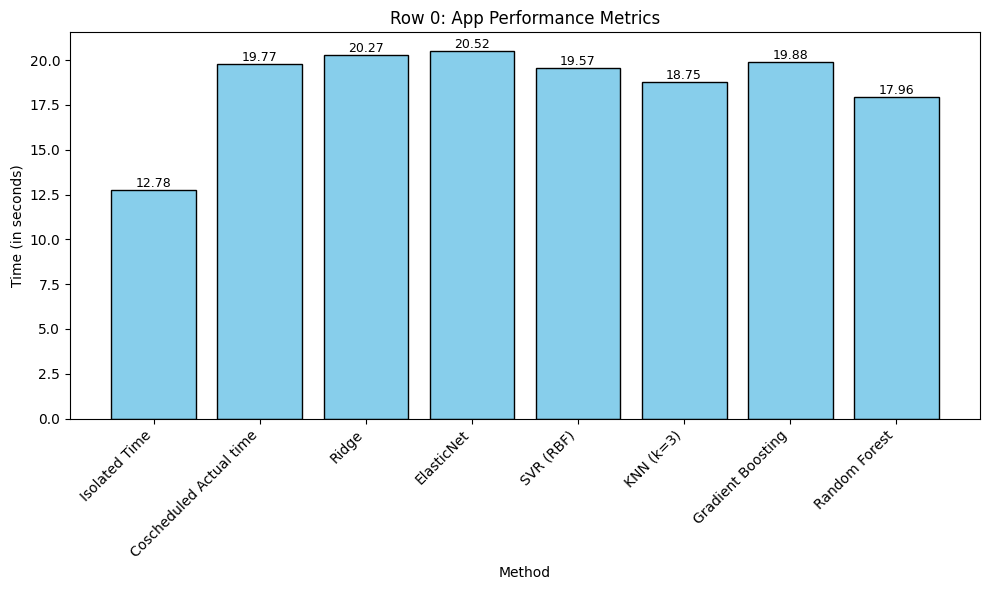

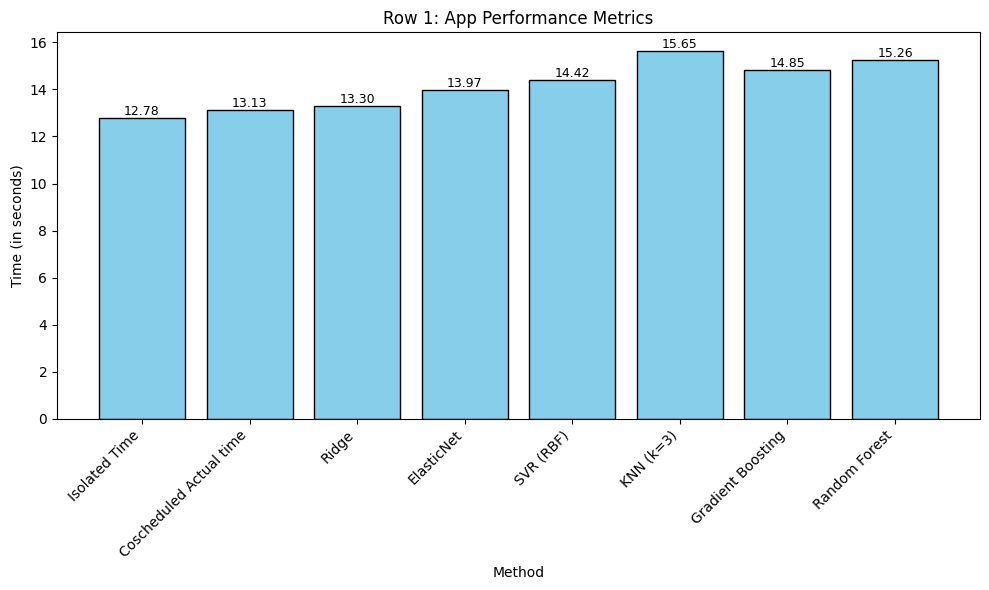

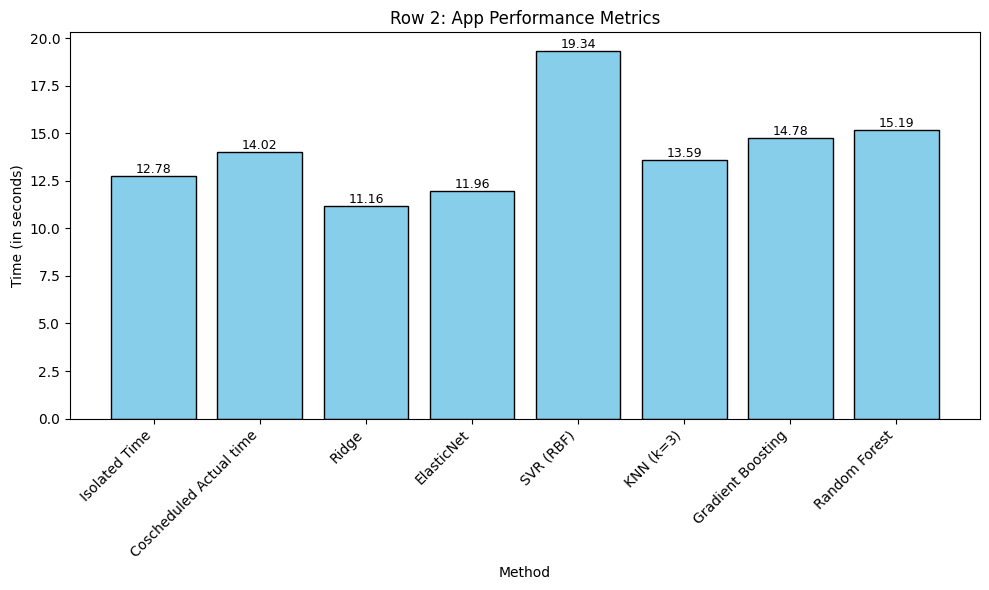

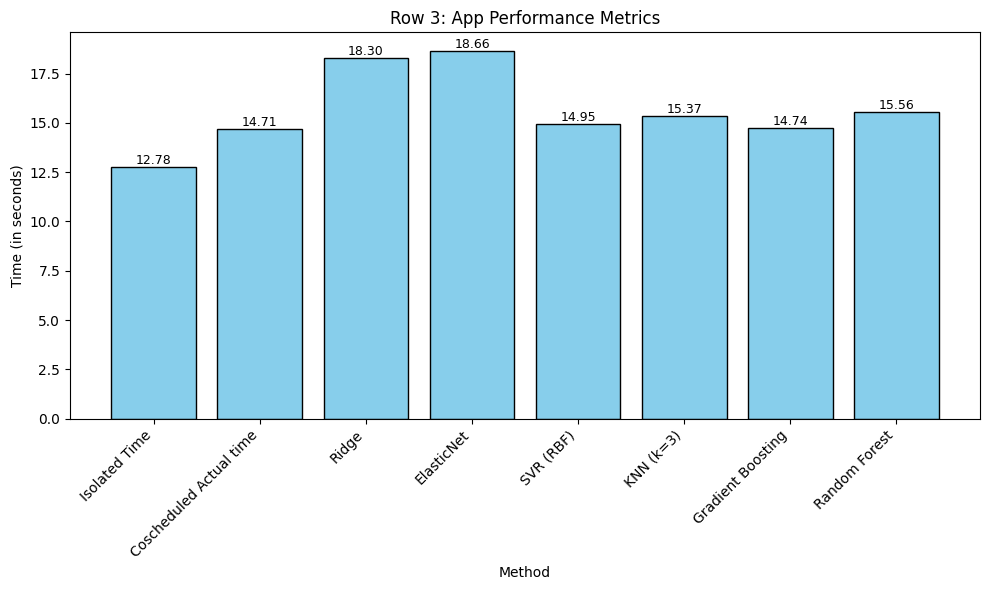

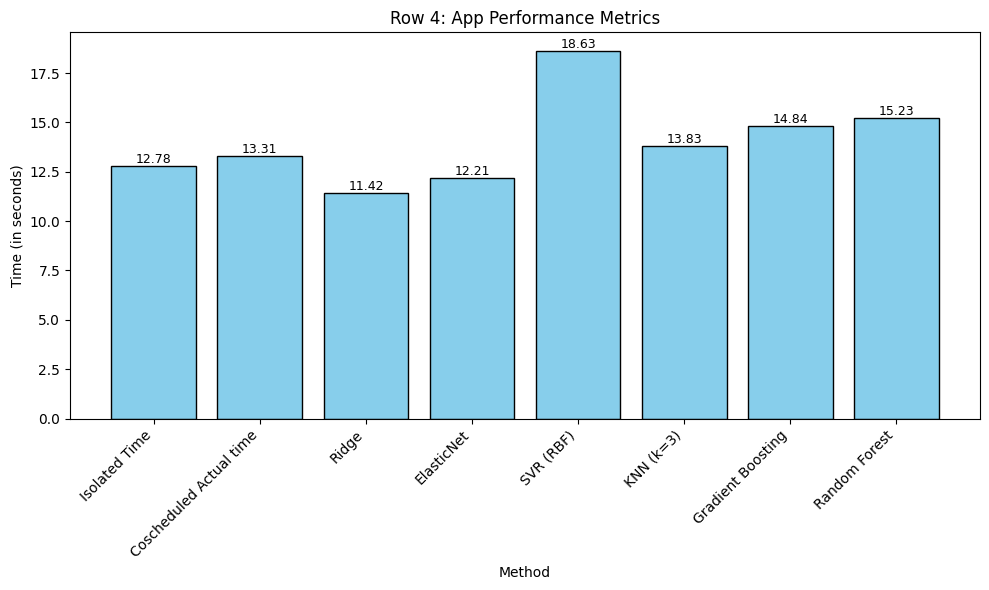

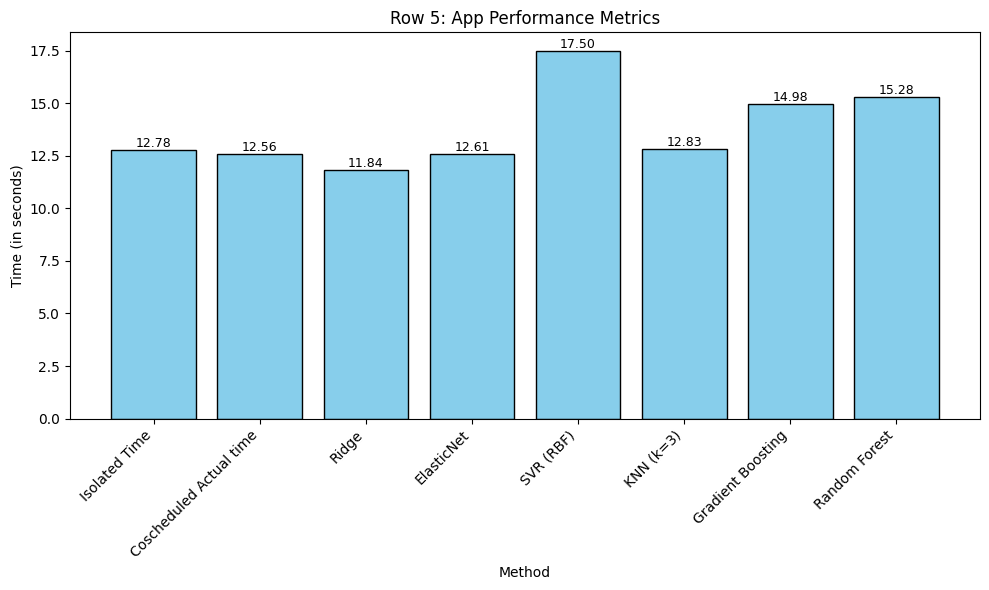

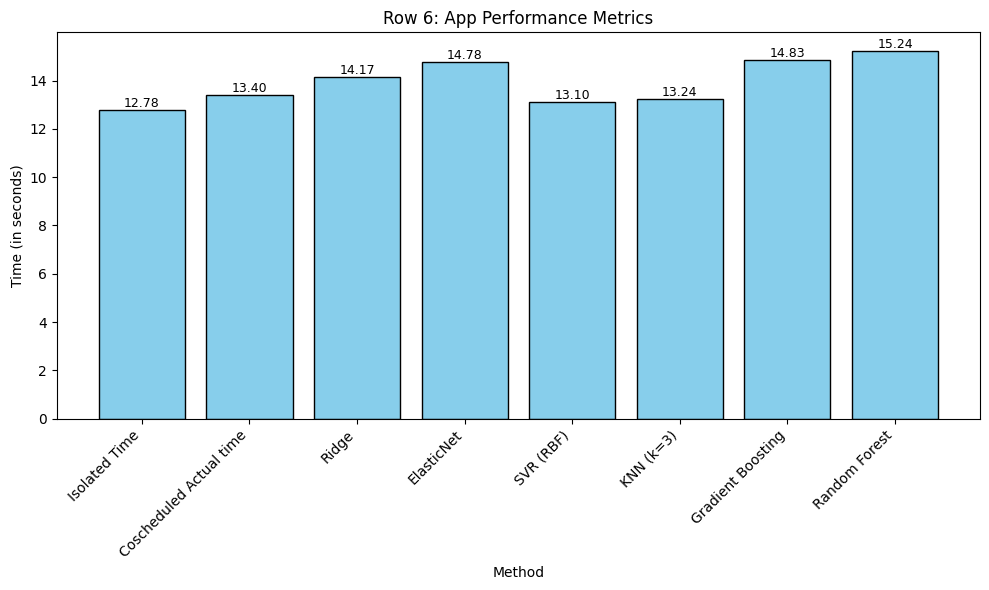

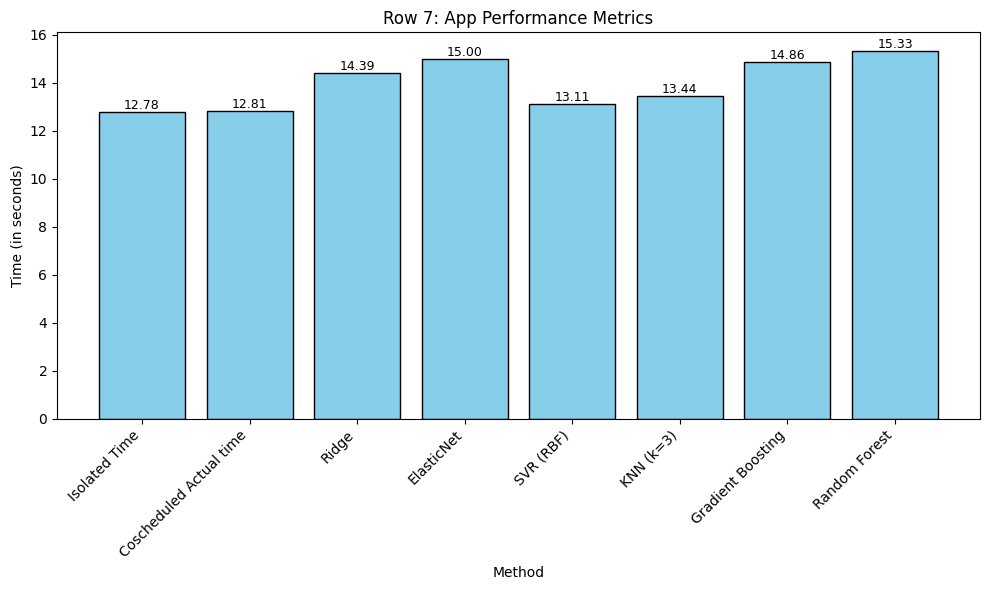

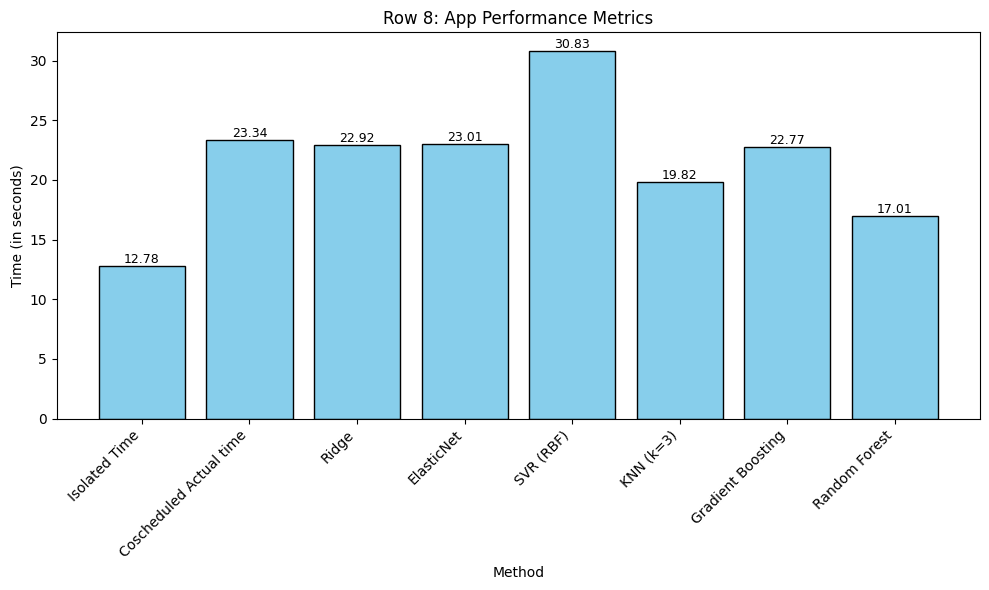

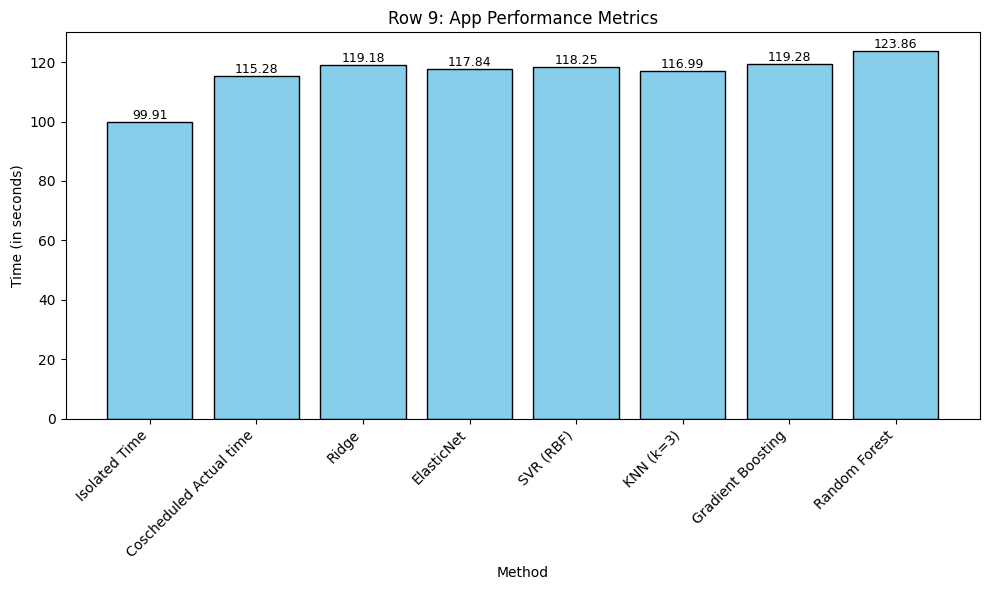

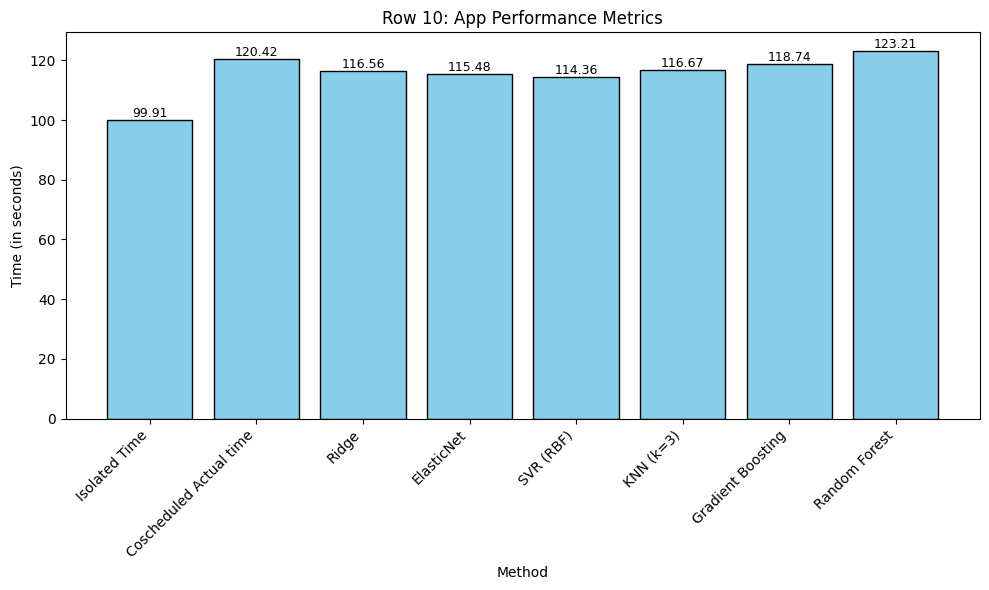

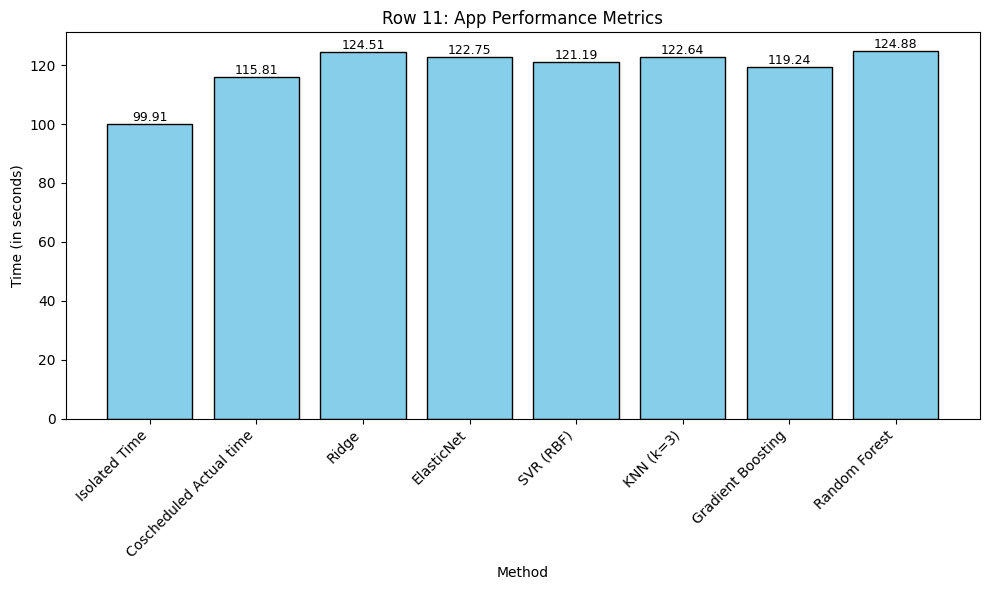

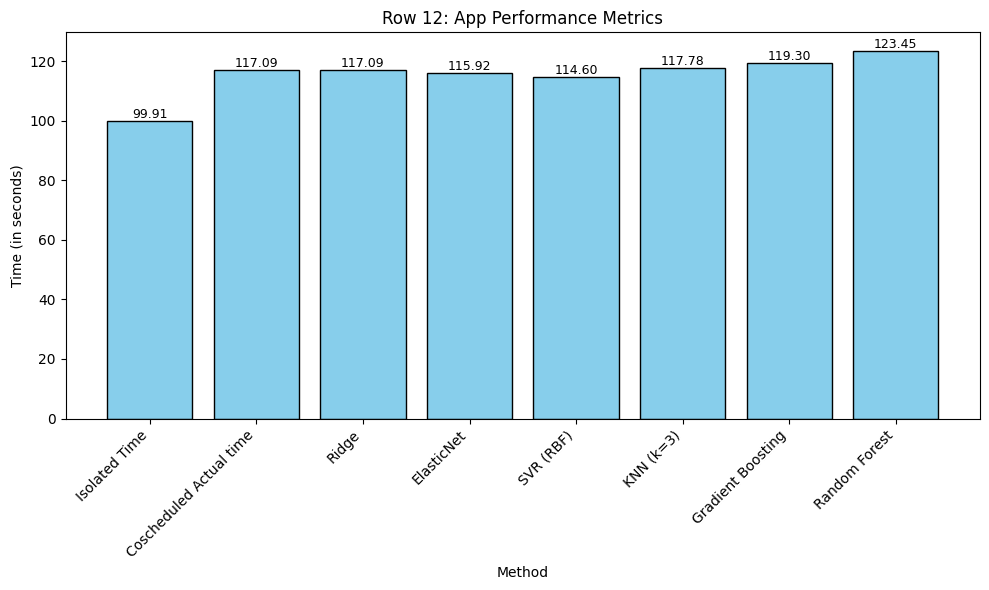

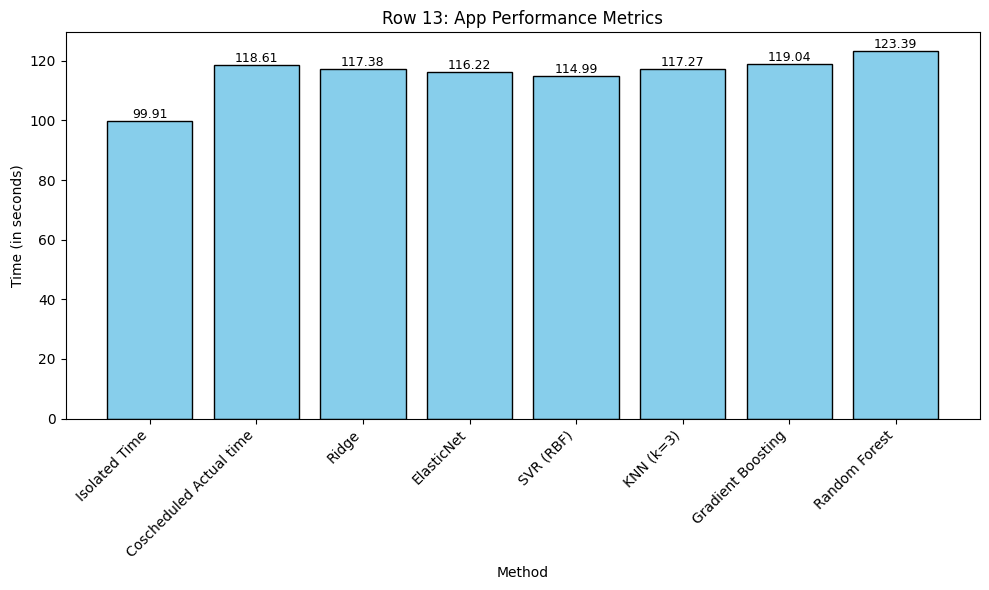

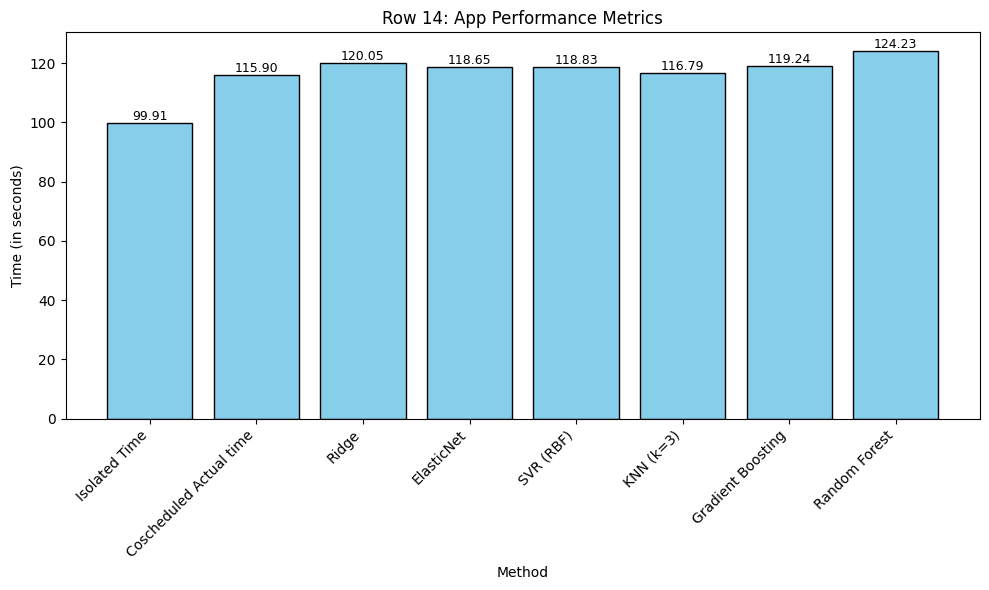

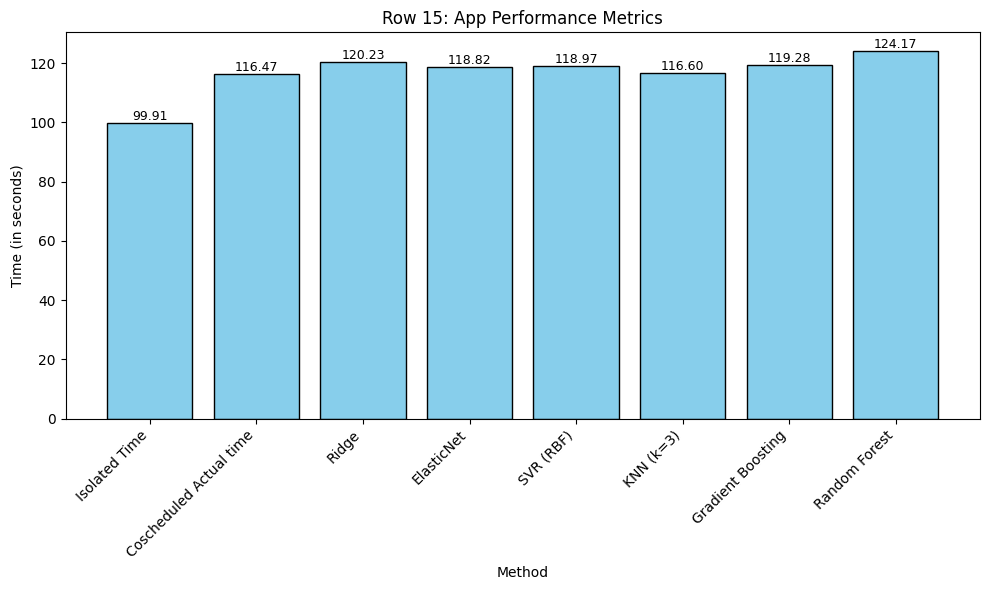

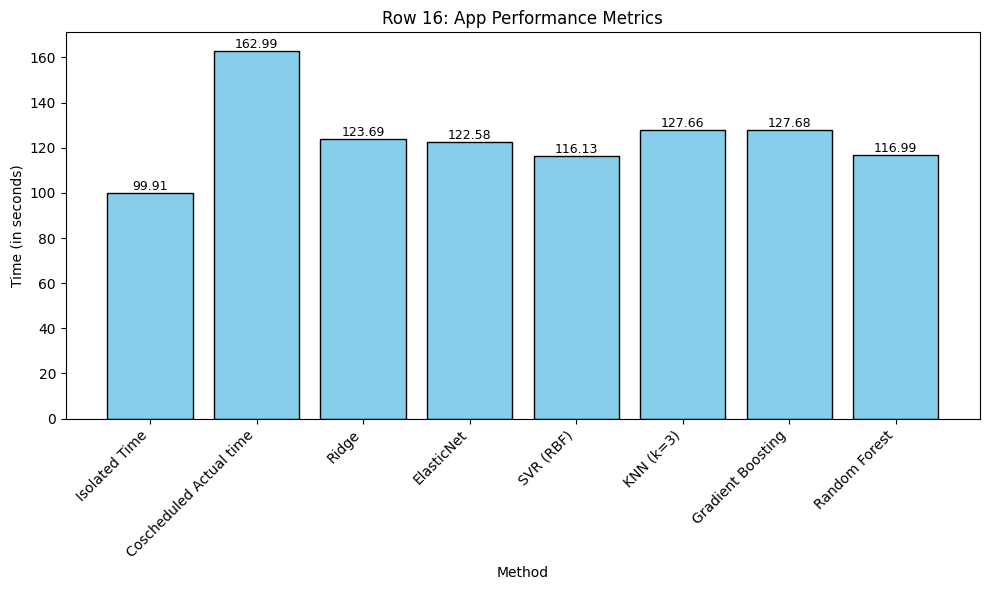

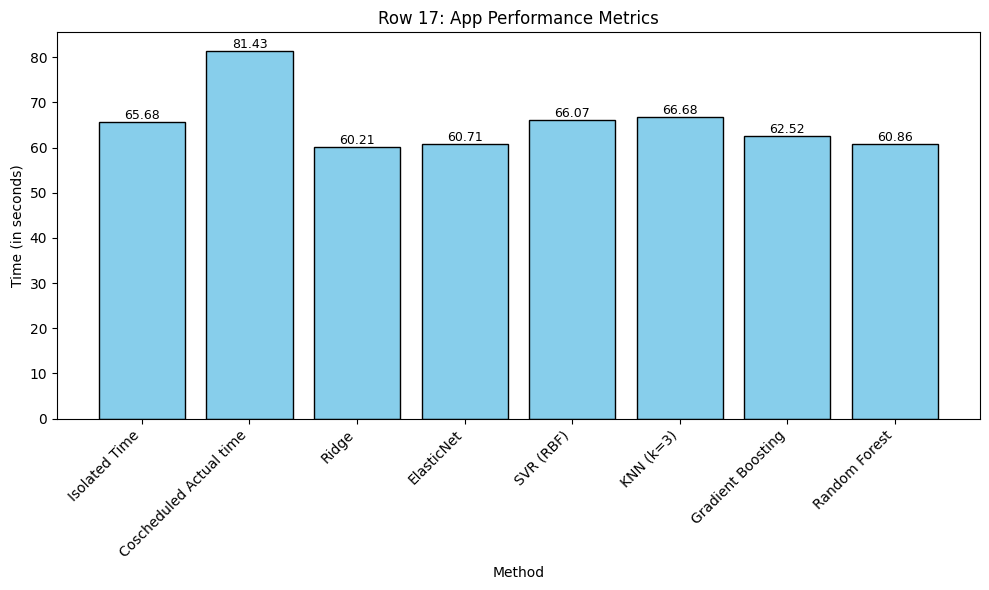

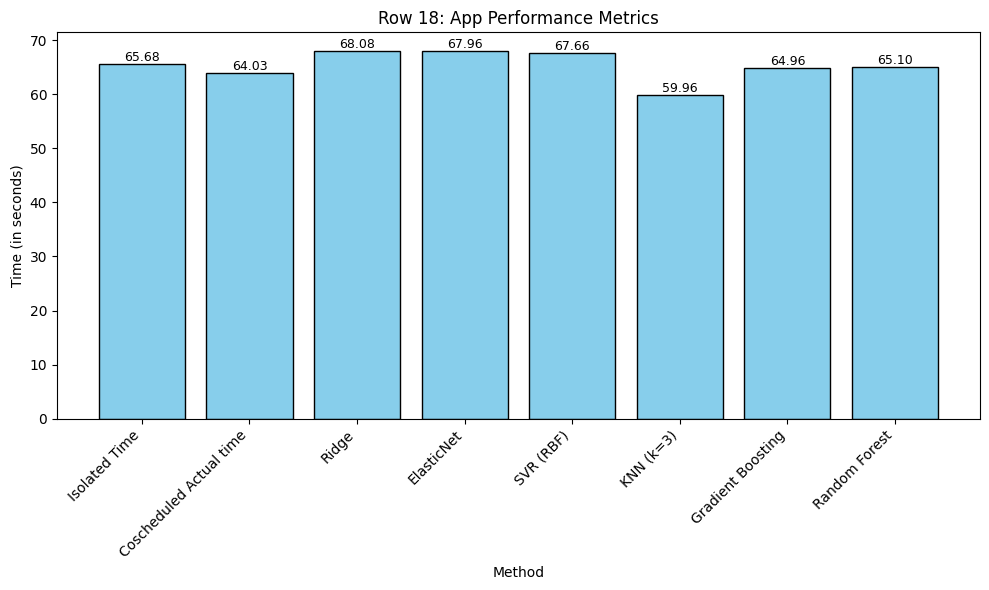

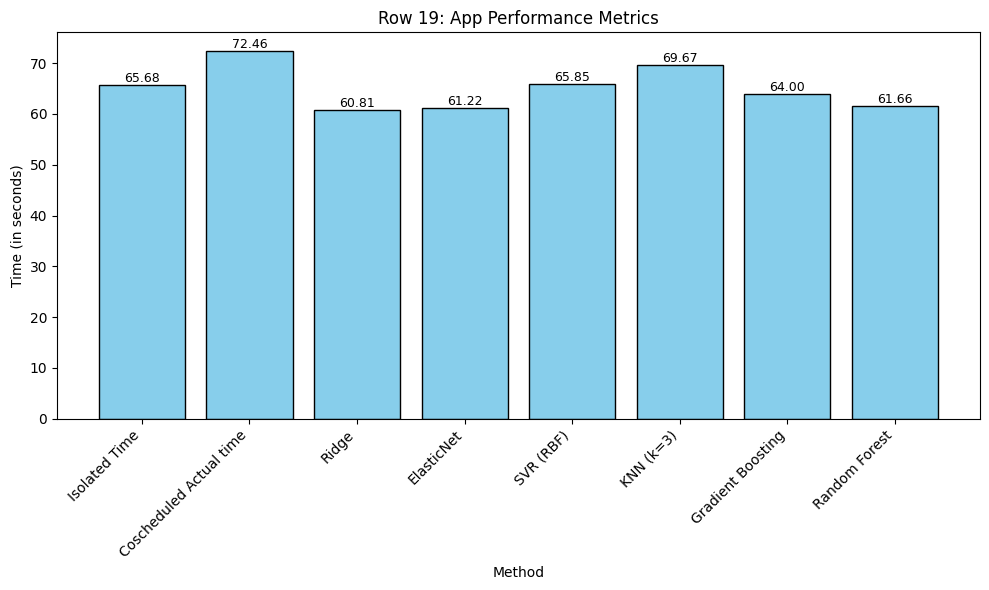

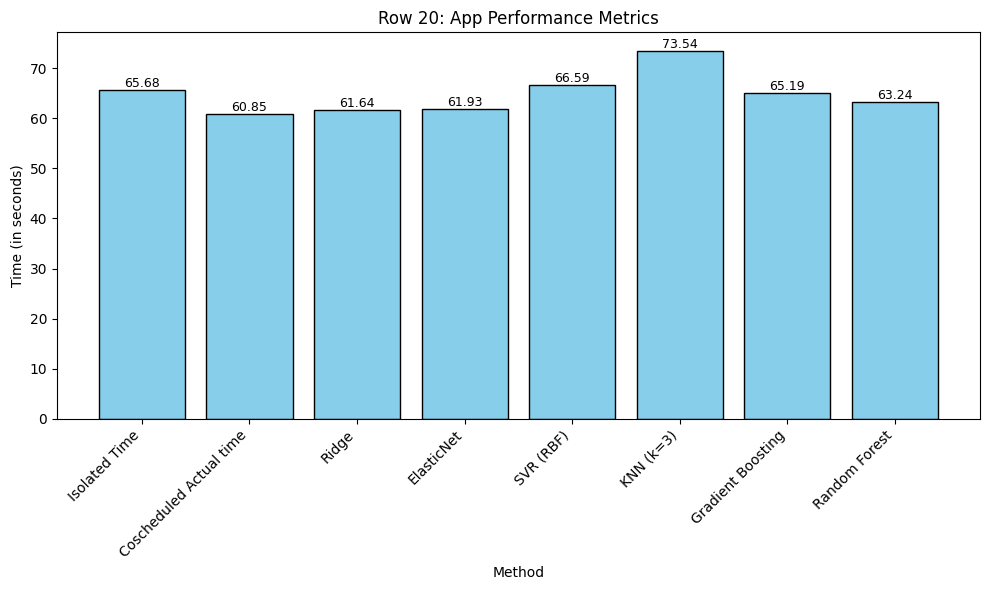

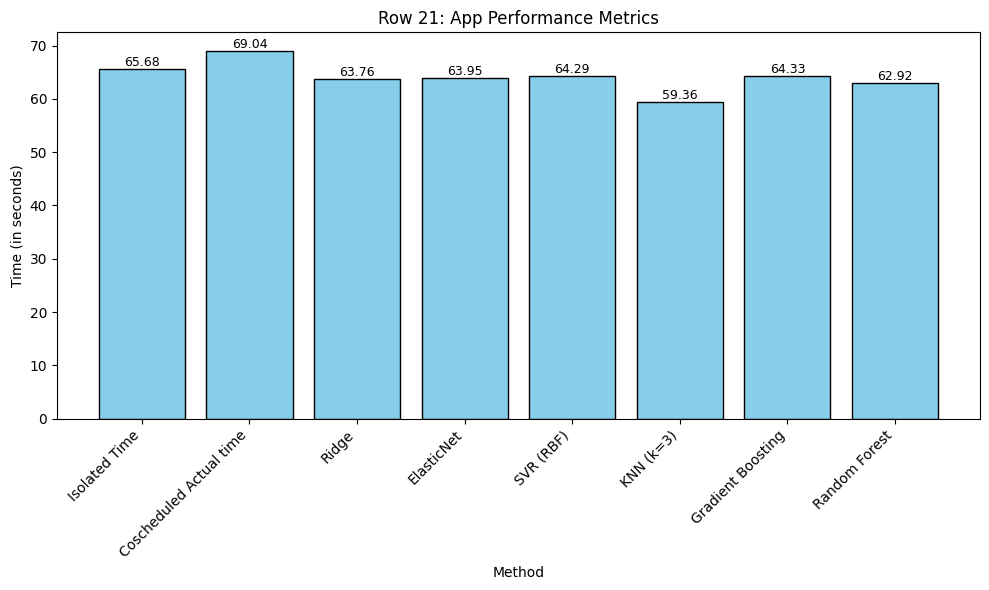

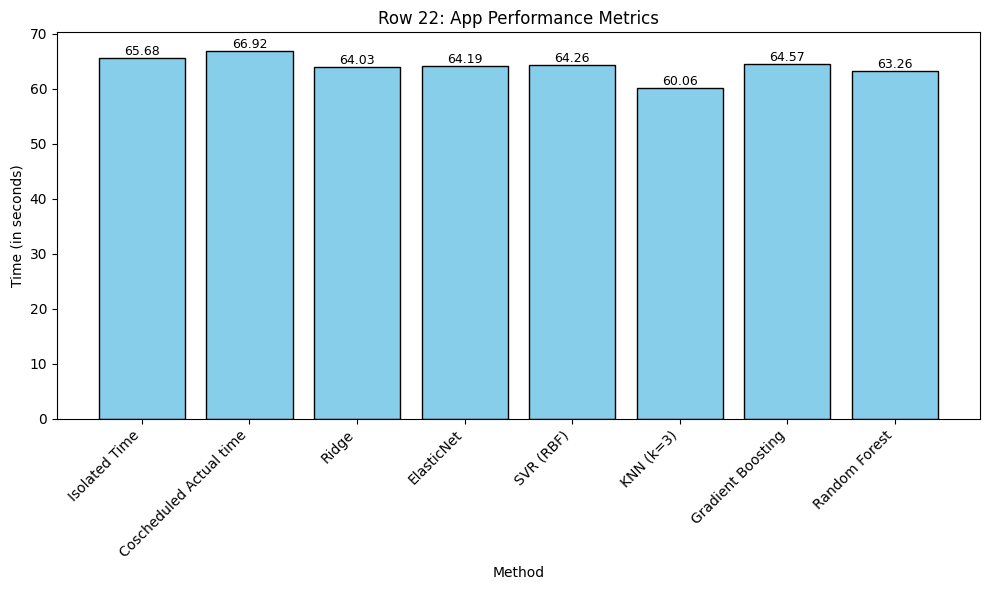

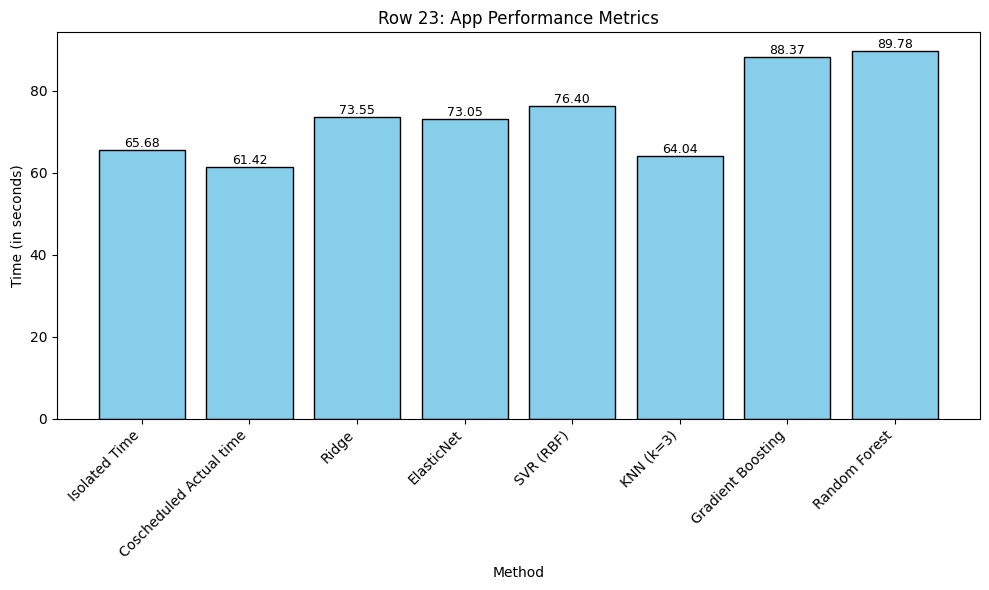

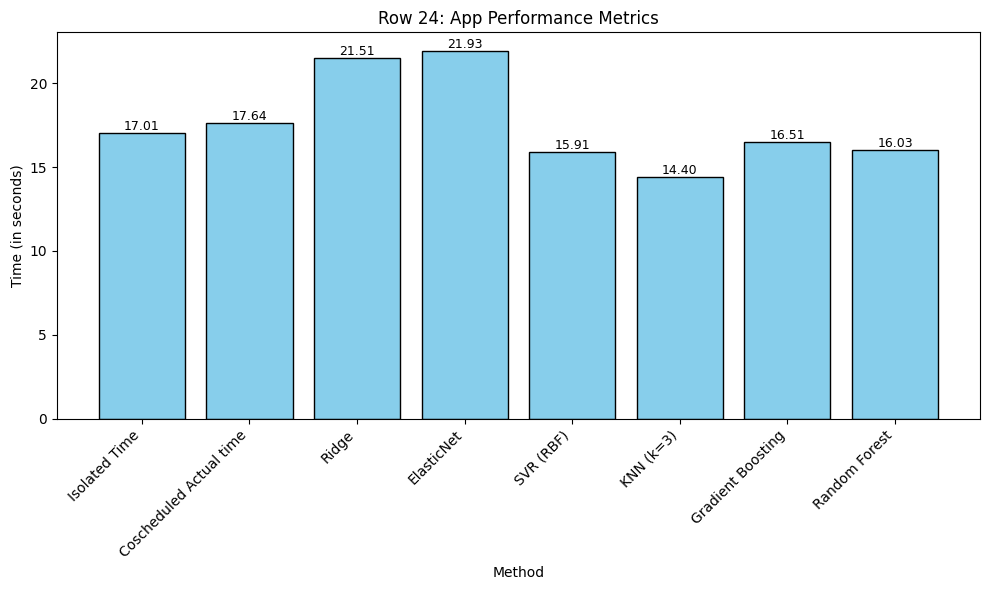

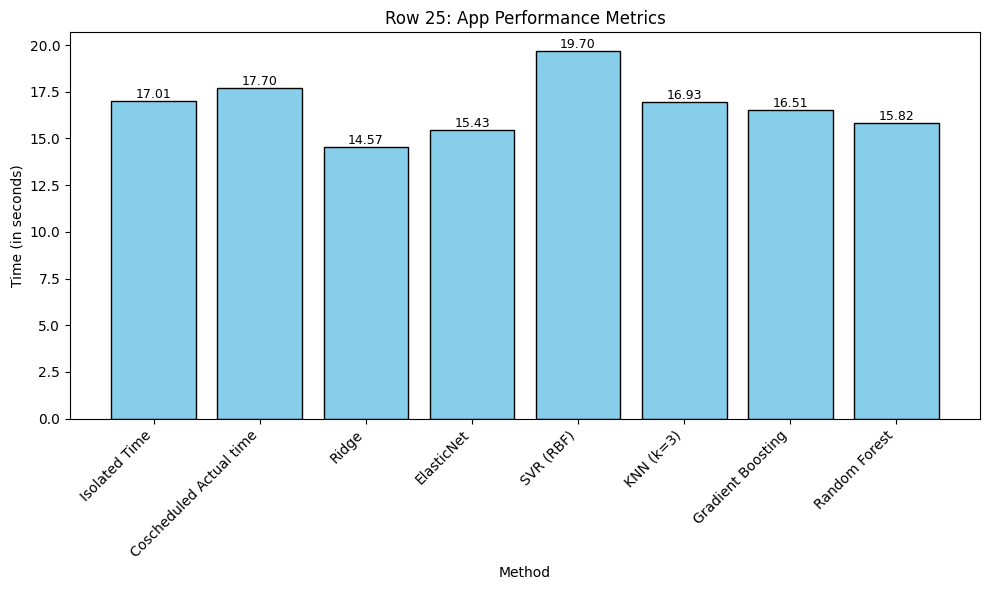

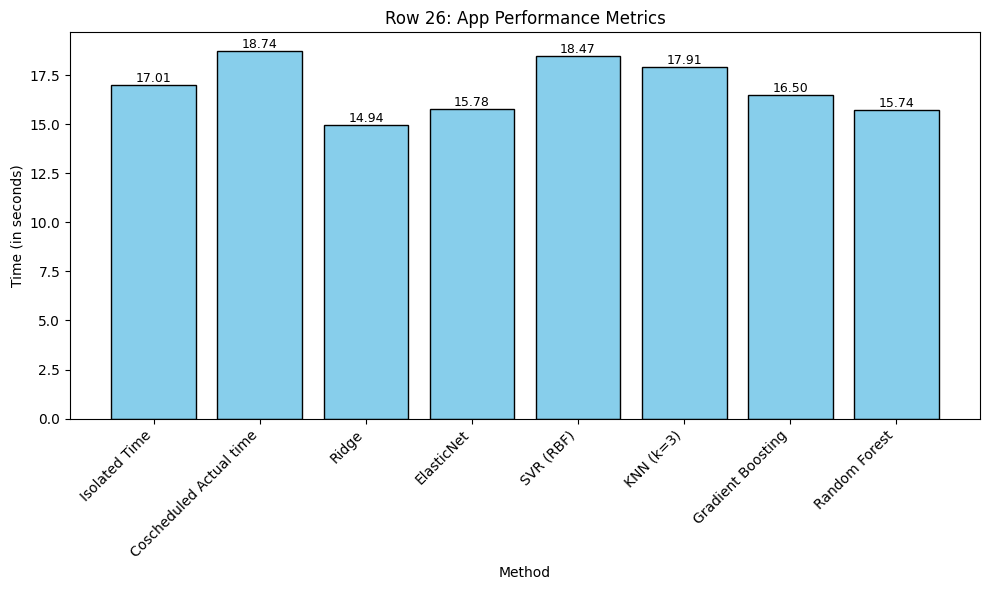

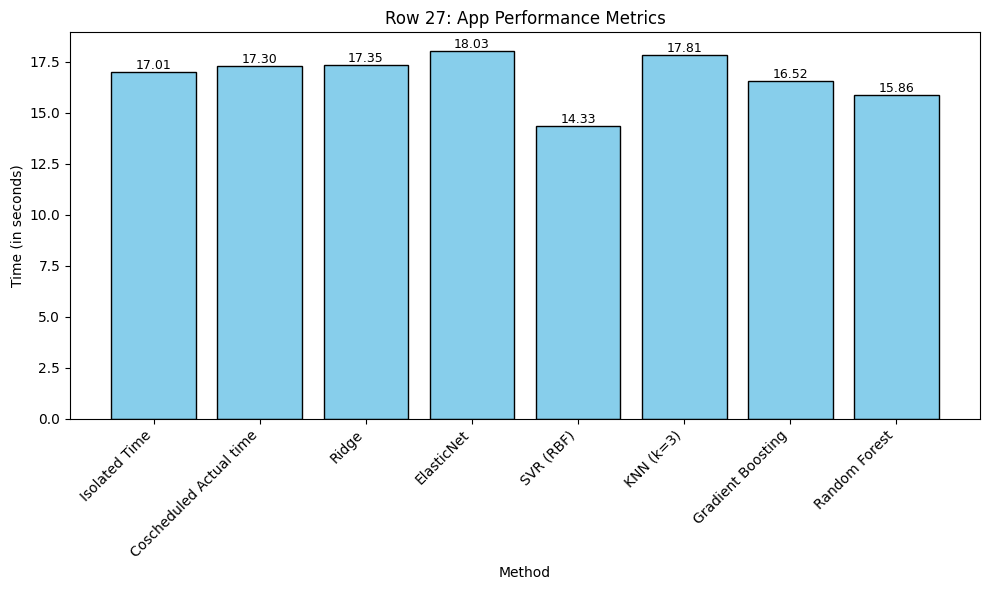

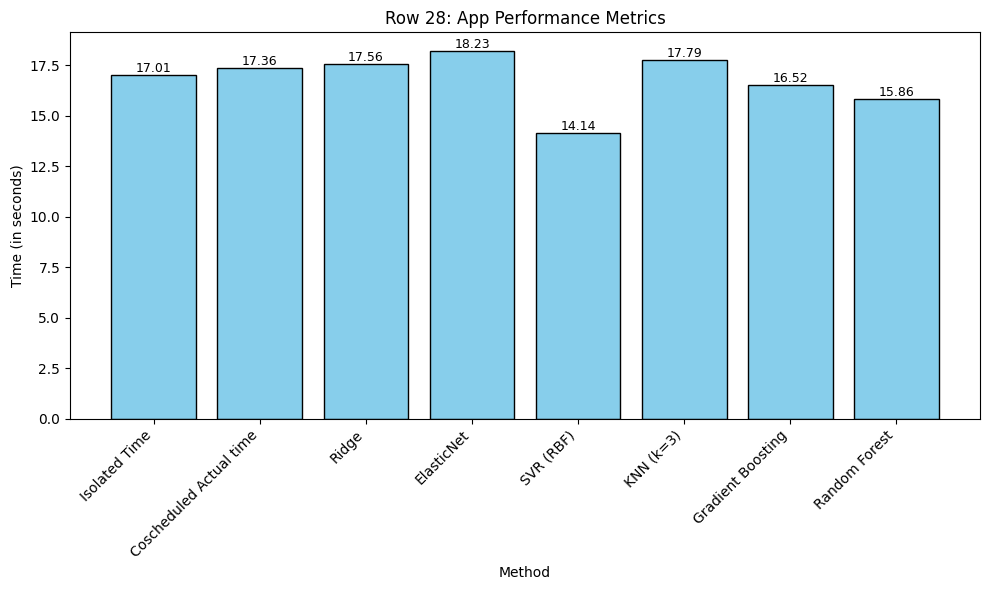

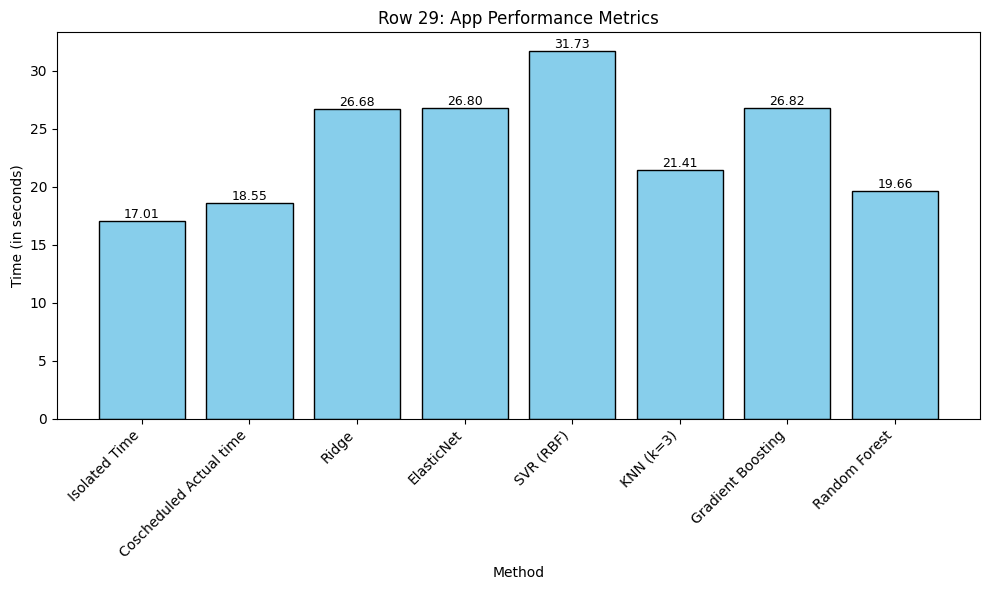

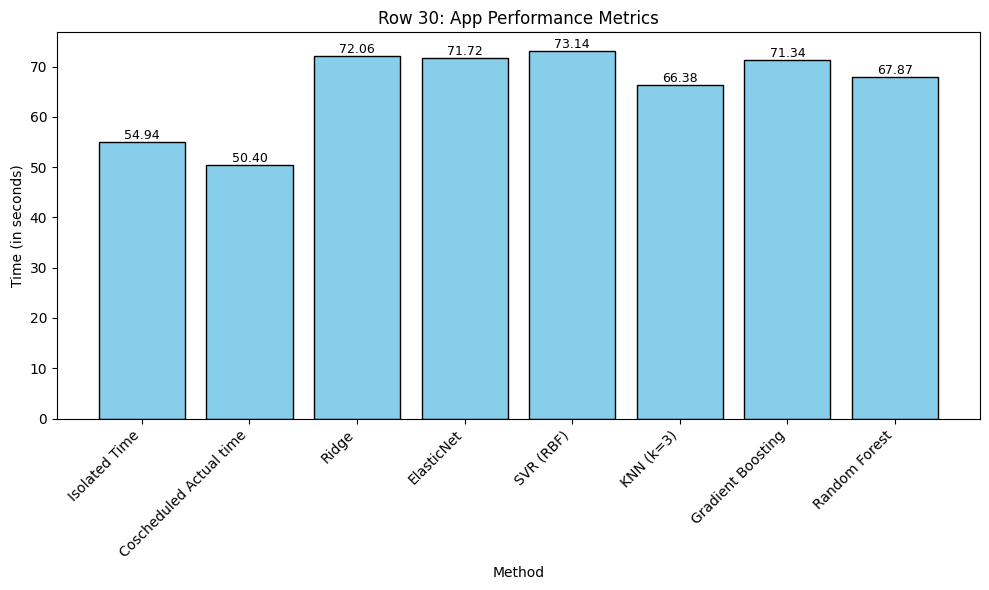

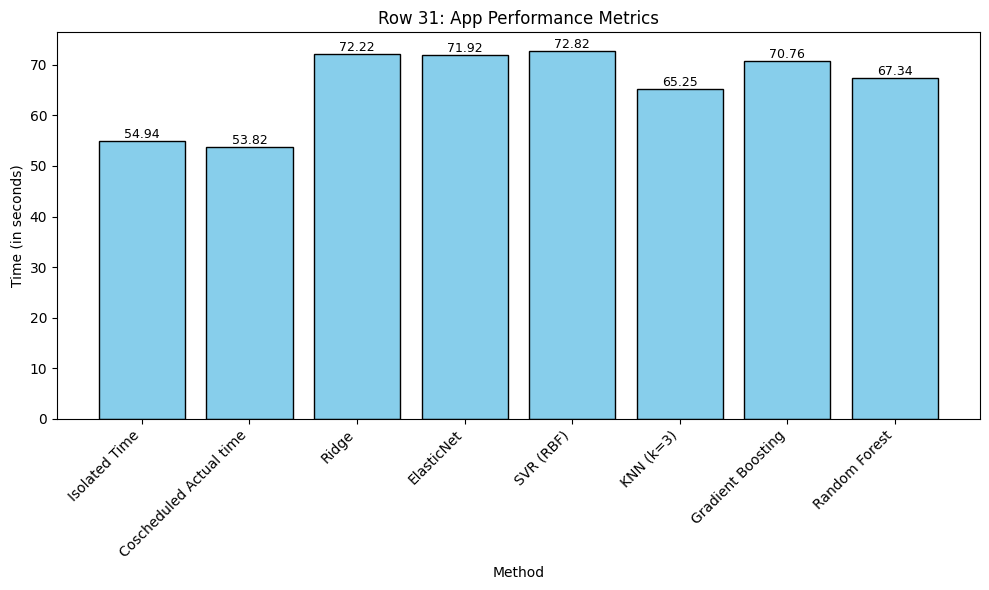

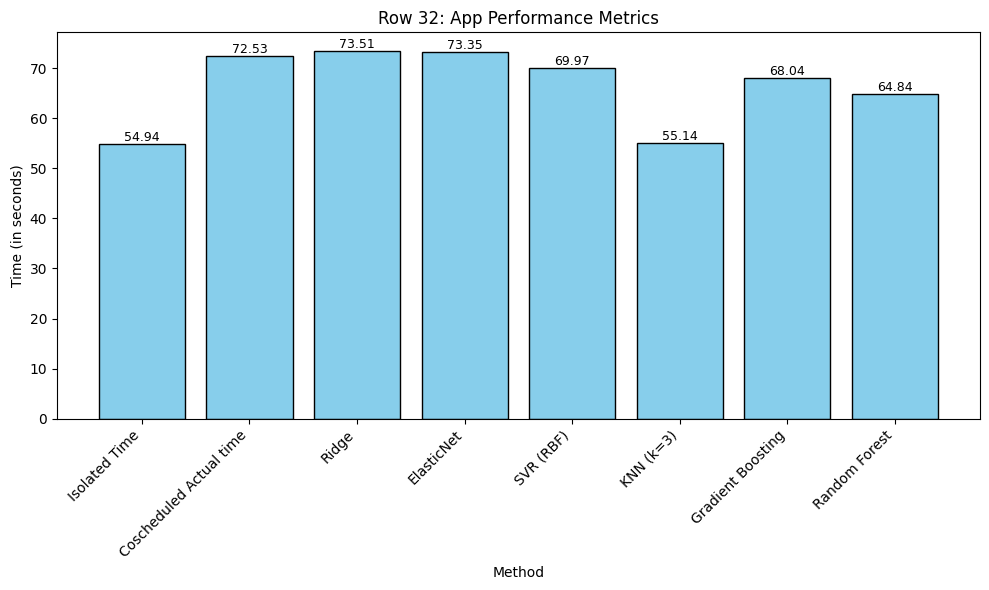

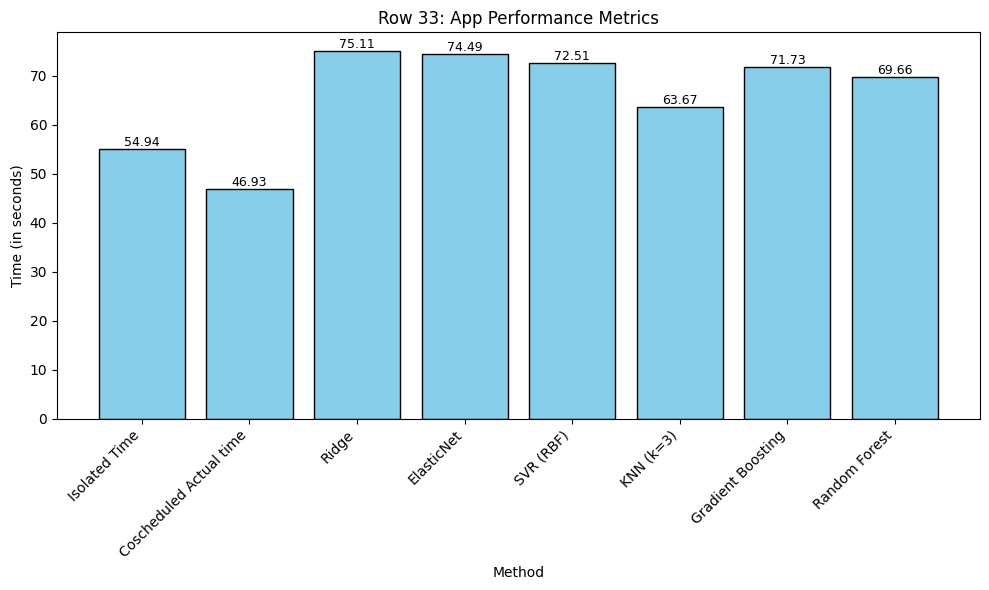

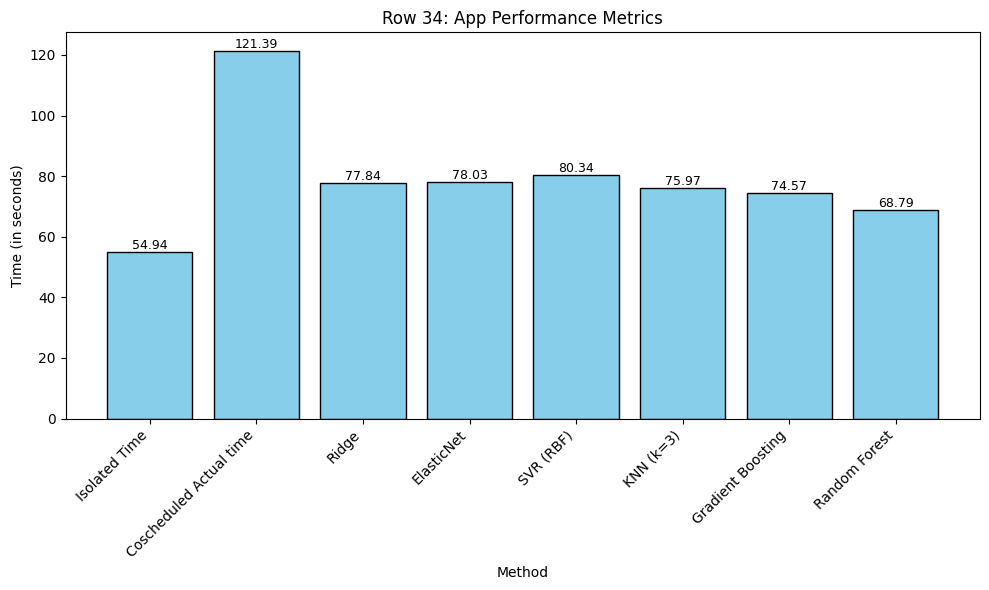

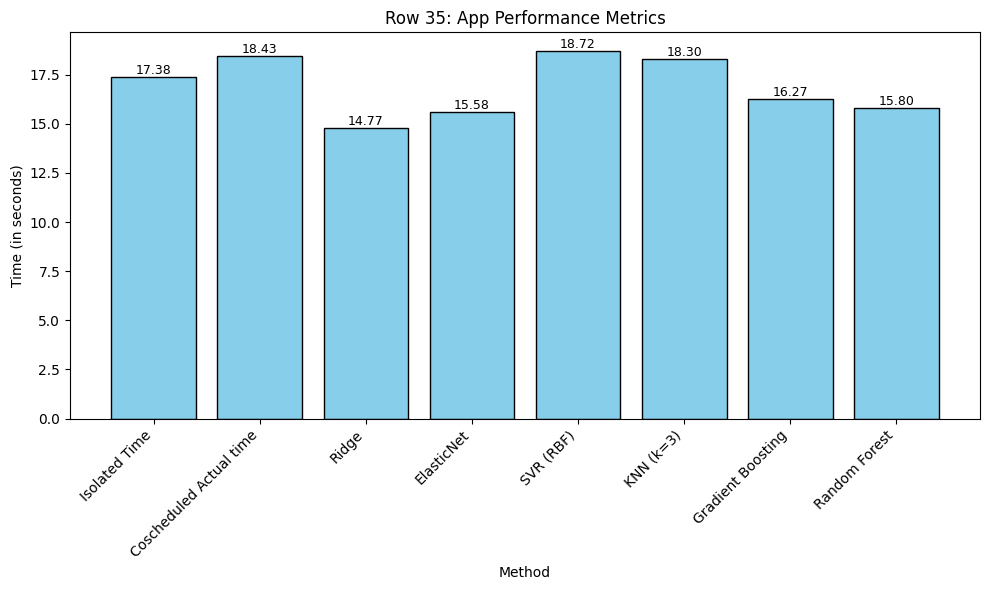

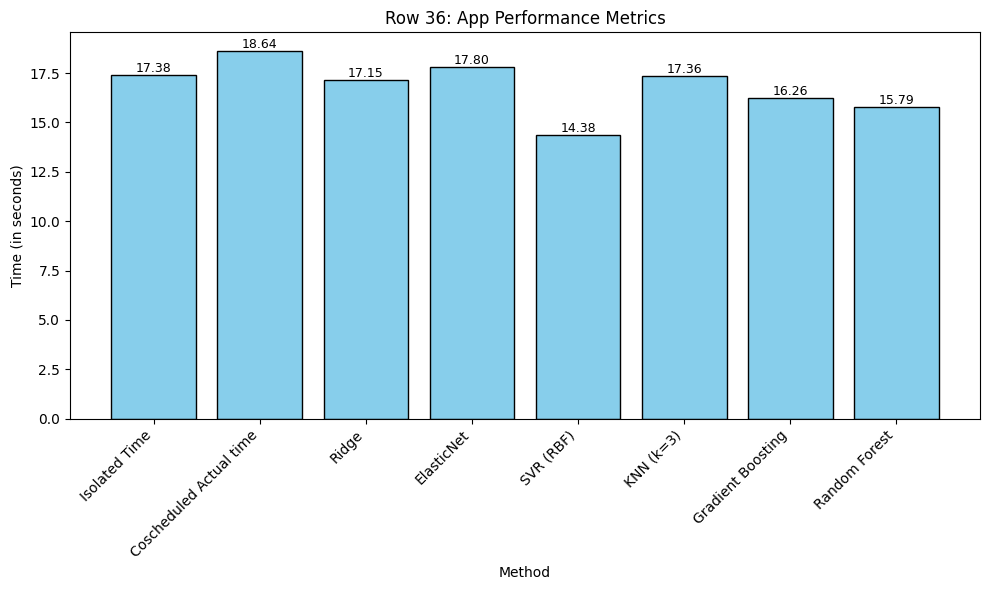

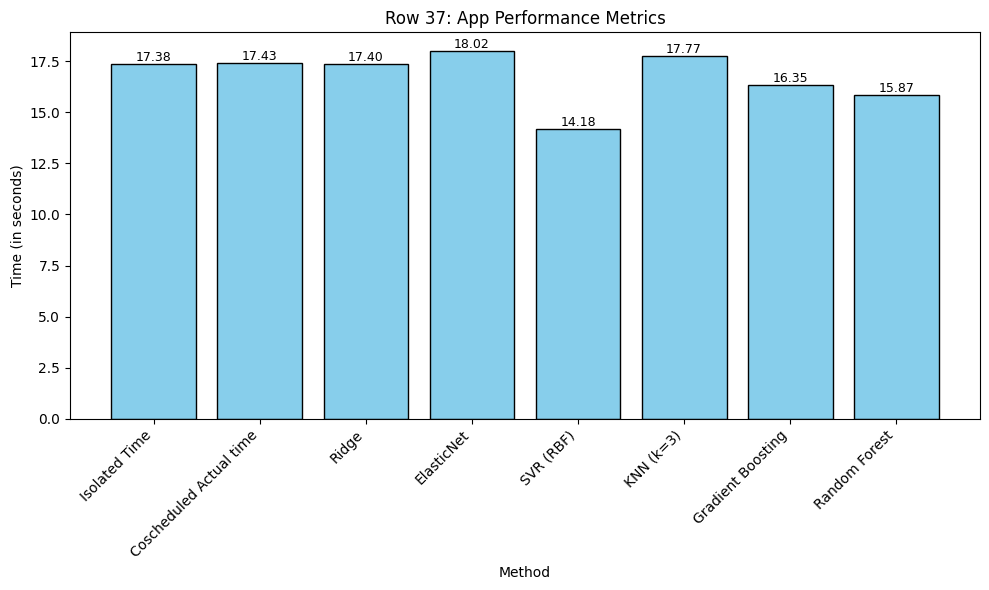

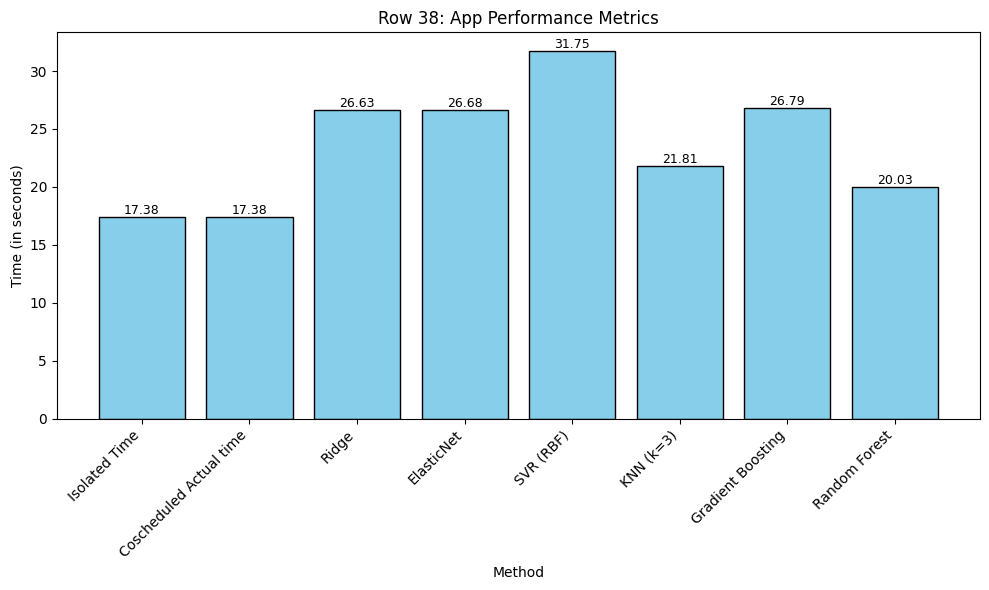

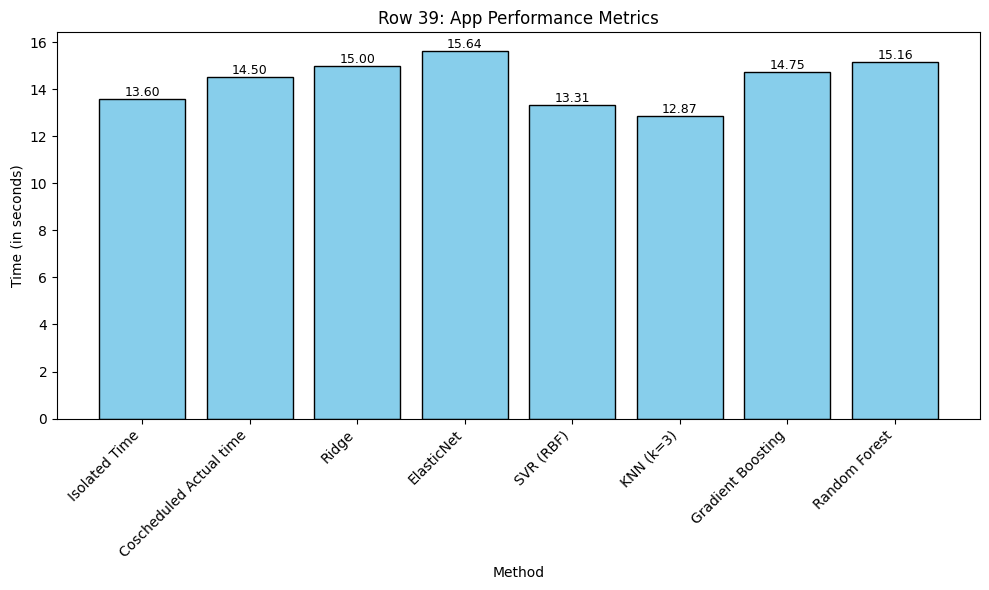

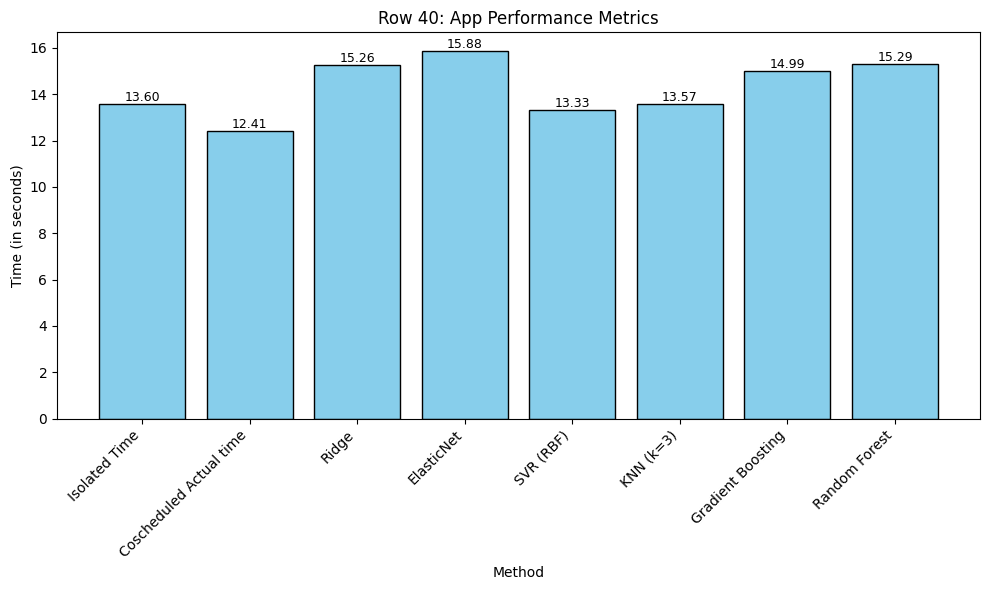

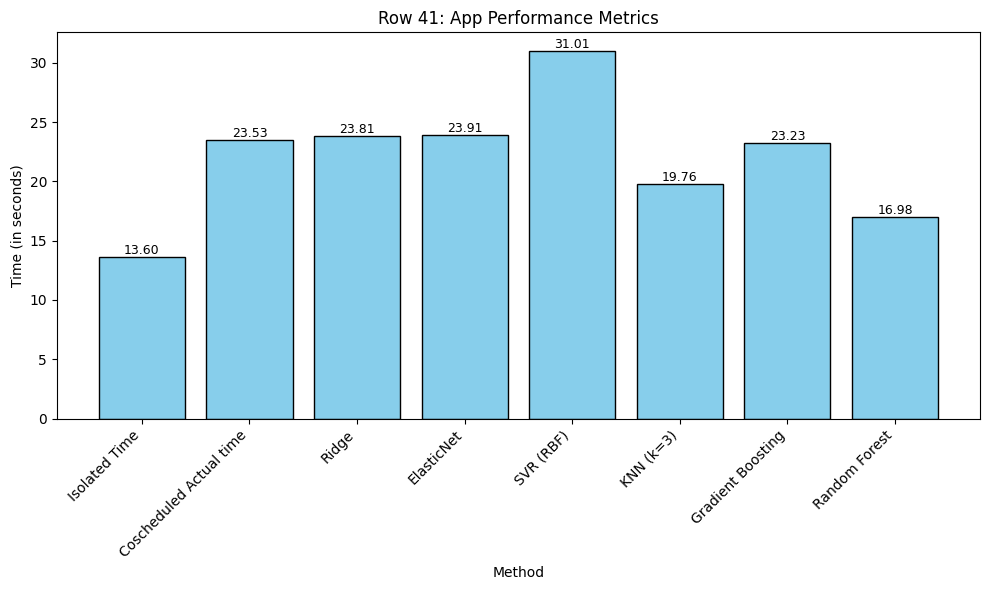

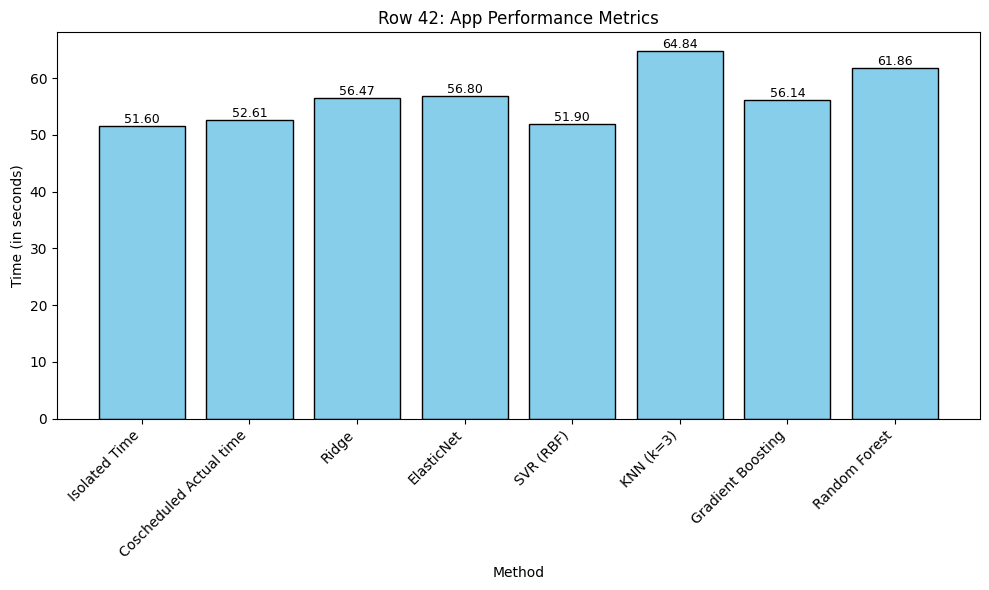

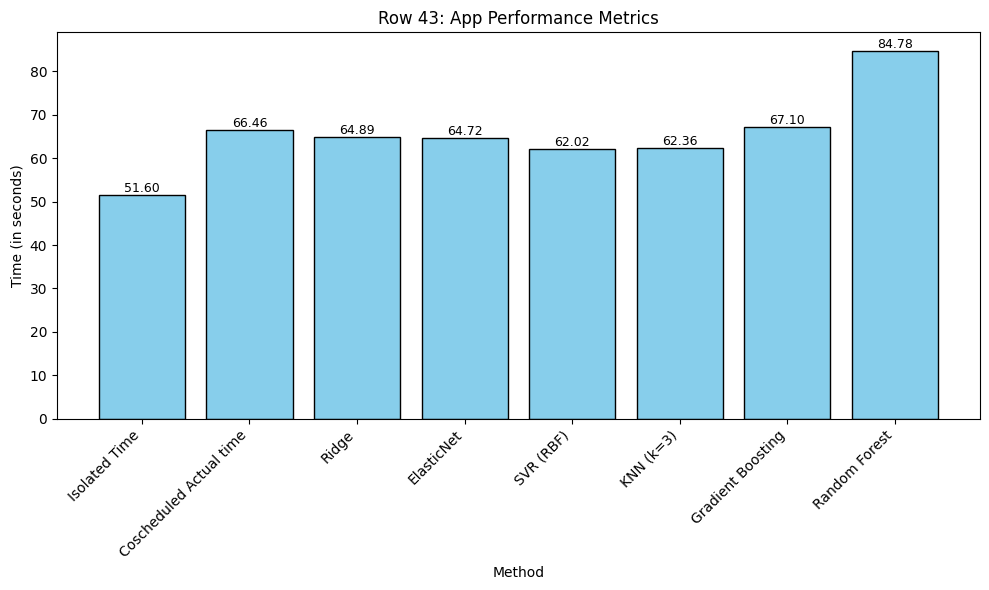

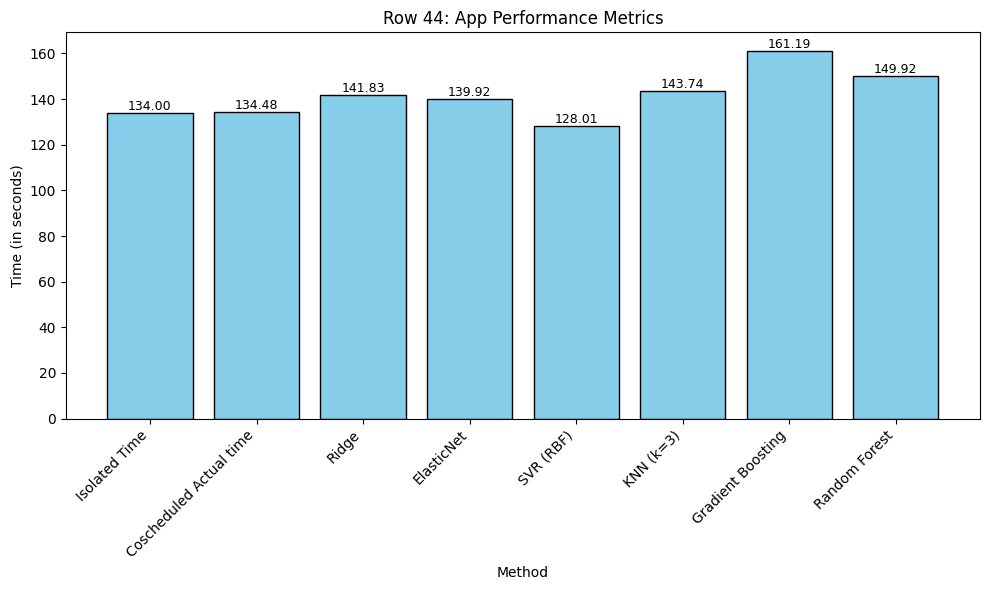

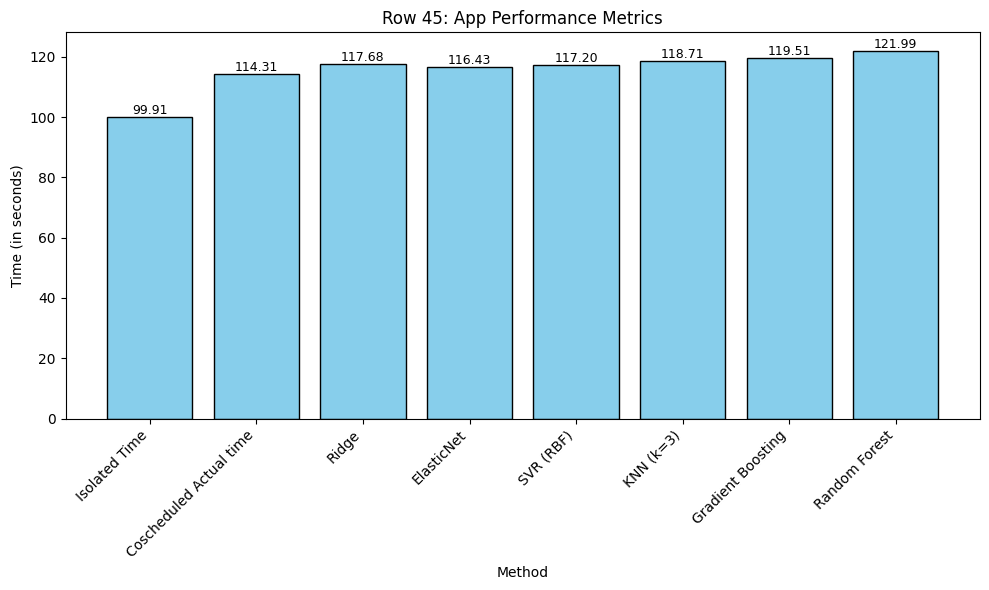

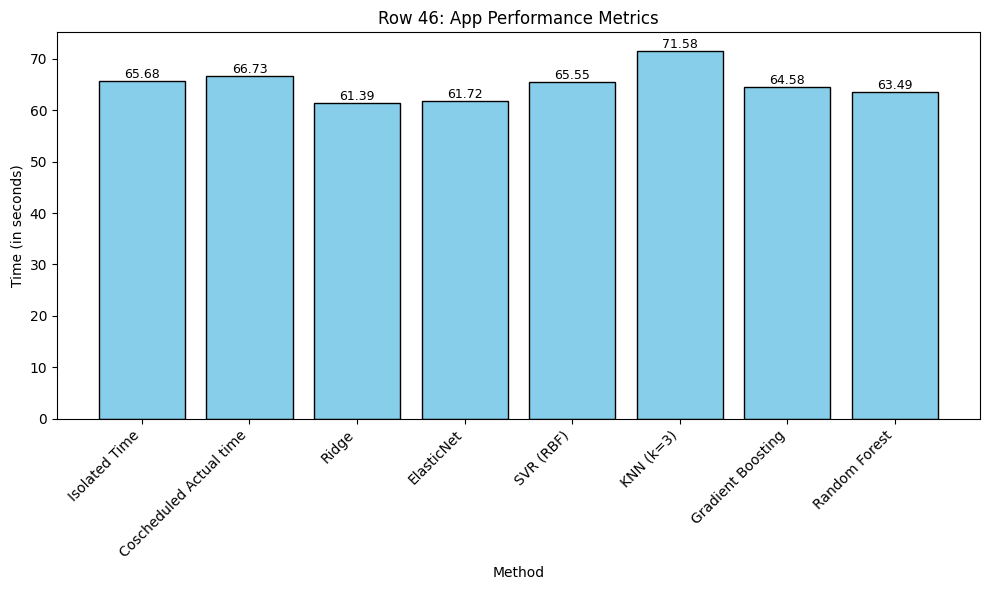

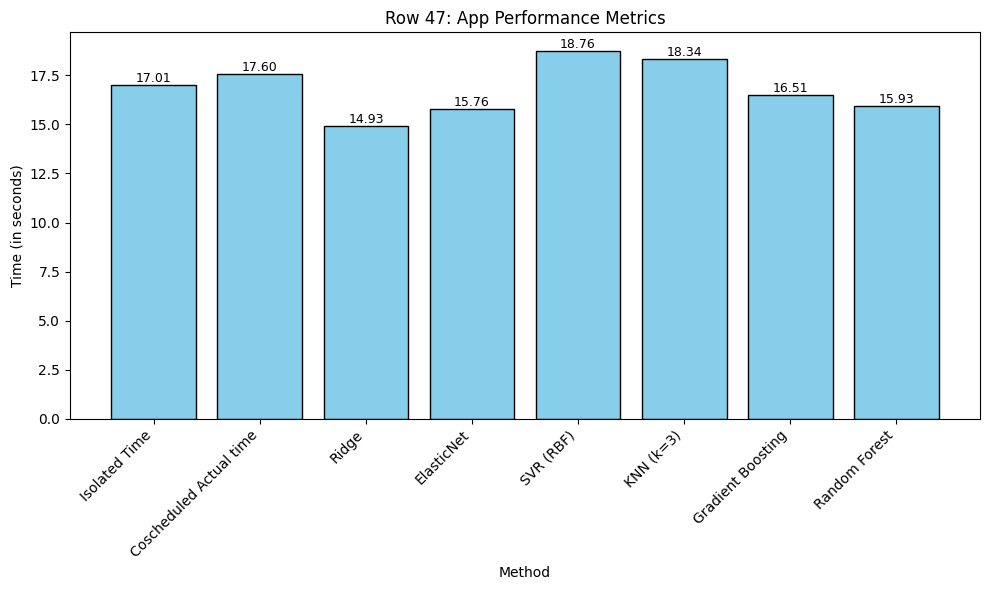

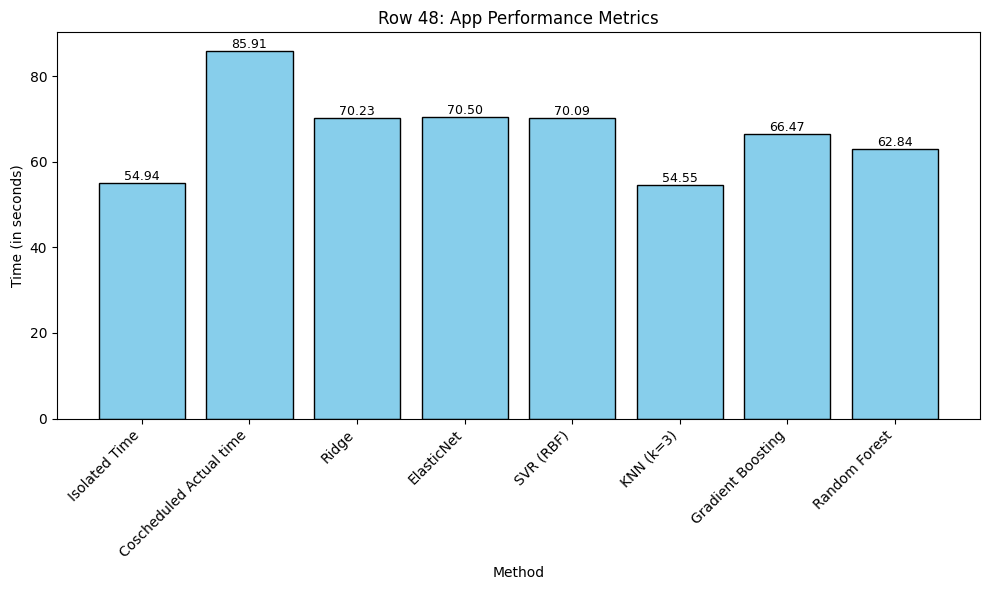

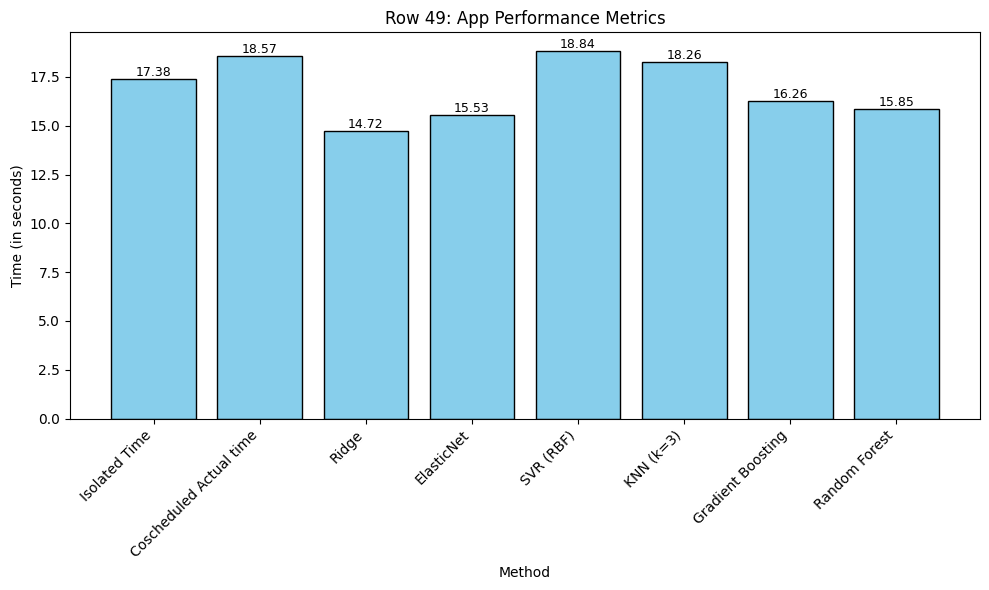

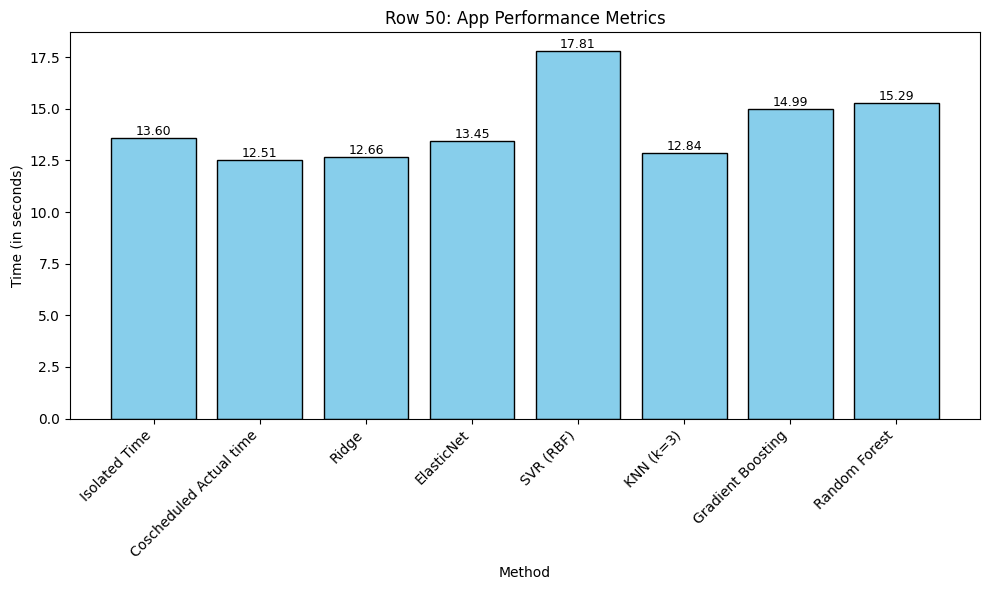

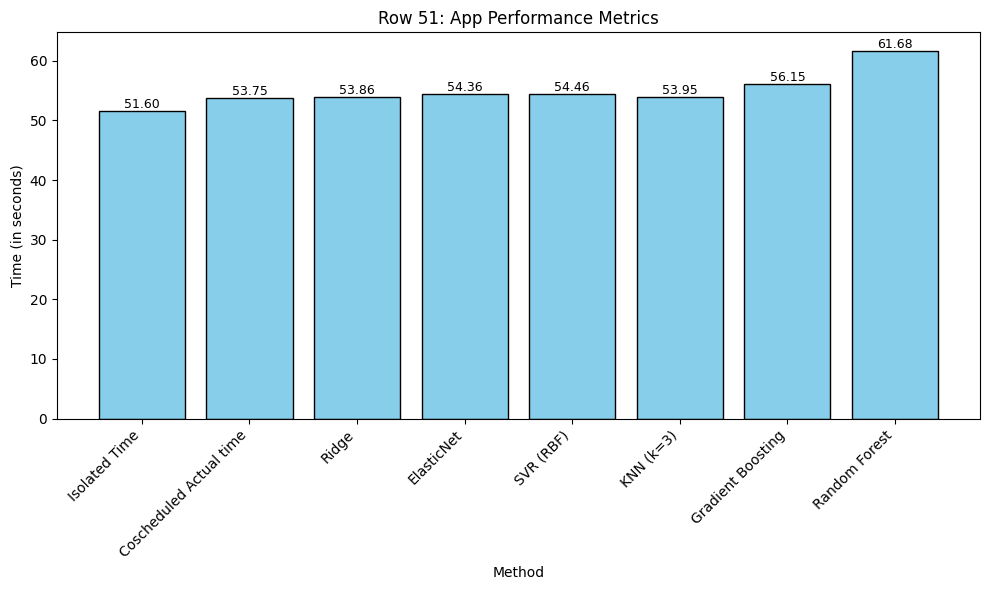

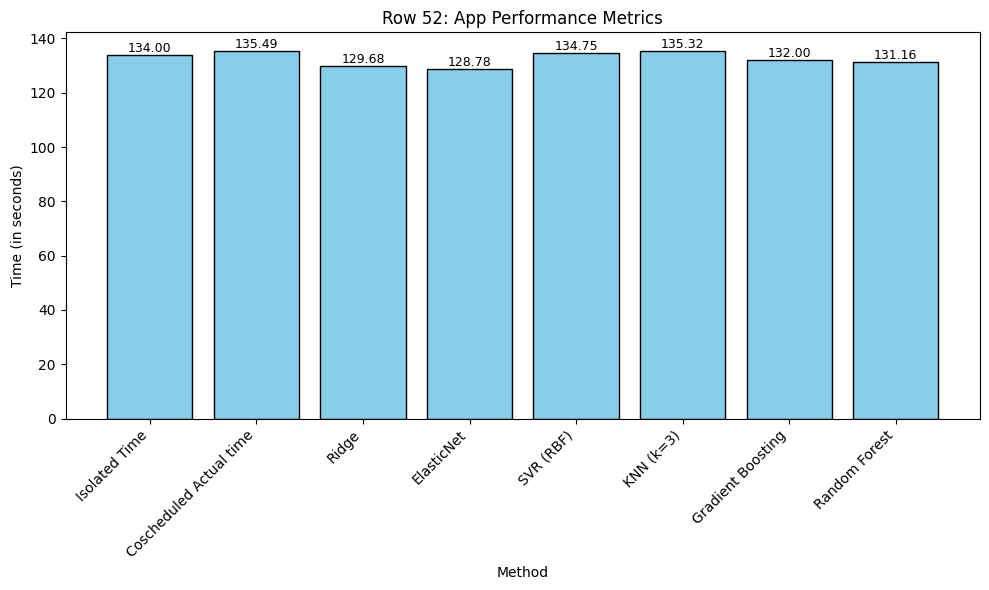

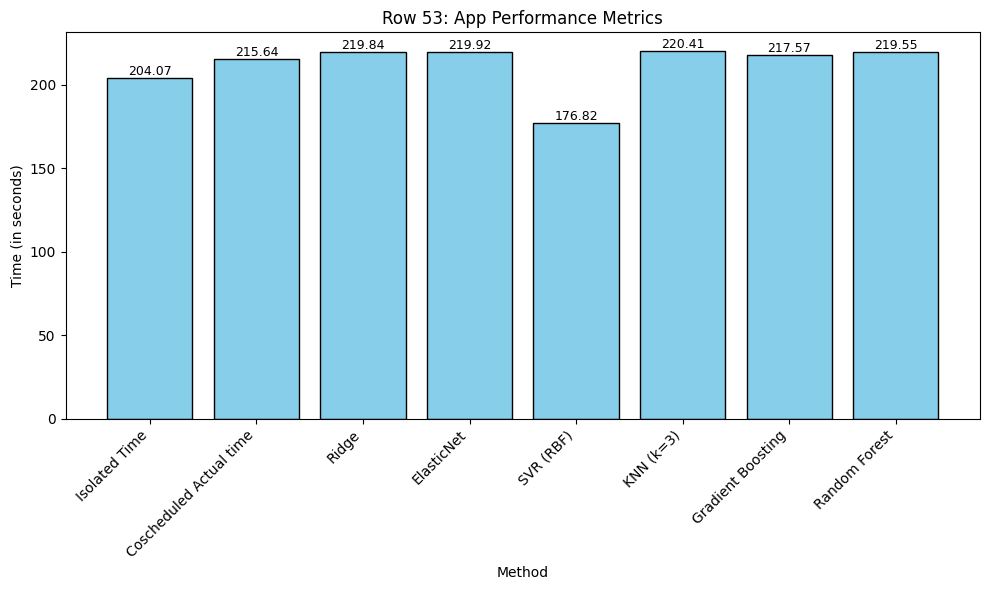

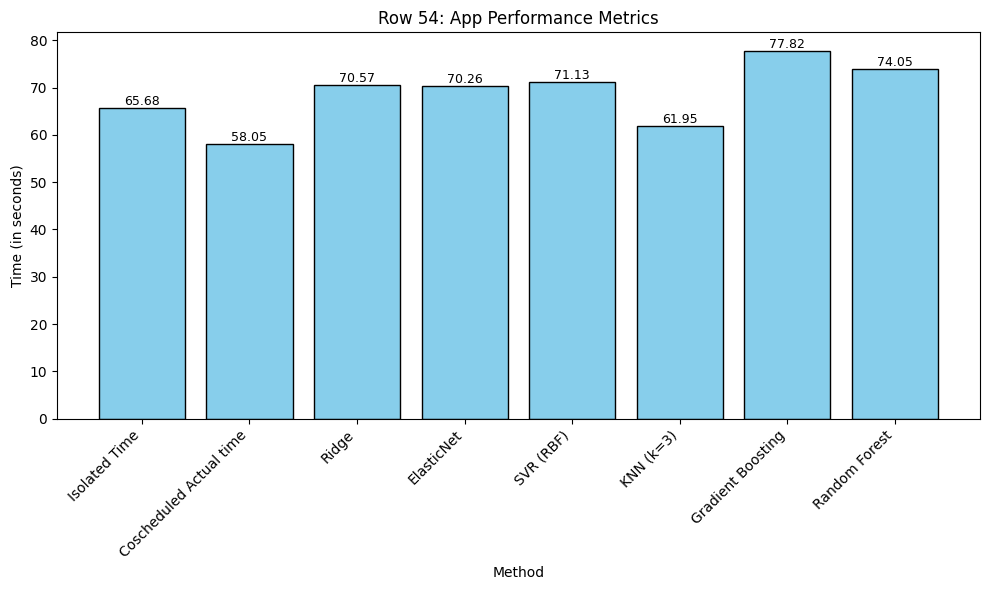

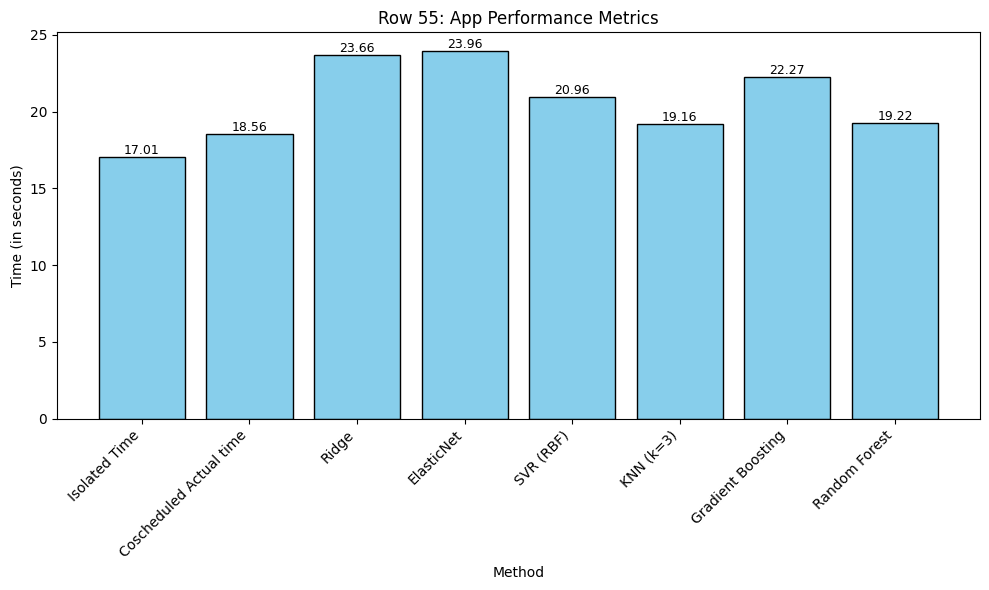

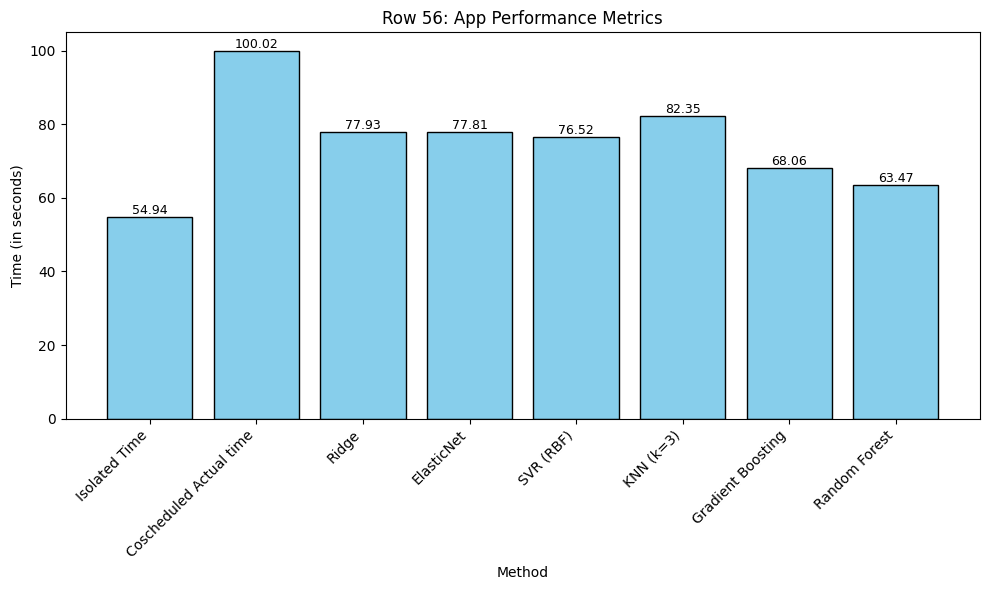

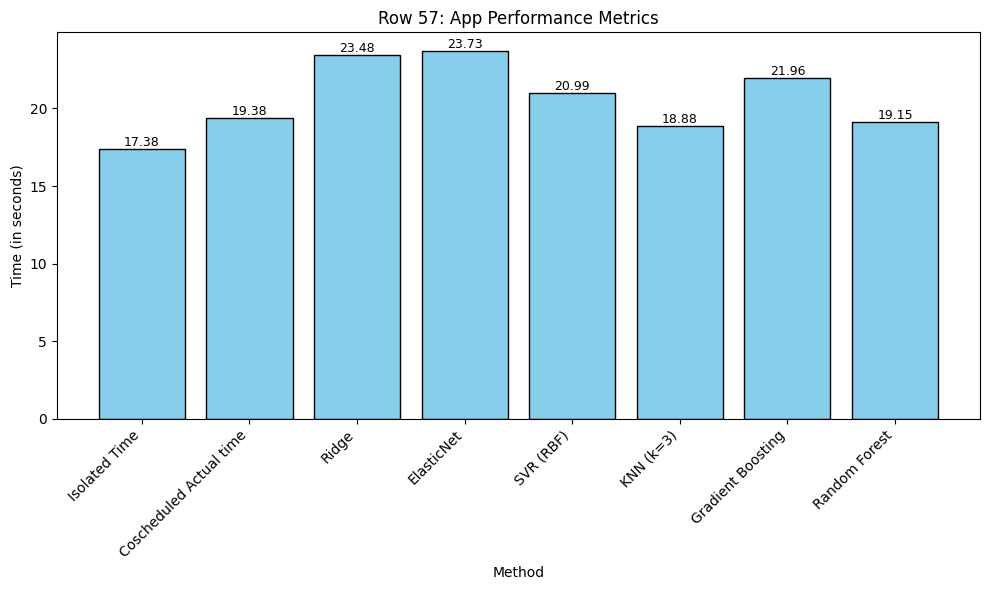

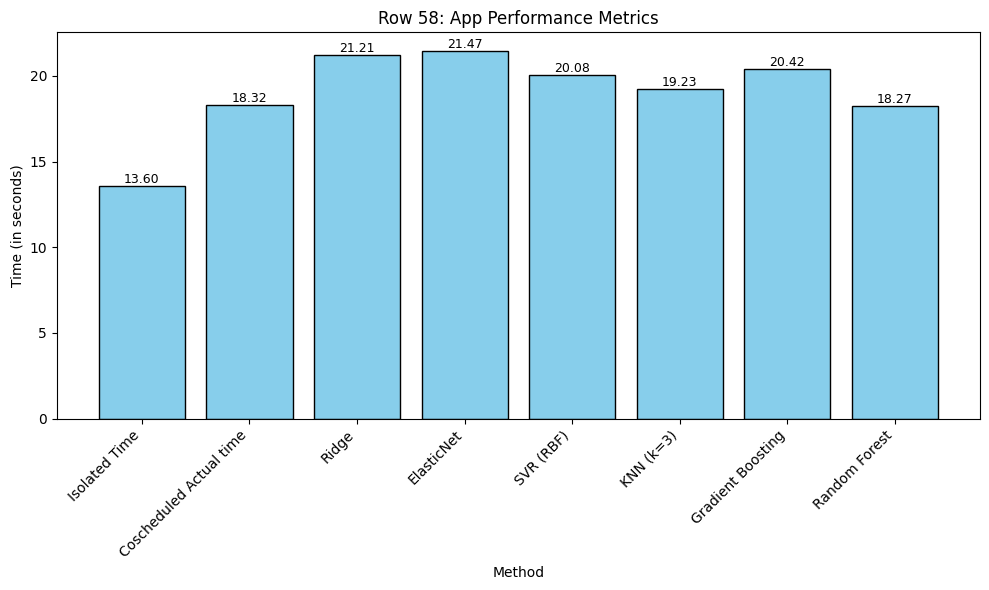

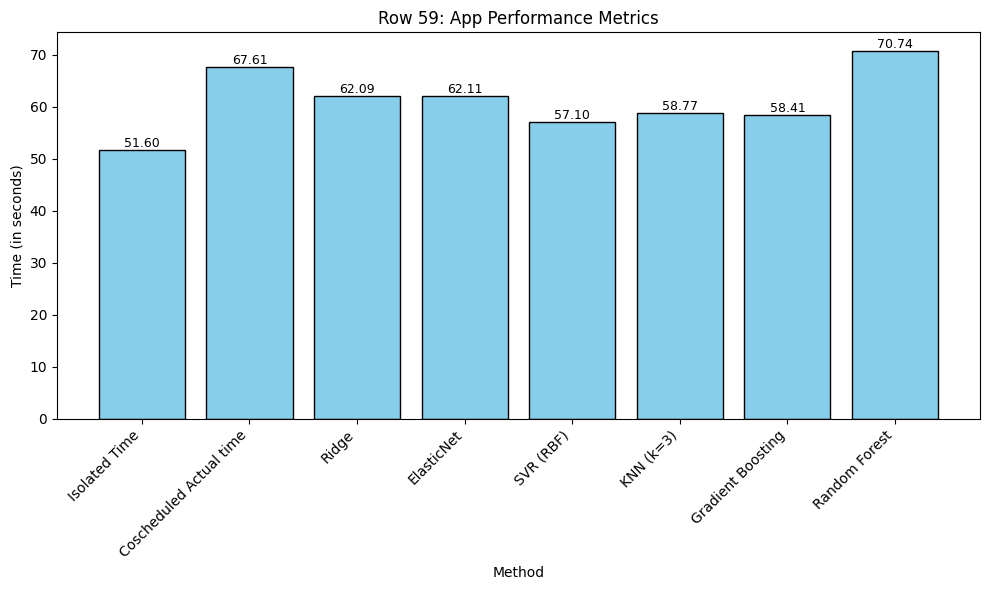

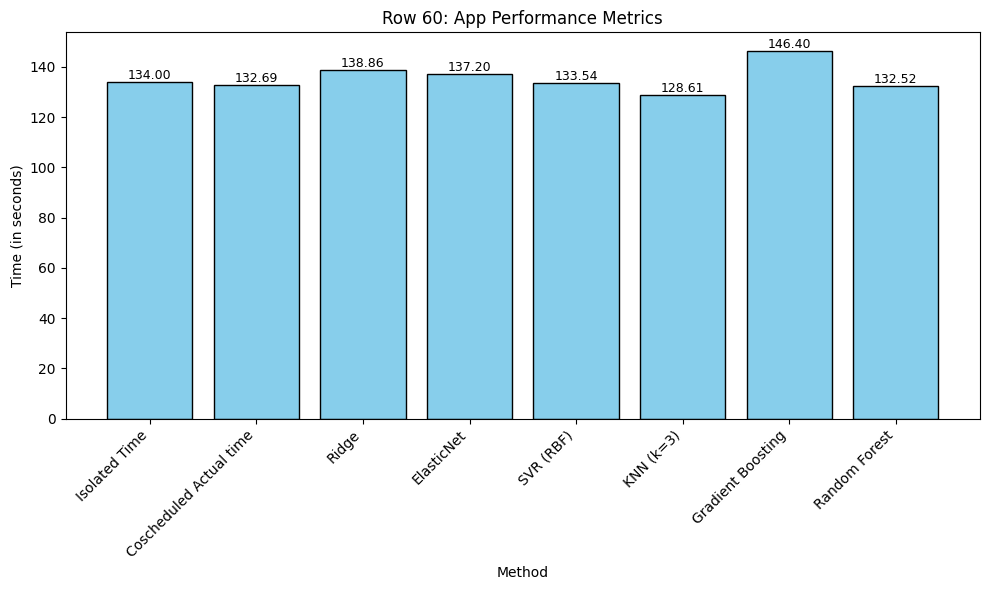

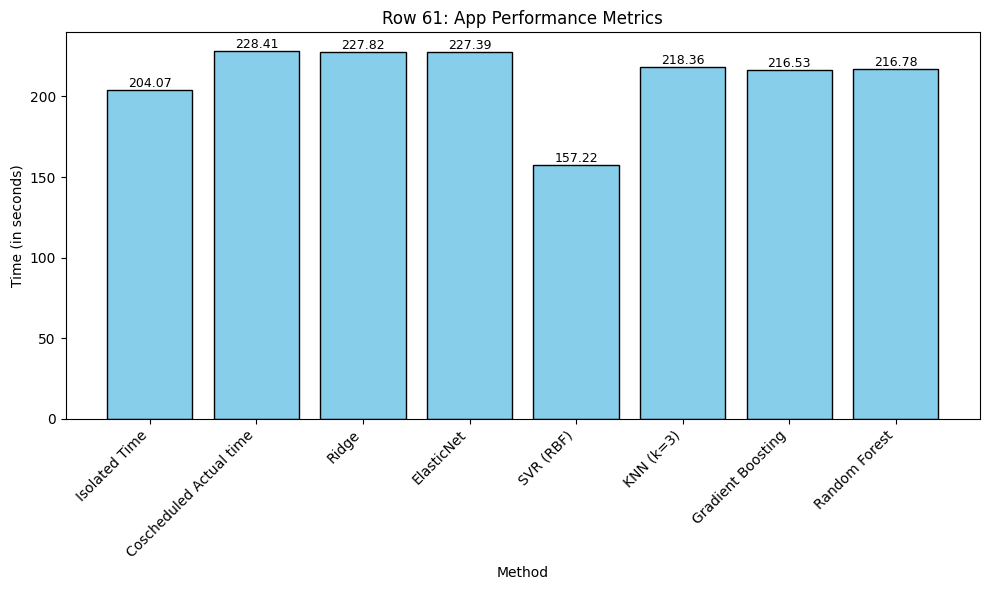

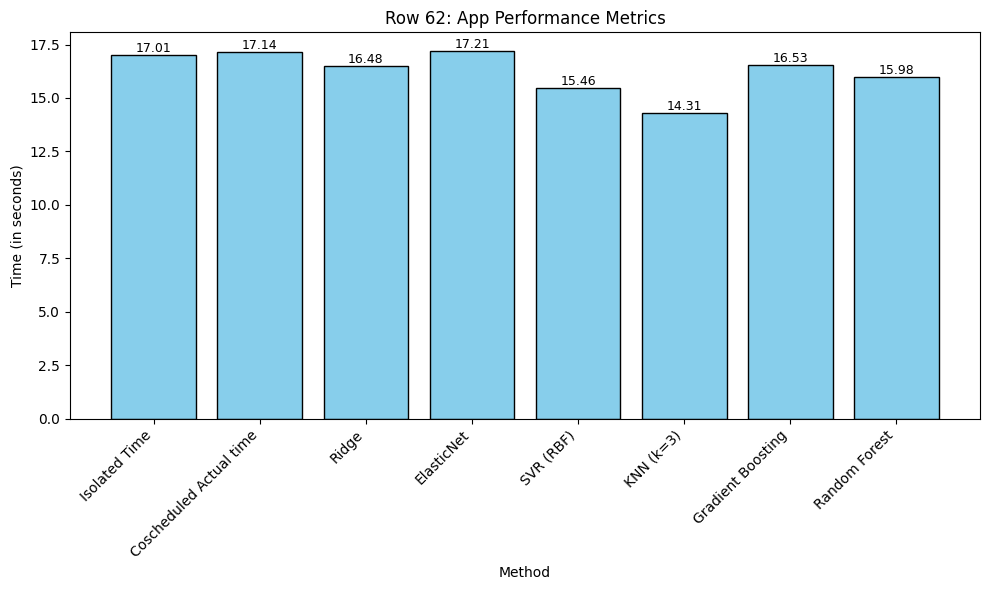

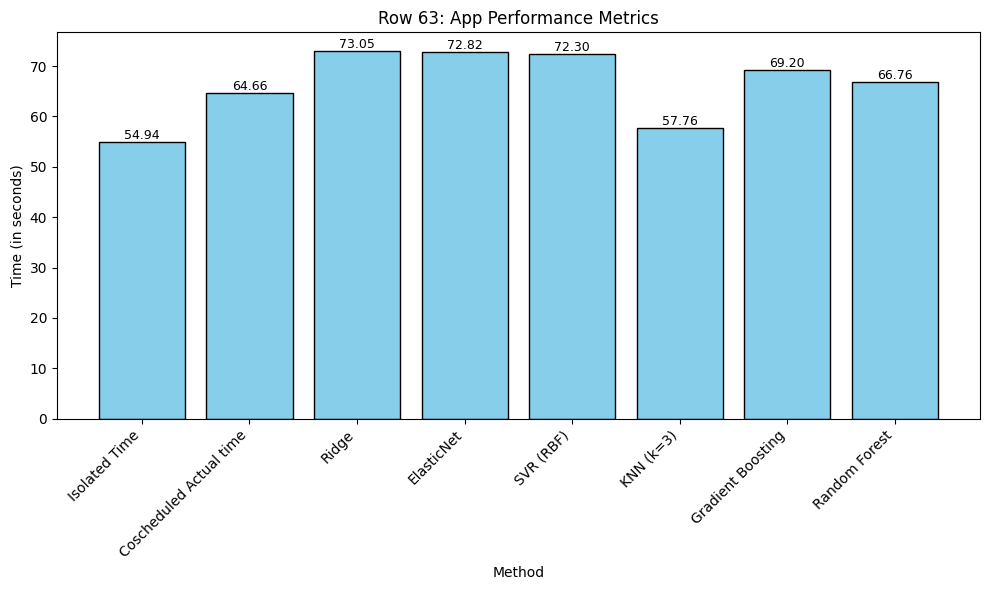

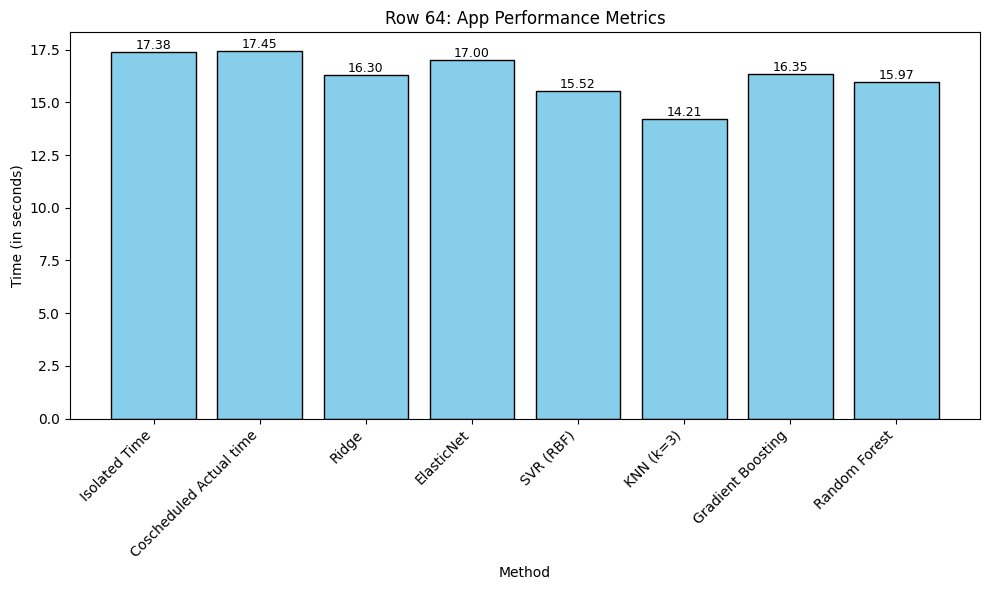

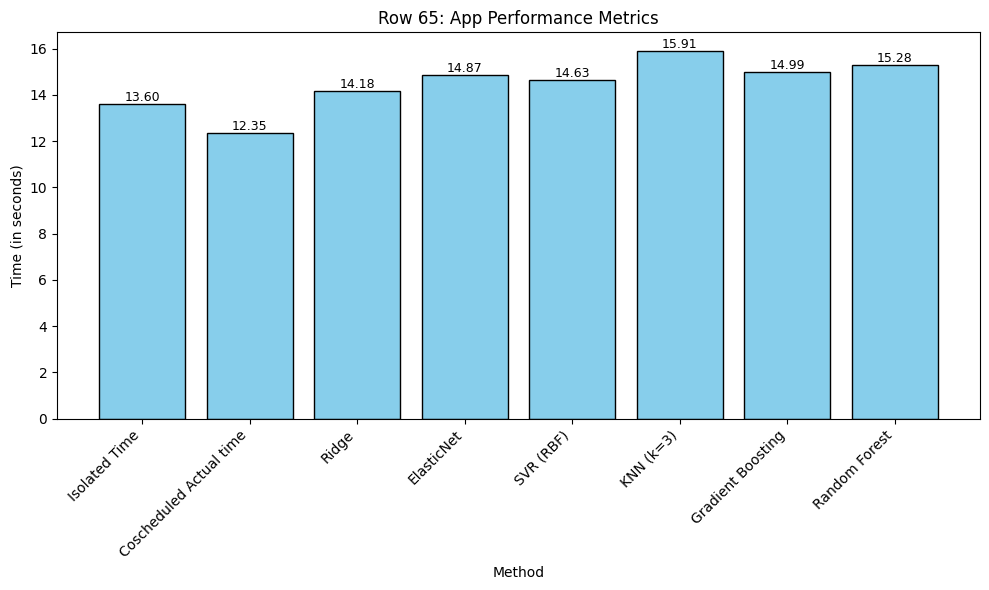

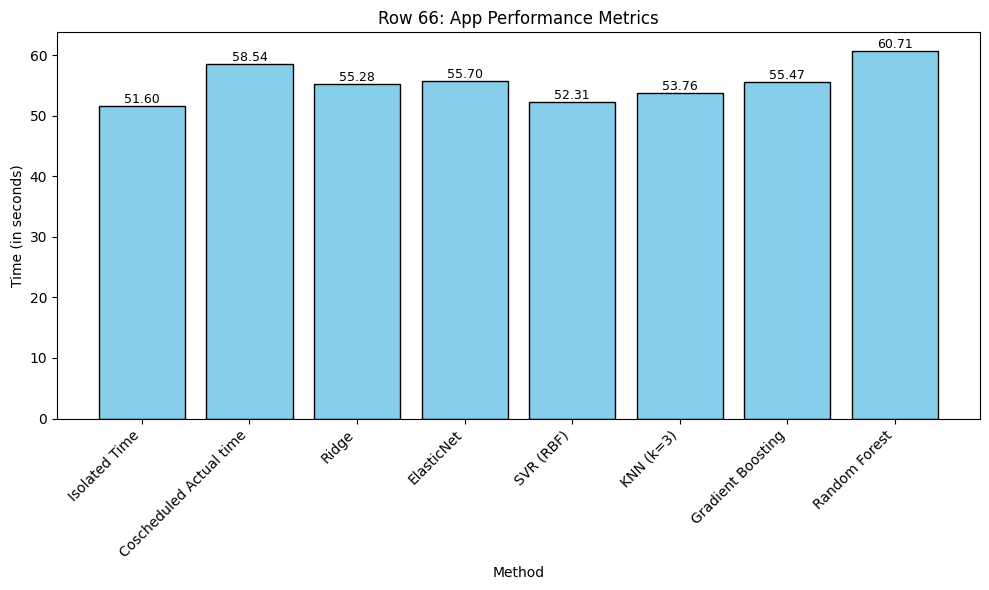

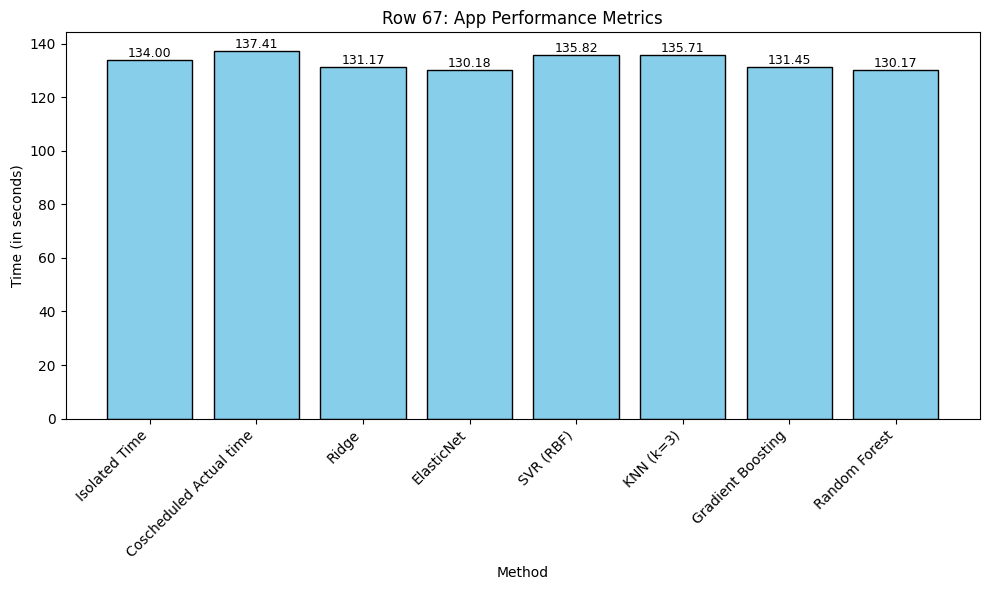

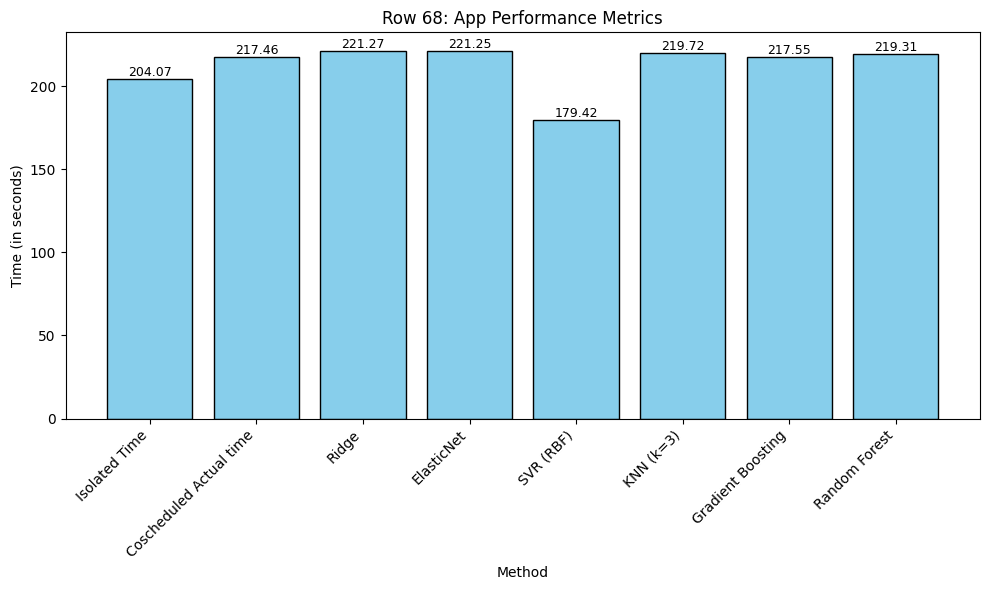

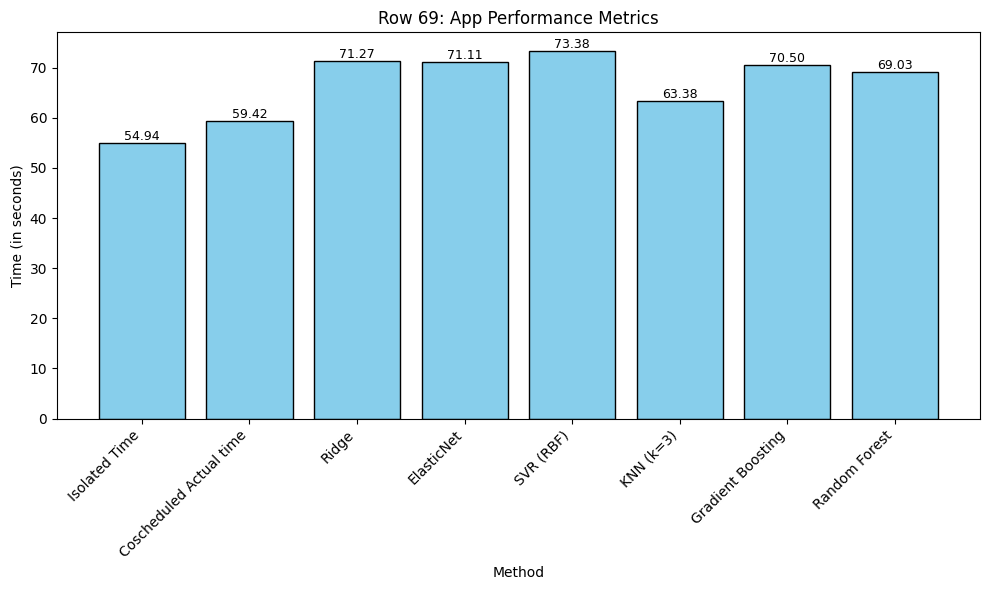

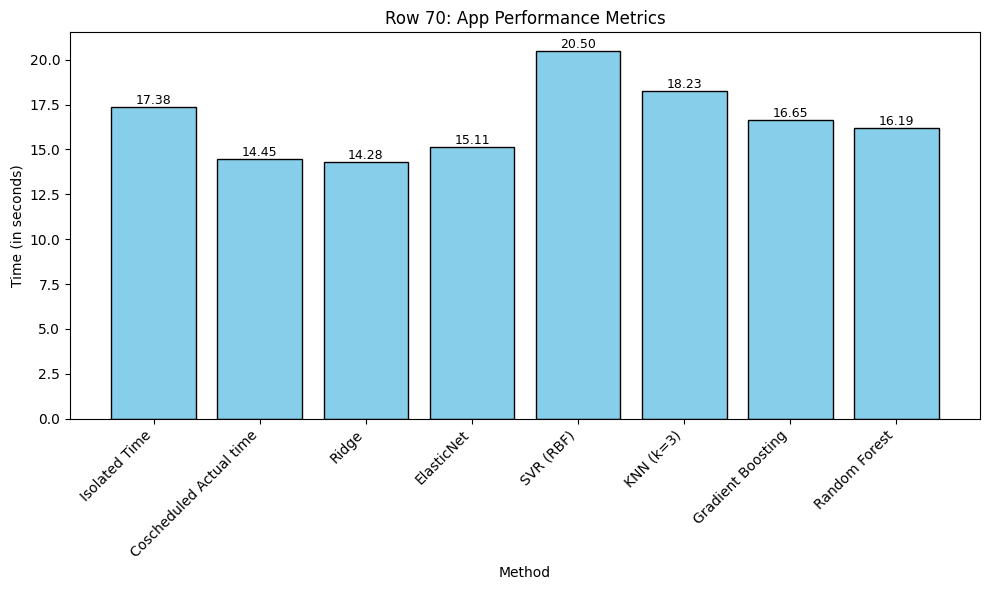

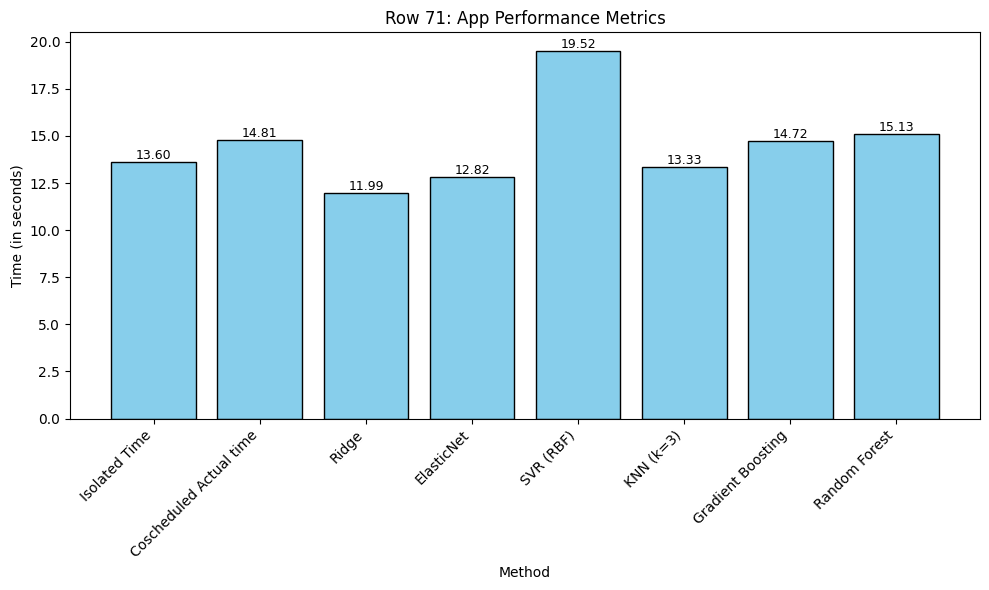

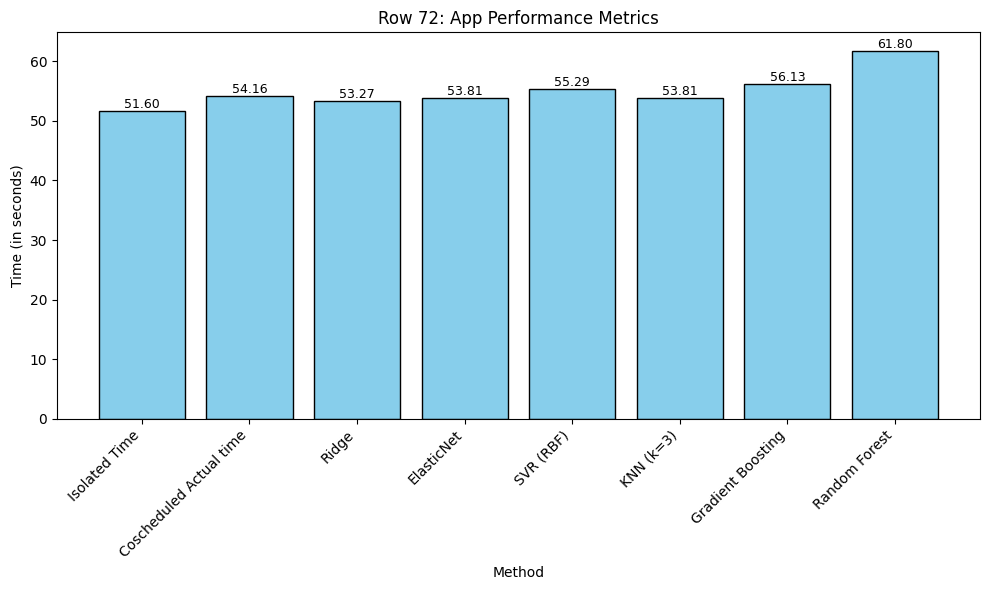

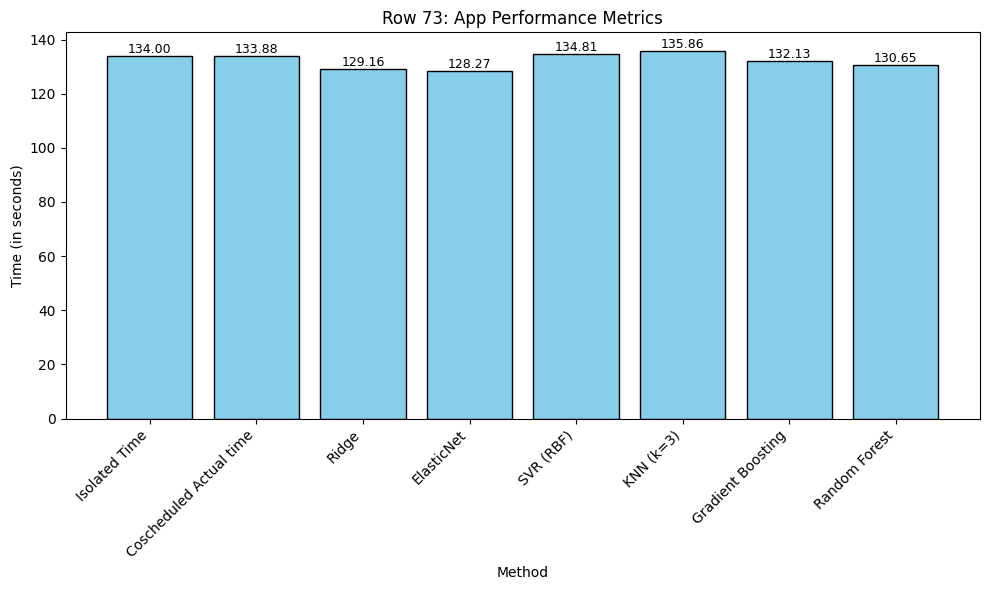

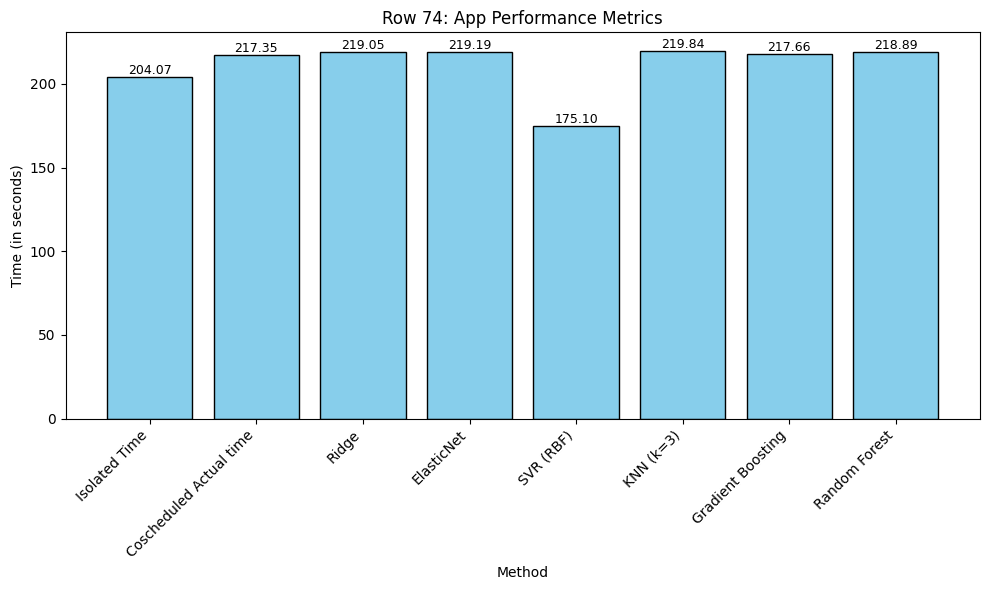

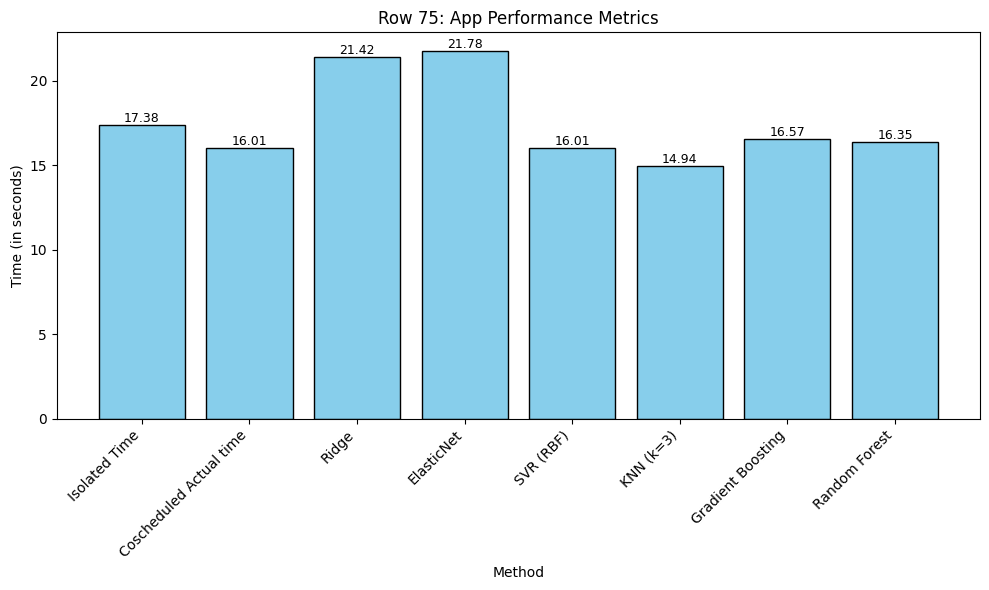

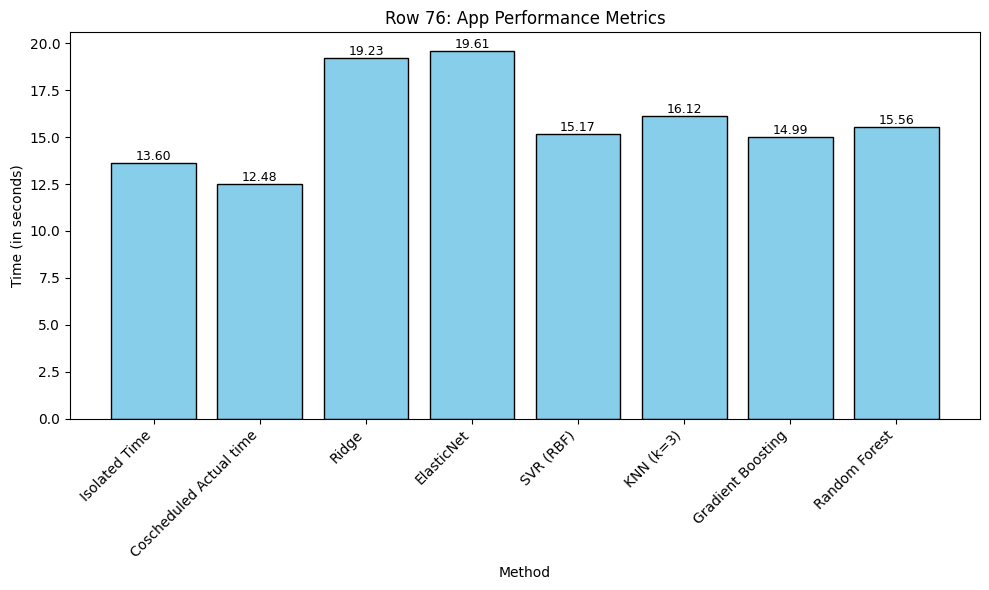

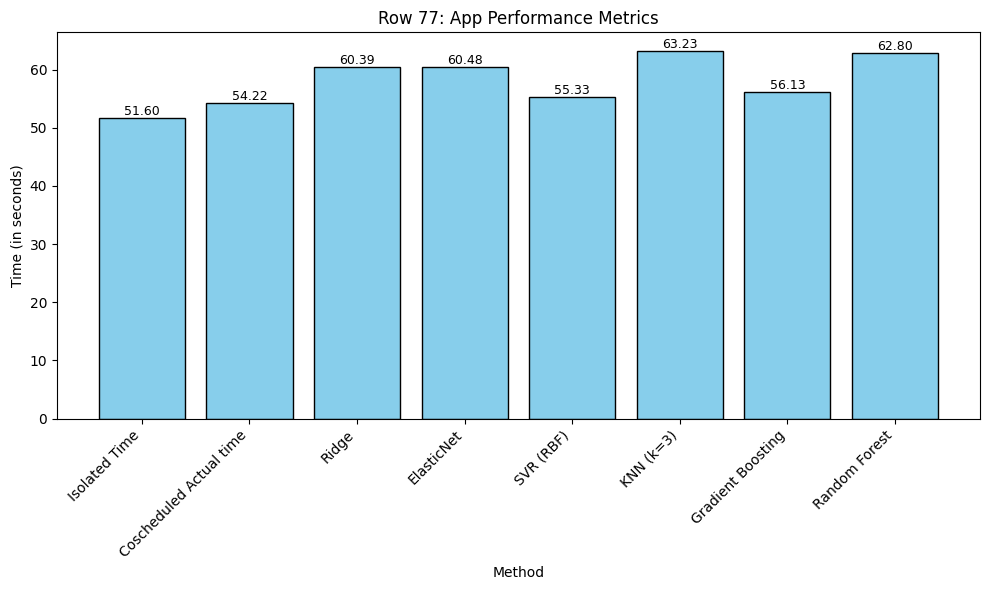

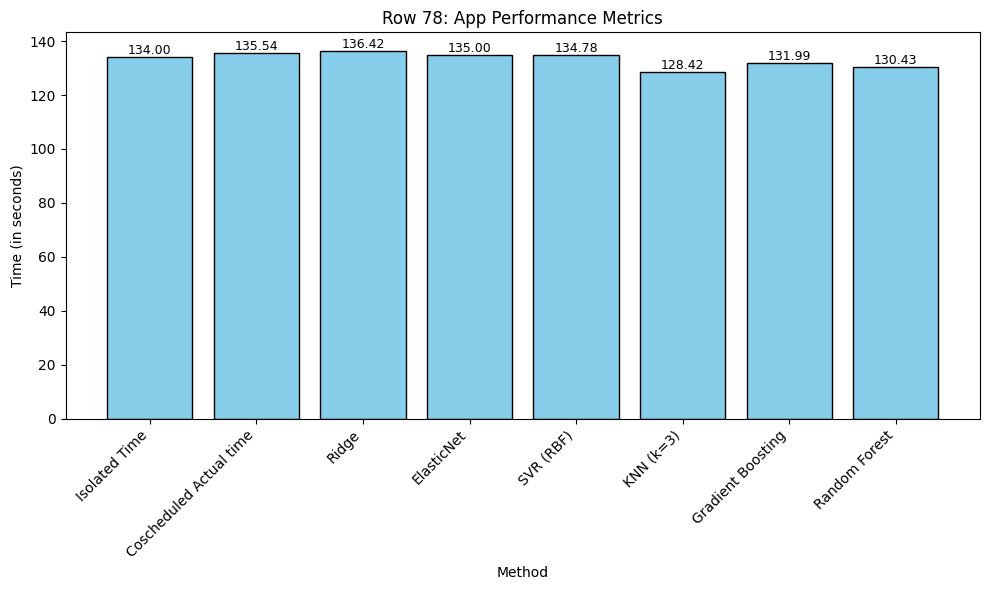

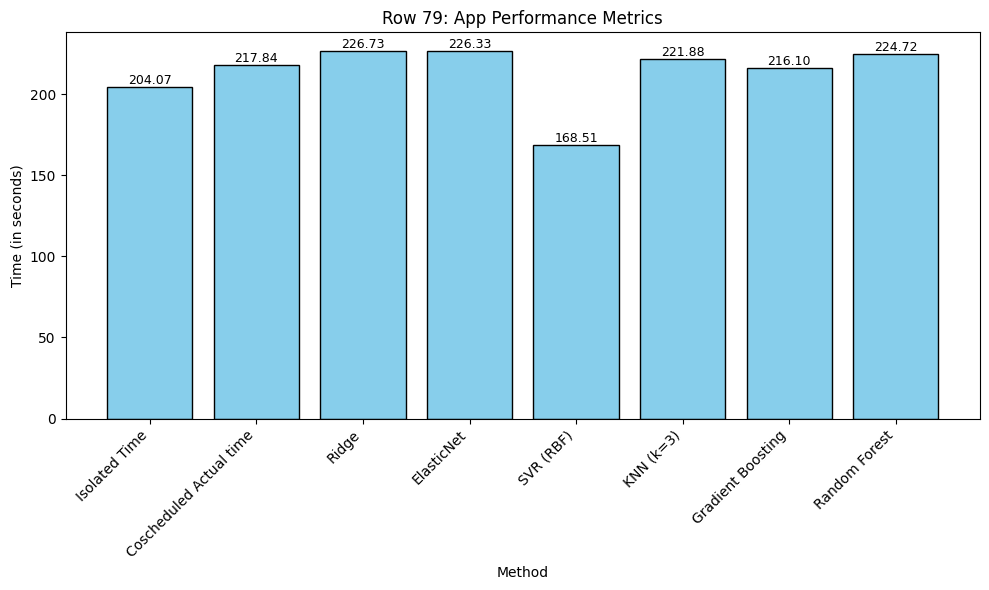

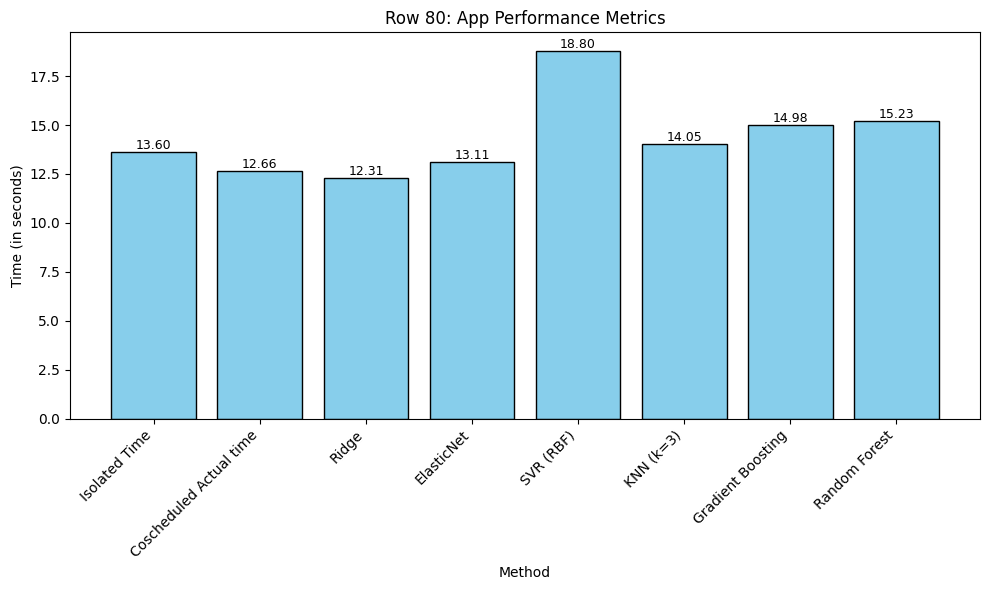

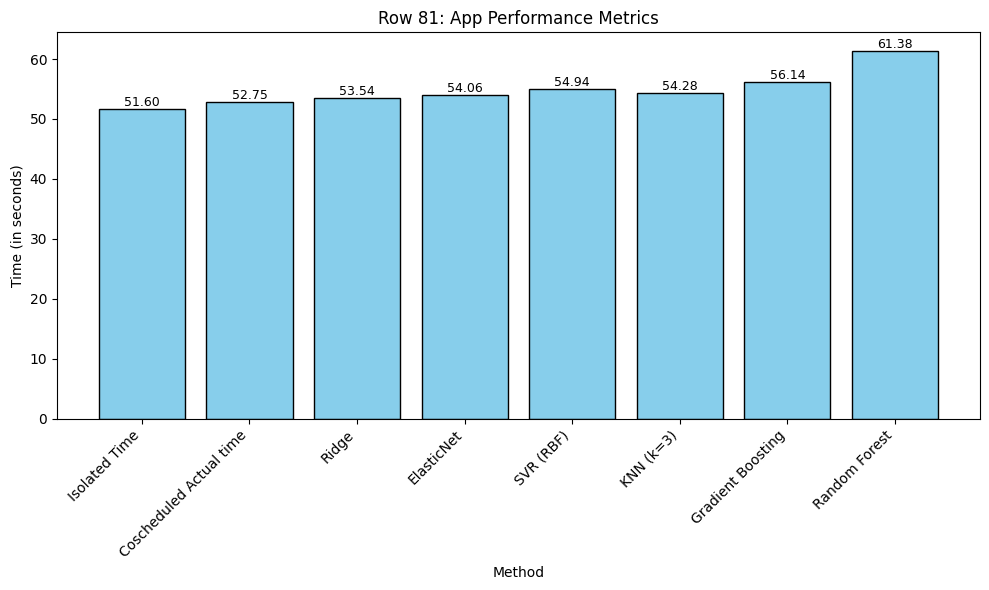

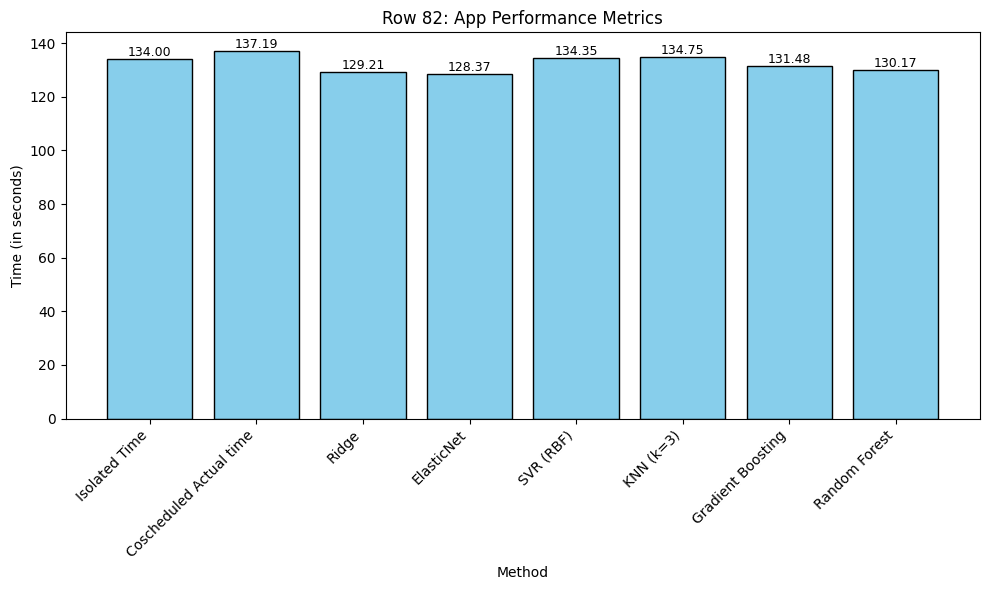

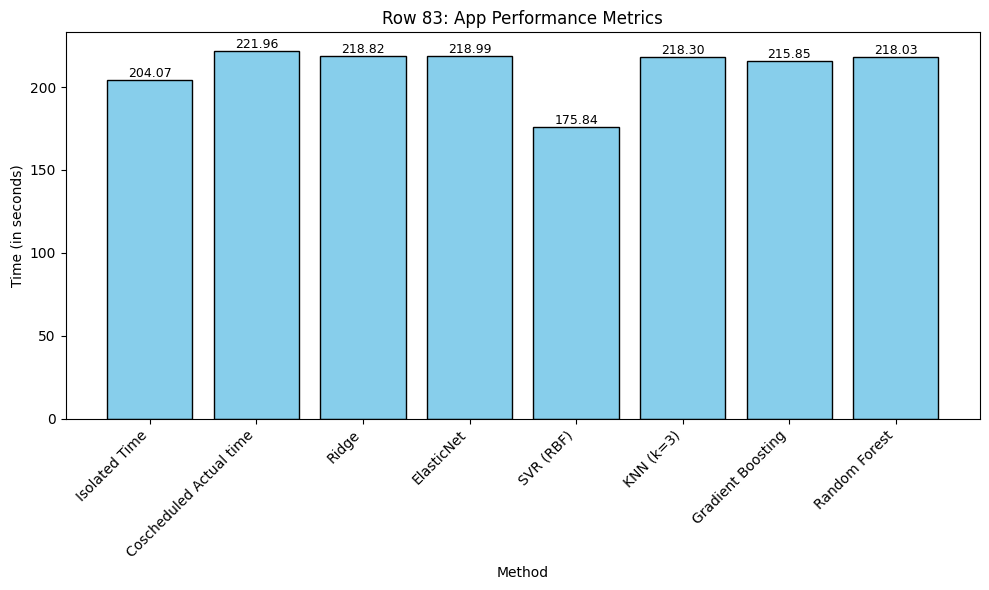

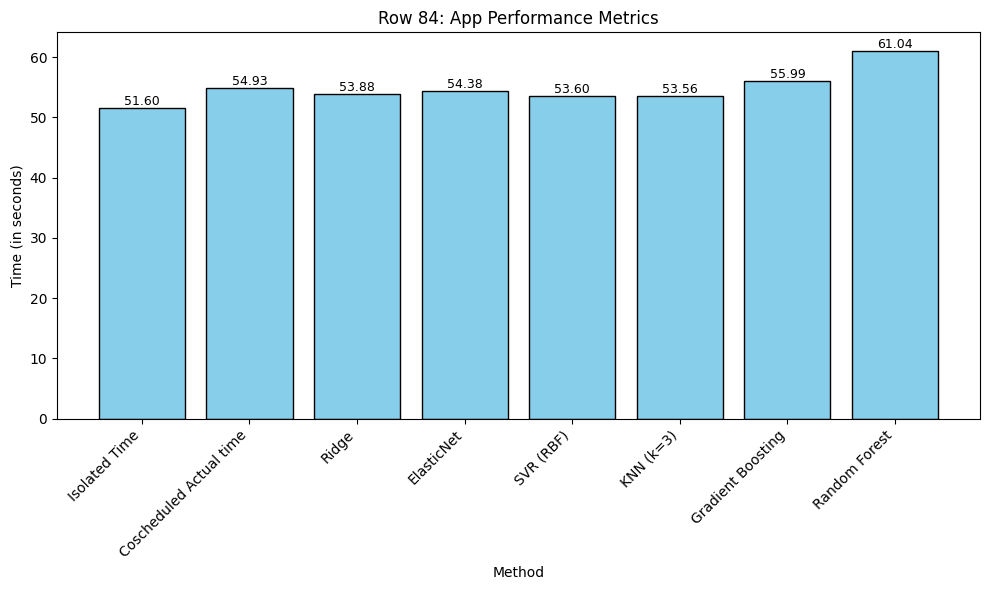

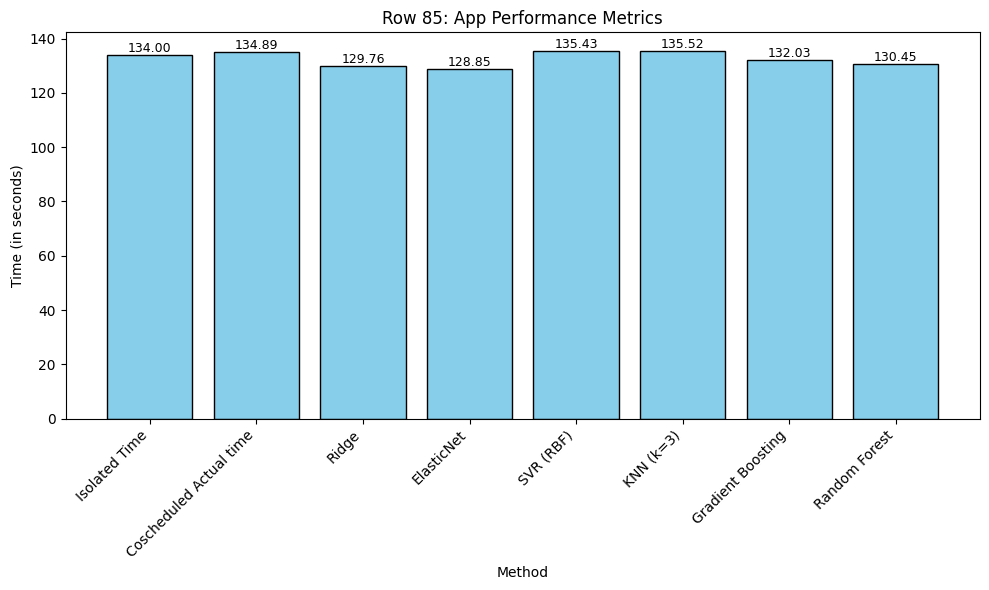

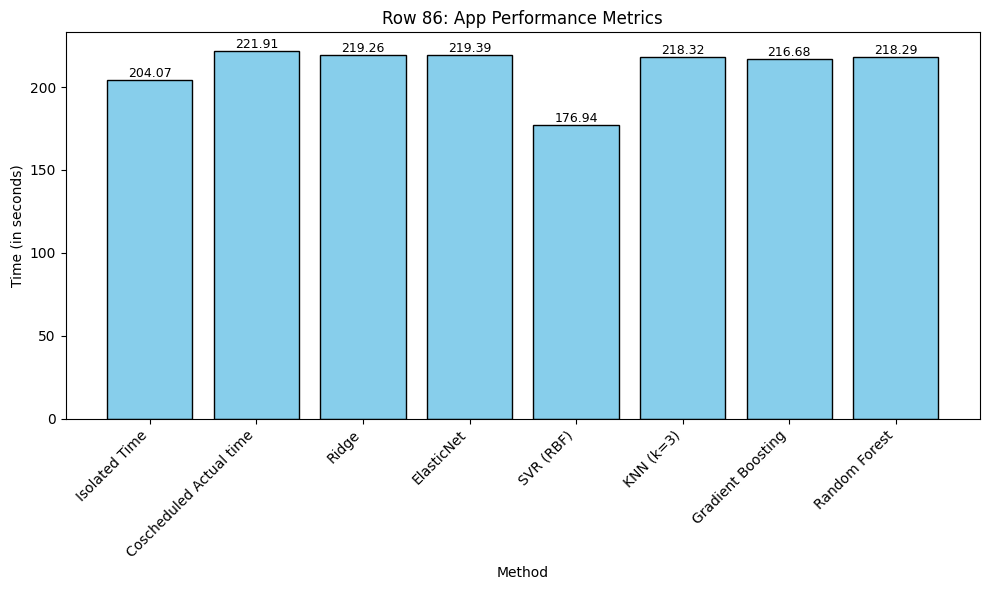

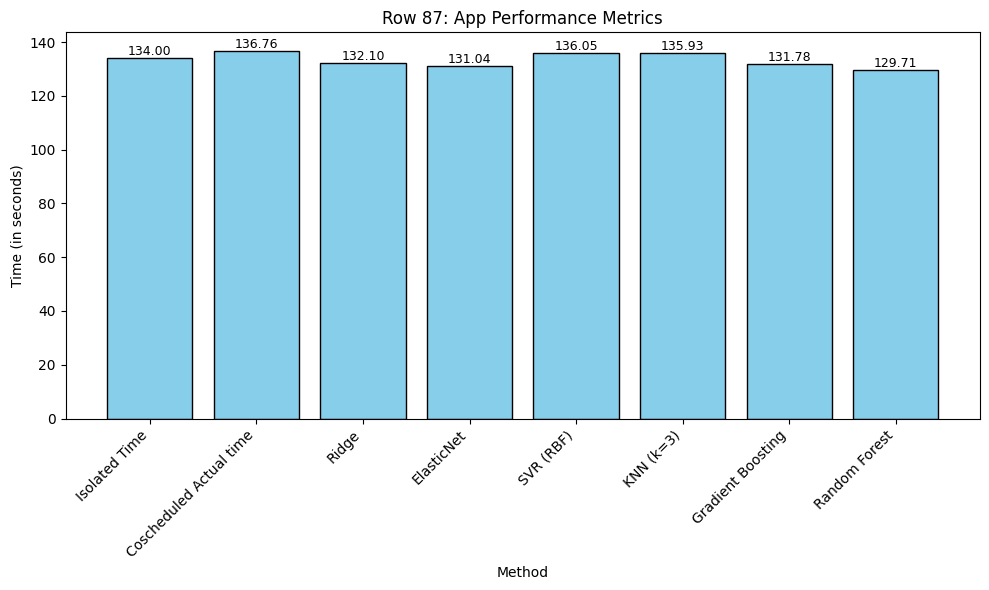

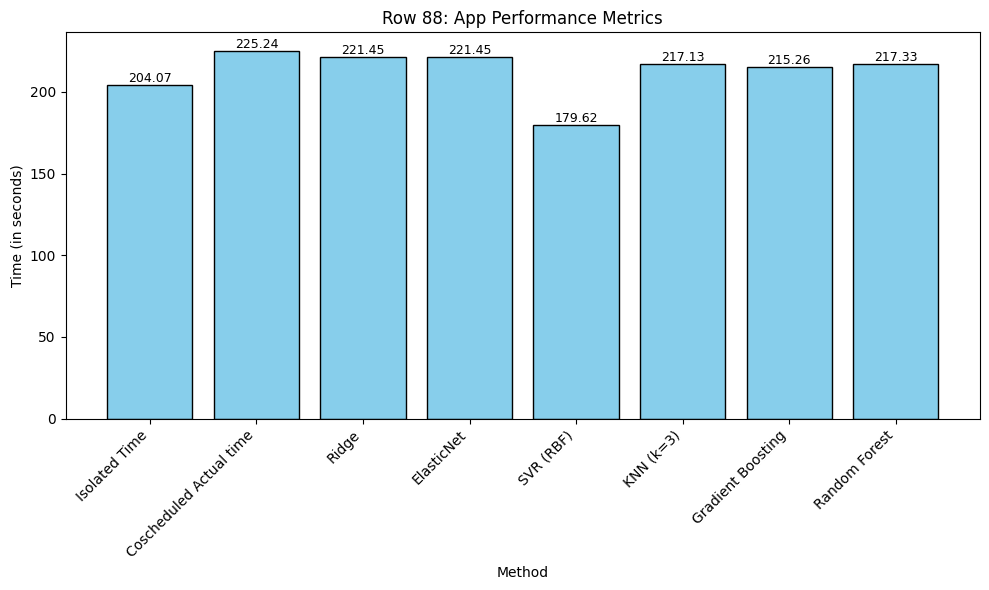

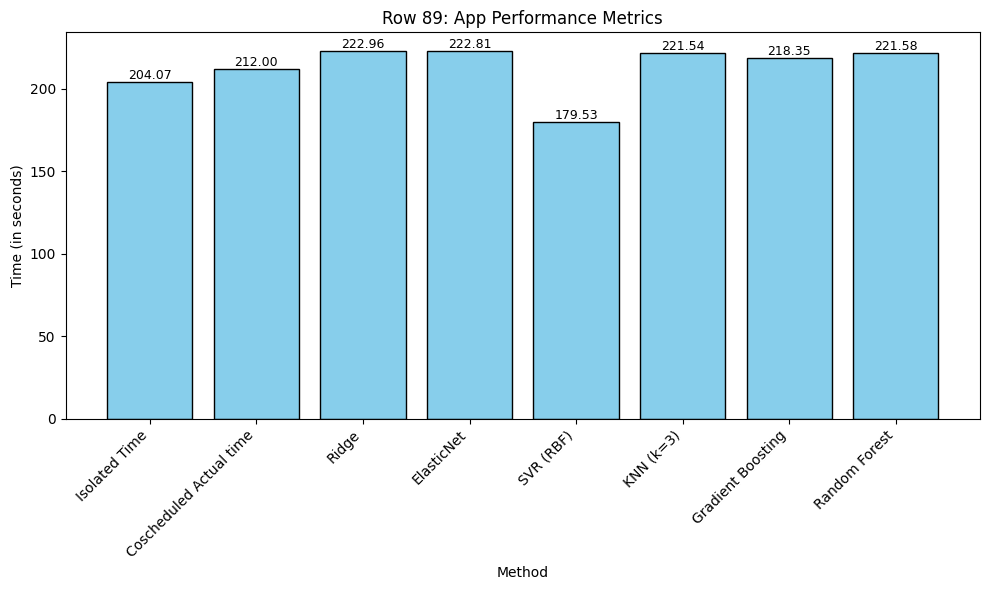

In [20]:
import os

def plot_row_metrics_separate(df, output_folder='row_plots'):
    """
    Creates a separate barplot for each row in the dataframe.
    """
    
    # 1. Identify columns to plot based on instructions
    # We explicitly define the fixed columns and filter for y_pred columns
    fixed_cols = ['App A Isolated MPI Time', 'y_true']
    
    # Filter columns that look like predictions
    pred_cols = [col for col in df.columns if 'y_pred' in col]
    
    # Combine for the plotting list
    plot_cols = fixed_cols + pred_cols
    
    # Ensure all expected columns exist in the dataframe to avoid crashes
    missing = [col for col in plot_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Columns not found in dataframe: {missing}")

    # 2. Define the mapping for labels
    # Fixed mappings
    col_labels_map = {
        'App A Isolated MPI Time': 'Isolated Time',
        'y_true': 'Coscheduled Actual time'
    }
    
    # Create the label list corresponding to plot_cols
    x_labels = []
    for col in plot_cols:
        if col in col_labels_map:
            x_labels.append(col_labels_map[col])
        elif 'y_pred' in col:
            # Split by '_' and take the last element (e.g., 'Ridge', 'KNN (k=3)')
            x_labels.append(col.split('_')[-1])
        else:
            x_labels.append(col) # Fallback

    # 3. Setup output folder
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 4. Iterate through rows
    print(f"Starting plotting {len(df)} rows...")
    for idx, row in df.iterrows():
        # Create Figure
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Extract values for the current row
        # Convert to float to ensure numeric plotting
        y_values = row[plot_cols].astype(float)
        
        # Plot Bar
        bars = ax.bar(x_labels, y_values, color='skyblue', edgecolor='black')
        
        # Set Titles and Labels
        ax.set_ylabel('Time (in seconds)')
        ax.set_xlabel('Method')
        ax.set_title(f'Row {idx}: App Performance Metrics')
        
        # Rotate x-labels slightly for readability if they are long
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Add value labels on top of bars (optional, for clarity)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=9)
        
        # Tight layout to prevent label cut-off
        plt.tight_layout()
        
        # Save plot
        # filename = os.path.join(output_folder, f'plot_row_{idx}.png')
        # fig.savefig(filename)
        # plt.close(fig) # Close figure to free memory

    print(f"Finished. Plots saved to '{output_folder}' folder.")

# --- Example Usage ---
# Assuming your dataframe is already named 'df'

# Uncomment the lines below to run this on your actual dataframe:
plot_row_metrics_separate(predictions_matrix_squared["RFE_Ridge"], output_folder='my_app_plots')


In [102]:
# Plot
def plot_model_performance(results_matrix, metric):
    fig, ax = plt.subplots(figsize=(12, 7))

    models = results_matrix[list(results_matrix.keys())[0]]["Model"].unique()
    feature_methods = list(results_matrix.keys())

    # Create data matrix
    data_matrix = []
    for method in feature_methods:
        df = results_matrix[method]
        method_maes = [df[df['Model'] == model][metric].values[0] for model in models]
        data_matrix.append(method_maes)

    # Set up bar positions
    x = np.arange(len(feature_methods))
    width = 0.13  # Width of each bar
    multiplier = 0

    # Use a colormap for better visualization
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

    # Plot grouped bars
    for idx, (model, color) in enumerate(zip(models, colors)):
        offset = width * (idx - len(models)/2 + 0.5)
        bars = ax.bar(x + offset, [row[idx] for row in data_matrix], 
                    width, label=model, color=color, edgecolor='black', 
                    linewidth=0.5, alpha=0.85)
        
        # Add value labels (optional - comment out if too cluttered)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

    # Customize
    ax.set_xlabel('Feature Selection Method', fontsize=11, fontweight='bold')
    if ("MAE" in metric):
        ax.set_ylabel(f'{metric} (Lower is Better)', fontsize=11, fontweight='bold')
    elif("R^2" in metric):
        ax.set_ylabel(f'{metric} (Higher is Better)', fontsize=11, fontweight='bold')
    else:
        ax.set_ylabel(f'{metric}', fontsize=11, fontweight='bold')
    ax.set_title(f'Model Performance by Feature Selection Method\n{metric}', 
                fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(feature_methods, rotation=30, ha='right')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

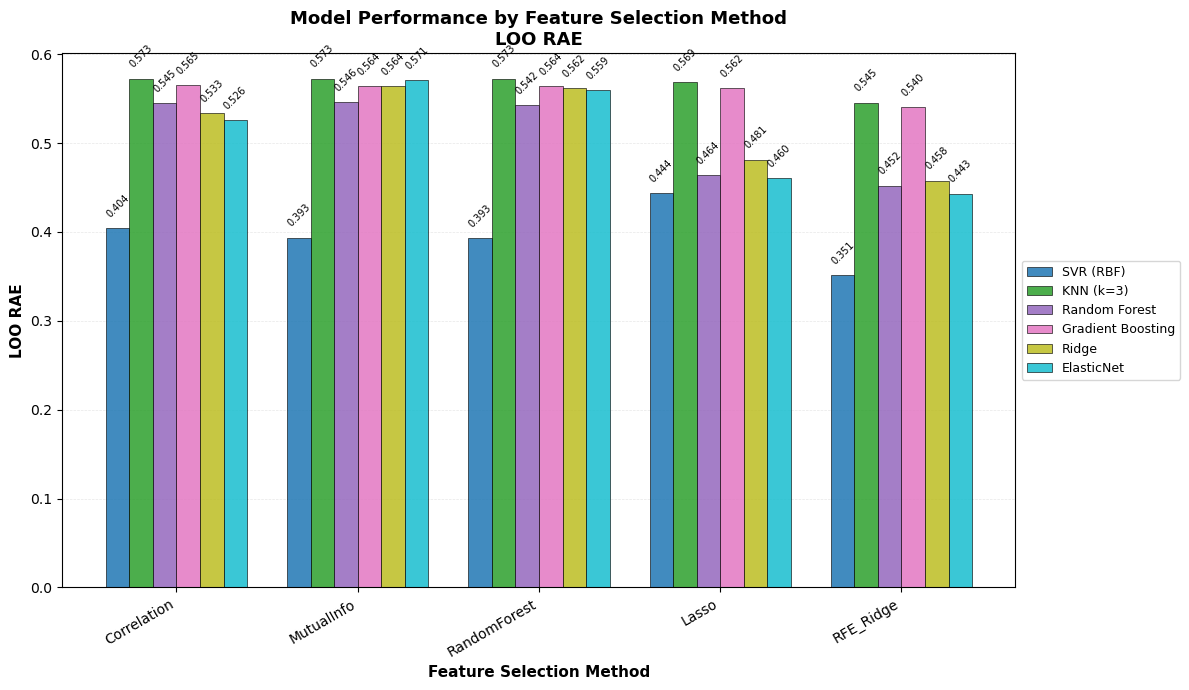

In [104]:
plot_model_performance(results_matrix_squared, "LOO RAE")

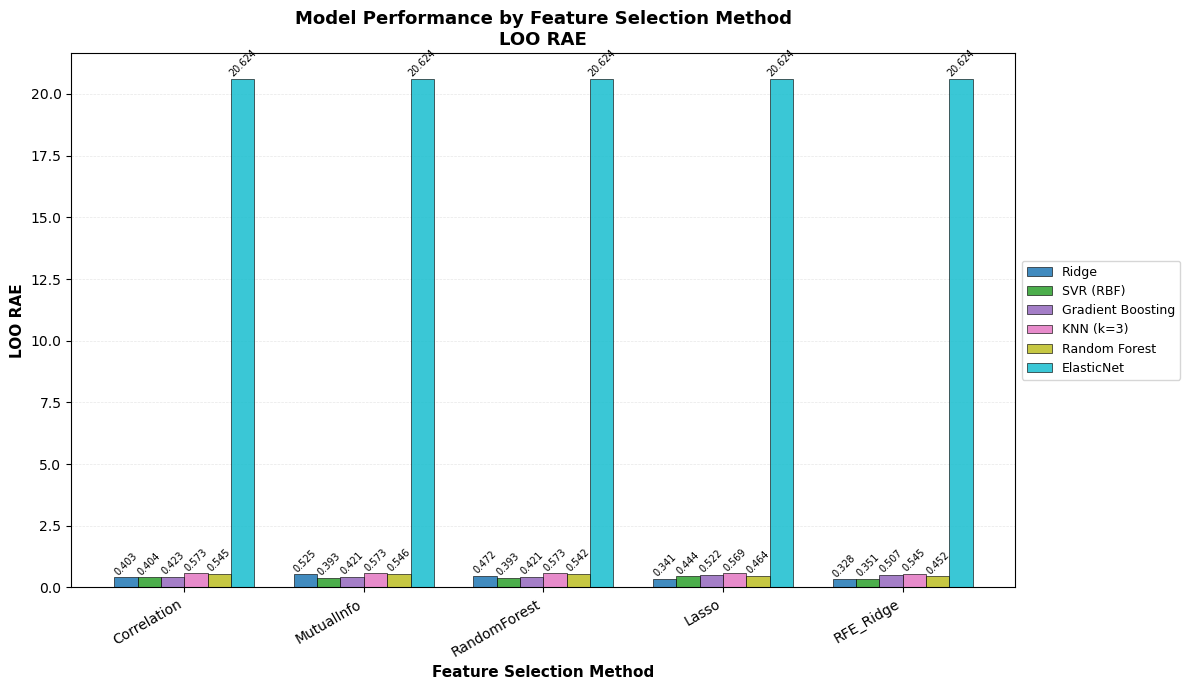

In [105]:
plot_model_performance(results_matrix_huber, "LOO RAE")

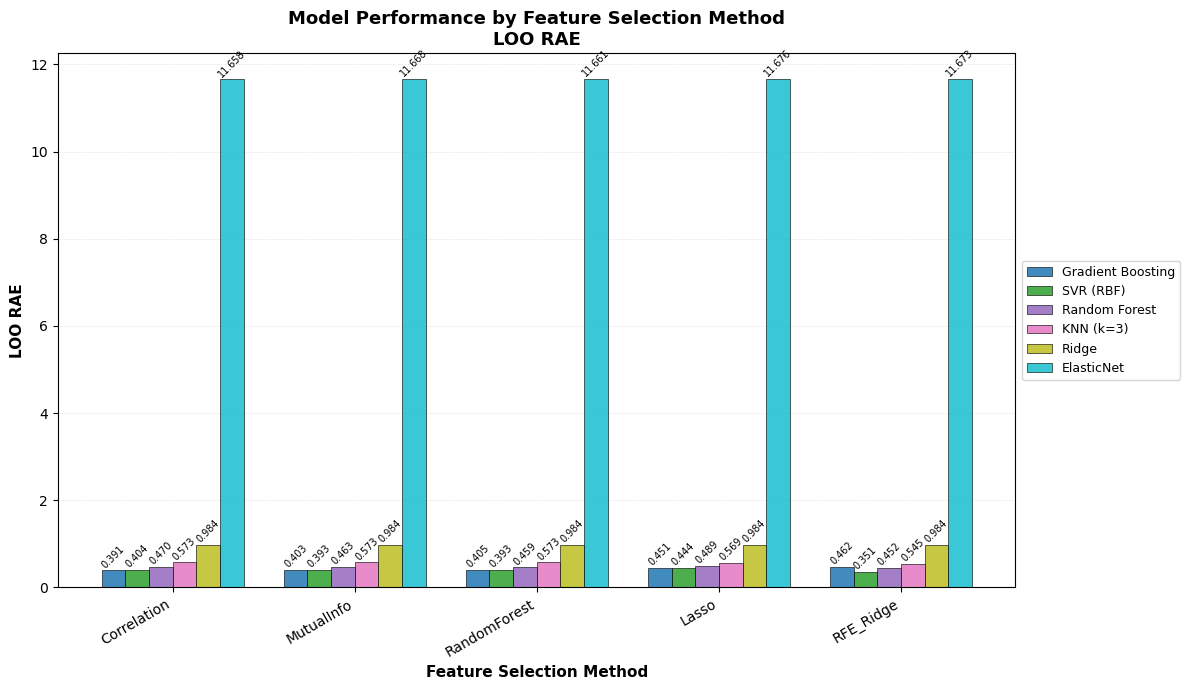

In [106]:
plot_model_performance(results_matrix_mae, "LOO RAE")

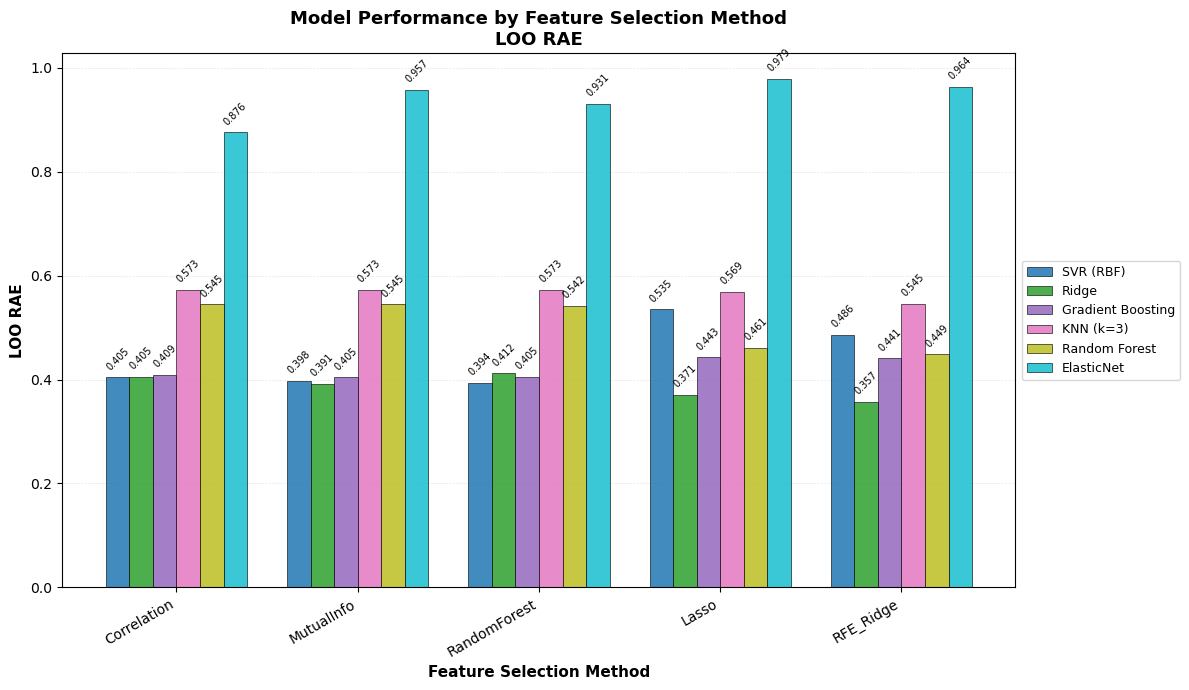

In [107]:
plot_model_performance(results_matrix_log_cosh, "LOO RAE")

In [62]:
results_matrix["Correlation"]

,Model,LOO MAE,LOO RMSE,LOO R²,KFold MAE,KFold RMSE,KFold R²
0,SVR (RBF),7.5037,16.3973,0.4882,7.6262,12.4727,0.5119
1,ElasticNet,9.7607,17.1912,0.4374,10.0484,14.3632,0.4169
2,Ridge,9.9030,17.2781,0.4318,10.1276,14.4781,0.4090
3,Random Forest,10.1209,17.9310,0.3880,10.6560,15.8258,0.2828
4,Gradient Boosting,10.4917,18.1075,0.3759,10.5929,15.8770,0.2726
5,KNN (k=3),10.6292,18.7711,0.3293,10.8121,16.2304,0.2526


In [79]:
data_time_diff = []
data_time_diff_header = ["App A", "App B", "App A Isolated Time", "App A Co-Scheduled Time with App B", "App A Time Diff"]
for i in data_df_extended.iloc:
    data_time_diff.append([i["App A"], i["App B"], i["App A Isolated Time"], i["App A Co-Scheduled Time with App B"],
                             i["App A Co-Scheduled Time with App B"] - i["App A Isolated Time"]])
data_time_diff_df = pd.DataFrame(data_time_diff)
data_time_diff_df.columns = data_time_diff_header
data_time_diff_df

,App A,App B,App A Isolated Time,App A Co-Scheduled Time with App B,App A Time Diff
0,beatnik,fiesta,397.734375,401.447545,3.713170
1,beatnik,lammps,397.734375,403.132812,5.398438
2,beatnik,minife,397.734375,407.513951,9.779576
3,beatnik,minivite,397.734375,405.080915,7.346540
4,beatnik,tricount,397.734375,446.388951,48.654576
5,fiesta,lammps,359.091518,356.097656,-2.993862
6,fiesta,minife,359.091518,356.042969,-3.048549
7,fiesta,minivite,359.091518,356.143415,-2.948103
8,fiesta,tricount,359.091518,356.861607,-2.229911
9,lammps,minife,354.750000,352.250000,-2.500000


In [18]:
def generate_filtered_combined_data(data_isolated_agg, data_coscheduled_agg, data_inhib_coscheduled_agg, app_a_allowed: set, app_b_allowed: set) -> pd.DataFrame:
    # Filter data based on Num Nodes == 8 (as per original script logic)
    data_isolated_agg = data_isolated_agg[data_isolated_agg["Num Nodes"] == 8]
    data_coscheduled_agg = data_coscheduled_agg[data_coscheduled_agg["Num Nodes"] == 8]
    data_inhib_coscheduled_agg = data_inhib_coscheduled_agg[data_inhib_coscheduled_agg["Num Nodes"] == 8]

    # --- Step 1: Get all unique (App, Num Nodes) pairs from isolated data ---
    isolated_lookup = data_isolated_agg.set_index(['App', 'Num Nodes'])['MPI Time Average Mean']

    # --- Step 2: Get all unique inhib configs (per Num Nodes) ---
    inhib_config_cols = ['Inhib Message Size', 'Inhib Wait Time (us)', 'Inhib Comm Sparsity', 'Inhib Comm Mode']
    inhib_configs = data_inhib_coscheduled_agg[['Num Nodes'] + inhib_config_cols].drop_duplicates()

    # --- Step 3: Get all unique apps per Num Nodes from coscheduled data ---
    apps_per_nodes = (
        pd.concat([
            data_coscheduled_agg[['App A', 'Num Nodes']].rename(columns={'App A': 'App'}),
            data_coscheduled_agg[['App B', 'Num Nodes']].rename(columns={'App B': 'App'}),
        ])
        .drop_duplicates()
    )

    # --- Step 4: Get unique (App A, App B, Num Nodes) combos ---
    rows = []

    for num_nodes, group in apps_per_nodes.groupby('Num Nodes'):
        apps = group['App'].unique()
        for app_a, app_b in combinations(sorted(apps), 2):
            # --- Filter Logic: Only append rows if App A and App B are in their respective allowed sets ---
            if app_a not in app_a_allowed or app_b not in app_b_allowed:
                continue

            row = {}
            row['App A'] = app_a
            row['App B'] = app_b
            row['Num Nodes'] = num_nodes

            # --- Isolated times ---
            row['App A Isolated MPI Time'] = isolated_lookup.get((app_a, num_nodes), None)
            row['App B Isolated MPI Time'] = isolated_lookup.get((app_b, num_nodes), None)

            # --- Inhib co-scheduled times for App A and App B ---
            node_inhib_configs = inhib_configs[inhib_configs['Num Nodes'] == num_nodes]

            for _, cfg in node_inhib_configs.iterrows():
                cfg_filter = (
                    (data_inhib_coscheduled_agg['Num Nodes'] == num_nodes) &
                    (data_inhib_coscheduled_agg['Inhib Message Size'] == cfg['Inhib Message Size']) &
                    (data_inhib_coscheduled_agg['Inhib Wait Time (us)'] == cfg['Inhib Wait Time (us)']) &
                    (data_inhib_coscheduled_agg['Inhib Comm Sparsity'] == cfg['Inhib Comm Sparsity']) &
                    (data_inhib_coscheduled_agg['Inhib Comm Mode'] == cfg['Inhib Comm Mode'])
                )

                cfg_label = (
                    f"MsgSz={cfg['Inhib Message Size']}_"
                    f"Wait={cfg['Inhib Wait Time (us)']}us_"
                    f"Sparsity={cfg['Inhib Comm Sparsity']}_"
                    f"Mode={cfg['Inhib Comm Mode']}"
                )

                for app, col_prefix in [(app_a, 'App A'), (app_b, 'App B')]:
                    app_filter = cfg_filter & (data_inhib_coscheduled_agg['App'] == app)
                    match = data_inhib_coscheduled_agg[app_filter]
                    col_name = f"{col_prefix} Co-Scheduled MPI Time with Inhib [{cfg_label}]"
                    row[col_name] = match['MPI Time Average Mean'].values[0] if len(match) > 0 else None

            # --- Co-scheduled time with each other (from data_coscheduled_agg) ---
            cosched_filter = (
                (data_coscheduled_agg['Num Nodes'] == num_nodes) &
                (data_coscheduled_agg['App A'] == app_a) &
                (data_coscheduled_agg['App B'] == app_b)
            )
            cosched_match = data_coscheduled_agg[cosched_filter]

            # Also check reversed order
            cosched_filter_rev = (
                (data_coscheduled_agg['Num Nodes'] == num_nodes) &
                (data_coscheduled_agg['App A'] == app_b) &
                (data_coscheduled_agg['App B'] == app_a)
            )
            cosched_match_rev = data_coscheduled_agg[cosched_filter_rev]

            if len(cosched_match) > 0:
                row['App A Co-Scheduled MPI Time with App B'] = cosched_match['App A MPI Time Average Mean'].values[0]
                row['App B Co-Scheduled MPI Time with App A'] = cosched_match['App B MPI Time Average Mean'].values[0]
            elif len(cosched_match_rev) > 0:
                # A and B are swapped in the source df, so flip the columns
                row['App A Co-Scheduled MPI Time with App B'] = cosched_match_rev['App B MPI Time Average Mean'].values[0]
                row['App B Co-Scheduled MPI Time with App A'] = cosched_match_rev['App A MPI Time Average Mean'].values[0]
            else:
                row['App A Co-Scheduled MPI Time with App B'] = None
                row['App B Co-Scheduled MPI Time with App A'] = None

            rows.append(row)

    data_combined_training_df = pd.DataFrame(rows)
    return data_combined_training_df

def double_combined_dataset(data_df):

    # Double the dataset size by splitting App A and App B targets into two rows
    # Identify column categories
    app_a_isolated = 'App A Isolated MPI Time'
    app_b_isolated = 'App B Isolated MPI Time'

    inhib_a_cols = [c for c in data_df.columns if c.startswith('App A Co-Scheduled MPI Time with Inhib')]
    inhib_b_cols = [c for c in data_df.columns if c.startswith('App B Co-Scheduled MPI Time with Inhib')]

    cosched_a_col = 'App A Co-Scheduled MPI Time with App B'
    cosched_b_col = 'App B Co-Scheduled MPI Time with App A'

    # --- Row type 1: original row, drop "App B Co-Scheduled Time with App A" ---
    data_df_type1 = data_df.drop(columns=[cosched_b_col]).copy()

    # --- Row type 2: swap App A <-> App B, keep only "App A Co-Scheduled Time with App B" (post-swap) ---
    data_df_type2 = data_df.copy()

    # Swap App A / App B names
    data_df_type2['App A'] = data_df['App B']
    data_df_type2['App B'] = data_df['App A']

    # Swap isolated times
    data_df_type2[app_a_isolated] = data_df[app_b_isolated]
    data_df_type2[app_b_isolated] = data_df[app_a_isolated]

    # Swap inhibitor columns pairwise
    # inhib_a_cols[i] pairs with inhib_b_cols[i] (same param suffix)
    for col_a, col_b in zip(inhib_a_cols, inhib_b_cols):
        data_df_type2[col_a] = data_df[col_b]
        data_df_type2[col_b] = data_df[col_a]

    # After swap, "App A Co-Scheduled Time with App B" should hold what was cosched_b_col
    data_df_type2[cosched_a_col] = data_df[cosched_b_col]

    # Drop the cosched_b column (only keep cosched_a)
    data_df_type2 = data_df_type2.drop(columns=[cosched_b_col])

    # --- Combine ---
    data_df_extended = pd.concat([data_df_type1, data_df_type2], ignore_index=True)
    data_df_extended
    return data_df_extended

In [ ]:
# Training and testing split of data

data_isolated_agg = pd.read_csv("../processed_data/data_isolated_agg.csv", index_col=0)
data_isolated_agg = data_isolated_agg[data_isolated_agg["Num Nodes"] == 8]
data_coscheduled_agg = pd.read_csv("../processed_data/data_coscheduled_agg.csv", index_col=0)
data_coscheduled_agg = data_coscheduled_agg[data_coscheduled_agg["Num Nodes"] == 8]
data_inhib_coscheduled_agg = pd.read_csv("../processed_data/data_inhib_coscheduled_agg.csv", index_col=0)
data_inhib_coscheduled_agg = data_inhib_coscheduled_agg[data_inhib_coscheduled_agg["Num Nodes"] == 8]

# Generate training dataframe
app_a_allowed = {"beatnik", "lammps", "minife", "fiesta", "minivite", "quicksilver", "minivite"}
app_b_allowed = {"beatnik", "lammps", "minife", "fiesta", "minivite", "quicksilver", "minivite"}
# app_a_allowed = set(data_isolated_agg["App"].unique())
# app_b_allowed = set(data_isolated_agg["App"].unique())
data_training_df = generate_filtered_combined_data(data_isolated_agg, data_coscheduled_agg, data_inhib_coscheduled_agg, app_a_allowed, app_b_allowed)
data_training_df = double_combined_dataset(data_training_df)

app_a_allowed = {"laghos", "kripke", "amg"}
# app_a_allowed = set(data_isolated_agg["App"].unique())
app_b_allowed = set(data_isolated_agg["App"].unique())
data_testing_df = generate_filtered_combined_data(data_isolated_agg, data_coscheduled_agg, data_inhib_coscheduled_agg, app_a_allowed, app_b_allowed)
data_testing_df = double_combined_dataset(data_testing_df)

In [ ]:
# Feature selection and training
fs = FeatureSelection()
all_selections = fs.get_feature_matrix(data_training_df, k=4)
consensus_df = fs.get_consensus()
app_time_lookup = data_isolated_agg.set_index('App')['MPI Time Average Mean']

results_matrix_squared = {}
predictions_matrix_squared_training = {}
predictions_matrix_squared_testing = {}
reg_squared = {}
for i in all_selections.keys():
    reg_squared[i] = Regression(loss_type="squared")
    reg_squared[i].train(data_training_df, all_selections[i], loss_type="squared")
    predictions_matrix_squared_training[i] = reg_squared[i].predict(data_training_df, all_selections[i])
    predictions_matrix_squared_testing[i] = reg_squared[i].predict(data_testing_df, all_selections[i])
    predictions_matrix_squared_training[i]['App A Isolated MPI Time'] = predictions_matrix_squared_training[i]['App A'].map(app_time_lookup)
    predictions_matrix_squared_training[i]['App B Isolated MPI Time'] = predictions_matrix_squared_training[i]['App B'].map(app_time_lookup)
    predictions_matrix_squared_testing[i]['App A Isolated MPI Time'] = predictions_matrix_squared_testing[i]['App A'].map(app_time_lookup)
    predictions_matrix_squared_testing[i]['App B Isolated MPI Time'] = predictions_matrix_squared_testing[i]['App B'].map(app_time_lookup)
    
""" results_matrix_huber = {}
predictions_matrix_huber_training = {}
predictions_matrix_huber_testing = {}
reg_huber = {}
for i in all_selections.keys():
    reg_huber[i] = Regression(loss_type="huber")
    reg_huber[i].train(data_training_df, all_selections[i], loss_type="huber")
    predictions_matrix_huber_training[i] = reg_huber[i].predict(data_training_df, all_selections[i])
    predictions_matrix_huber_testing[i] = reg_huber[i].predict(data_testing_df, all_selections[i])
    predictions_matrix_huber_training[i]['App A Isolated MPI Time'] = predictions_matrix_huber_training[i]['App A'].map(app_time_lookup)
    predictions_matrix_huber_training[i]['App B Isolated MPI Time'] = predictions_matrix_huber_training[i]['App B'].map(app_time_lookup)
    predictions_matrix_huber_testing[i]['App A Isolated MPI Time'] = predictions_matrix_huber_testing[i]['App A'].map(app_time_lookup)
    predictions_matrix_huber_testing[i]['App B Isolated MPI Time'] = predictions_matrix_huber_testing[i]['App B'].map(app_time_lookup)

results_matrix_mae = {}
predictions_matrix_mae_training = {}
predictions_matrix_mae_testing = {}
reg_mae = {}
for i in all_selections.keys():
    reg_mae[i] = Regression(loss_type="mae")
    reg_mae[i].train(data_training_df, all_selections[i], loss_type="mae")
    predictions_matrix_mae_training[i] = reg_mae[i].predict(data_training_df, all_selections[i])
    predictions_matrix_mae_testing[i] = reg_mae[i].predict(data_testing_df, all_selections[i])
    predictions_matrix_mae_training[i]['App A Isolated MPI Time'] = predictions_matrix_mae_training[i]['App A'].map(app_time_lookup)
    predictions_matrix_mae_training[i]['App B Isolated MPI Time'] = predictions_matrix_mae_training[i]['App B'].map(app_time_lookup)
    predictions_matrix_mae_testing[i]['App A Isolated MPI Time'] = predictions_matrix_mae_testing[i]['App A'].map(app_time_lookup)
    predictions_matrix_mae_testing[i]['App B Isolated MPI Time'] = predictions_matrix_mae_testing[i]['App B'].map(app_time_lookup)

results_matrix_log_cosh = {}
predictions_matrix_log_cosh_training = {}
predictions_matrix_log_cosh_testing = {}
reg_log_cosh = {}
for i in all_selections.keys():
    reg_log_cosh[i] = Regression(loss_type="log_cosh")
    reg_log_cosh[i].train(data_training_df, all_selections[i], loss_type="log_cosh")
    predictions_matrix_log_cosh_training[i] = reg_log_cosh[i].predict(data_training_df, all_selections[i])
    predictions_matrix_log_cosh_testing[i] = reg_log_cosh[i].predict(data_testing_df, all_selections[i])
    predictions_matrix_log_cosh_training[i]['App A Isolated MPI Time'] = predictions_matrix_log_cosh_training[i]['App A'].map(app_time_lookup)
    predictions_matrix_log_cosh_training[i]['App B Isolated MPI Time'] = predictions_matrix_log_cosh_training[i]['App B'].map(app_time_lookup)
    predictions_matrix_log_cosh_testing[i]['App A Isolated MPI Time'] = predictions_matrix_log_cosh_testing[i]['App A'].map(app_time_lookup)
    predictions_matrix_log_cosh_testing[i]['App B Isolated MPI Time'] = predictions_matrix_log_cosh_testing[i]['App B'].map(app_time_lookup) """

Using dataframe: 90 rows, 486 columns
  Preserved columns : ['App A', 'App B']
  Target column     : App A Co-Scheduled MPI Time with App B
  Feature columns   : 483

Standardization complete (StandardScaler).
  X shape: (90, 483), y shape: (90,)

[1] Pearson Correlation ...
    Top 8: ['App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.3_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.5_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=100000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=1.0_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d]']



/home/akhil/hpcResearch/python_venvs/ml_analysis/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.307e+03, tolerance: 3.765e+01
  model = cd_fast.enet_coordinate_descent(
/home/akhil/hpcResearch/python_venvs/ml_analysis/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.230e+03, tolerance: 3.765e+01
  model = cd_fast.enet_coordinate_descent(
/home/akhil/hpcResearch/python_venvs/ml_analysis/lib64/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

    Best alpha: 2.099104  (non-zero features ≈ 8)
    Top 8: ['App A Isolated MPI Time', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=0.7_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=100000us_Sparsity=0.3_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=10000us_Sparsity=0.5_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=1.0_Mode=d]', 'App B Co-Scheduled MPI Time with Inhib [MsgSz=4000000_Wait=1000000us_Sparsity=0.1_Mode=d]']

[5] Recursive Feature Elimination (RFE with Ridge) ...
    Top 8: ['App A Isolated MPI Time', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.1_Mode=d]', 'App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d]', 'App A Co-Schedu

' results_matrix_huber = {}\npredictions_matrix_huber_training = {}\npredictions_matrix_huber_testing = {}\nreg_huber = {}\nfor i in all_selections.keys():\n    reg_huber[i] = Regression(loss_type="huber")\n    reg_huber[i].train(data_training_df, all_selections[i], loss_type="huber")\n    predictions_matrix_huber_training[i] = reg_huber[i].predict(data_training_df, all_selections[i])\n    predictions_matrix_huber_testing[i] = reg_huber[i].predict(data_testing_df, all_selections[i])\n    predictions_matrix_huber_training[i][\'App A Isolated MPI Time\'] = predictions_matrix_huber_training[i][\'App A\'].map(app_time_lookup)\n    predictions_matrix_huber_training[i][\'App B Isolated MPI Time\'] = predictions_matrix_huber_training[i][\'App B\'].map(app_time_lookup)\n    predictions_matrix_huber_testing[i][\'App A Isolated MPI Time\'] = predictions_matrix_huber_testing[i][\'App A\'].map(app_time_lookup)\n    predictions_matrix_huber_testing[i][\'App B Isolated MPI Time\'] = predictions_matr

In [24]:
import os

def plot_row_metrics_separate(df, output_folder='row_plots'):
    """
    Creates a separate barplot for each row in the dataframe.
    """
    
    # 1. Identify columns to plot based on instructions
    # We explicitly define the fixed columns and filter for y_pred columns
    fixed_cols = ['App A Isolated MPI Time', 'y_true']
    
    # Filter columns that look like predictions
    pred_cols = [col for col in df.columns if 'y_pred' in col]
    
    # Combine for the plotting list
    plot_cols = fixed_cols + pred_cols
    
    # Ensure all expected columns exist in the dataframe to avoid crashes
    missing = [col for col in plot_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Columns not found in dataframe: {missing}")

    # 2. Define the mapping for labels
    # Fixed mappings
    col_labels_map = {
        'App A Isolated MPI Time': 'Isolated Time',
        'y_true': 'Coscheduled Actual time'
    }
    
    # Create the label list corresponding to plot_cols
    x_labels = []
    for col in plot_cols:
        if col in col_labels_map:
            x_labels.append(col_labels_map[col])
        elif 'y_pred' in col:
            # Split by '_' and take the last element (e.g., 'Ridge', 'KNN (k=3)')
            x_labels.append(col.split('_')[-1])
        else:
            x_labels.append(col) # Fallback

    # 3. Setup output folder
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 4. Iterate through rows
    print(f"Starting plotting {len(df)} rows...")
    for idx, row in df.iterrows():
        # Create Figure
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Extract values for the current row
        # Convert to float to ensure numeric plotting
        y_values = row[plot_cols].astype(float)
        
        # Plot Bar
        bars = ax.bar(x_labels, y_values, color='skyblue', edgecolor='black')
        
        # Set Titles and Labels
        ax.set_ylabel('Time (in seconds)')
        ax.set_xlabel('Method')
        ax.set_title(f'Row {idx}: App Performance Metrics')
        
        # Rotate x-labels slightly for readability if they are long
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Add value labels on top of bars (optional, for clarity)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=9)
        
        # Tight layout to prevent label cut-off
        plt.tight_layout()
        
        # Save plot
        # filename = os.path.join(output_folder, f'plot_row_{idx}.png')
        # fig.savefig(filename)
        # plt.close(fig) # Close figure to free memory

    print(f"Finished. Plots saved to '{output_folder}' folder.")

# --- Example Usage ---
# Assuming your dataframe is already named 'df'

# Uncomment the lines below to run this on your actual dataframe:
# plot_row_metrics_separate(predictions_matrix_squared["RFE_Ridge"], output_folder='my_app_plots')


In [33]:
reg_squared["RFE_Ridge"].get_error_metrics(predictions_matrix_squared_training["RFE_Ridge"])

,model,mse,mae,r2,rmse,mape
0,App A Isolated MPI Time,199.2939,7.7947,0.9524,14.1171,10.3560
1,Ridge,77.3016,5.3583,0.9815,8.7921,10.9916
2,ElasticNet,78.7284,5.3461,0.9812,8.8729,11.0375
3,SVR (RBF),287.5716,9.1301,0.9313,16.9579,13.9993
4,KNN (k=3),37.4796,3.3630,0.9910,6.1221,5.7616
5,Gradient Boosting,51.4222,4.4560,0.9877,7.1709,8.8905
6,Random Forest,71.9953,5.4501,0.9828,8.4850,10.1933


In [34]:
reg_squared["RFE_Ridge"].get_error_metrics(predictions_matrix_squared_testing["RFE_Ridge"])

,model,mse,mae,r2,rmse,mape
0,App A Isolated MPI Time,199.2939,7.7947,0.9524,14.1171,10.3560
1,Ridge,77.3016,5.3583,0.9815,8.7921,10.9916
2,ElasticNet,78.7284,5.3461,0.9812,8.8729,11.0375
3,SVR (RBF),287.5716,9.1301,0.9313,16.9579,13.9993
4,KNN (k=3),37.4796,3.3630,0.9910,6.1221,5.7616
5,Gradient Boosting,51.4222,4.4560,0.9877,7.1709,8.8905
6,Random Forest,71.9953,5.4501,0.9828,8.4850,10.1933


In [11]:
predictions_matrix_squared["RFE_Ridge"]

,App A,App B,App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=1000us_Sparsity=0.5_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.1_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=10000us_Sparsity=0.5_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=2000_Wait=1000000us_Sparsity=0.5_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.3_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=4000_Wait=1000000us_Sparsity=0.7_Mode=d],App A Co-Scheduled MPI Time with Inhib [MsgSz=20000_Wait=100000us_Sparsity=0.7_Mode=d],y_true,y_pred_Ridge,y_pred_ElasticNet,y_pred_SVR (RBF),y_pred_KNN (k=3),y_pred_Gradient Boosting,y_pred_Random Forest,App A Isolated MPI Time,App B Isolated MPI Time
0,amg,beatnik,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,19.768080,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,99.906362
1,amg,fiesta,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,13.131256,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,65.675446
2,amg,kripke,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,14.017204,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,17.006585
3,amg,laghos,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,14.706105,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,54.944978
4,amg,lammps,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,13.311166,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,17.381222
5,amg,minife,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,12.564883,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,13.601356
6,amg,minivite,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,13.398878,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,51.597266
7,amg,quicksilver,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,12.807433,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,133.995497
8,amg,tricount,14.786434,13.301010,12.646507,13.467377,10.294604,14.045140,12.487991,21.979844,23.338281,14.280596,14.419726,18.363967,15.078227,15.402402,15.293108,12.778086,204.072545
9,kripke,laghos,17.797433,18.233984,18.174609,16.908594,17.307087,19.048437,17.357254,20.237891,17.635547,18.270341,18.409835,18.382505,18.165724,18.443547,17.136028,17.006585,54.944978
